# 19 · BDM and index-set complexity: two codes for one question

**What this notebook is for.** It is the evidence base for what our papers may say about BDM
(Block Decomposition Method) and its relationship with our own complexity measures. Every
number below comes from a **pre-registered, frozen protocol**
(`protocols/bdm_anatomy_v1/PROTOCOL.md`, two amendments) and run as `a3`. The notebook
checks the run's hashes before reading it, re-computes one saved record of every experiment
live, and stops if anything disagrees. Where the protocol said a hypothesis would be
judged by a fixed rule, the verdict below is that rule's verdict, including where it went
against what we expected.

**How it came about.** Bitacora 43 was an exploratory study of BDM. The author challenged two
of its statements, and three more of them failed when tested here. This notebook corrects all
of them openly (§11).

**How to read it.** Every section starts with the object, drawn, before any number. Then the
measurement, then a *Reading* that says what the cells show and what they do not.

| § | question |
|---|---|
| 0 | the claims, and the verdicts at a glance |
| 1 | the objects |
| 2 | how BDM reads a string |
| 2b | the calculation by hand, step by step through pybdm's code and tables |
| 3 | what BDM keeps and what it leaves out (T1, T2, H1) |
| 3b | abstraction: replacing words by codes, and looking again (exploratory) |
| 4 | strings that fool BDM, and why |
| 5 | when can BDM see a disruption point? (H2) |
| 6 | perturbations and the position of the block grid (H3, H4) |
| 7 | can something simpler emulate BDM? (H5) |
| 8 | our certified code against BDM (H6) |
| 9 | when do the two methods agree? (H7) |
| 10 | formal statements |
| 11 | what is supported, what is not, and corrections to bitacora 43 |

In [1]:
# --- Run me first: make this notebook executable from anywhere -----------------
import os, sys

def _find_root(start=None):
    d = os.path.abspath(start or os.getcwd())
    while True:
        if os.path.isfile(os.path.join(d, "PROTOCOL_order_discovery.md")):
            return d
        parent = os.path.dirname(d)
        if parent == d:
            break
        d = parent
    for cand in [os.path.expanduser("~/Documents/projects/CausalBool/index-deconvolution")]:
        if os.path.isfile(os.path.join(cand, "PROTOCOL_order_discovery.md")):
            return cand
    raise RuntimeError("Could not locate the index-deconvolution root. "
                       "Set ROOT = '/path/to/index-deconvolution' by hand and re-run.")

ROOT = _find_root()
for _sub in ["src", "level2", "level3", "level4", "level5", "level6", "level7", "level8"]:
    _p = os.path.join(ROOT, _sub)
    if _p not in sys.path:
        sys.path.insert(0, _p)

DATA       = os.path.join(ROOT, "finance", "data")          # 23 tickers, 3 years
DATA_LONG  = os.path.join(ROOT, "finance", "data_long")     # 12 instruments, ~30+ years
BIO        = os.path.join(os.path.dirname(ROOT), "data", "bio", "raw")  # .bnet networks

import matplotlib.pyplot as plt
import numpy as np

# a clean, consistent didactic style
plt.rcParams.update({
    "figure.figsize": (9, 4.2), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 11, "axes.titlesize": 12,
    "axes.titleweight": "bold", "image.cmap": "magma",
})
INK, HL, OK, BAD = "#20222b", "#c1121f", "#2a9d8f", "#e07a1f"
print("repo root :", ROOT)
print("ready. matplotlib + numpy loaded; code layers on the path.")

repo root : /Users/alberto/Documents/projects/CausalBool/index-deconvolution
ready. matplotlib + numpy loaded; code layers on the path.


In [2]:
# Measures live in their owners; the producer supplies families and job functions.
import json, math, hashlib, importlib.util, random, collections
import matplotlib
_core = os.path.join(os.path.dirname(ROOT), "src")
for _p in (_core, ROOT):                       # ROOT first: a sibling repo ships a module "hierarchy"
    while _p in sys.path:
        sys.path.remove(_p)
    sys.path.insert(0, _p)
sys.modules.pop("hierarchy", None)
from description_lengths import (ctm_1d, bdm_1d, bdm_1d_trace, bdm_2d, block_code_parts,
                                 certified_eca_code, schema_normal_form_length)
from ca_deconvolution import evolve_eca
from hierarchy.infer import infer

_spec = importlib.util.spec_from_file_location(
    "bdm_anatomy_run", os.path.join(ROOT, "experiments", "bdm_anatomy_run.py"))
P = importlib.util.module_from_spec(_spec); _spec.loader.exec_module(P)
P.QUIET = True

RUN = os.path.join(ROOT, "results", "bdm_anatomy_v1", "a3")      # Amendment 2: a3 supersedes a2 for DM3 only
RUN_A2 = os.path.join(ROOT, "results", "bdm_anatomy_v1", "a2")
FREEZE = os.path.join(ROOT, "protocols", "bdm_anatomy_v1", "freeze.json")
_sha = lambda p: hashlib.sha256(open(p, "rb").read()).hexdigest()
_lines = open(os.path.join(RUN, "MANIFEST.sha256")).read().split("\n")
_checked = 0
for line in filter(None, _lines):
    h, name = line.split()
    assert _sha(os.path.join(RUN, name)) == h, f"manifest mismatch: {name}"
    _checked += 1
assert _checked == 10, _checked
R = {k: json.load(open(os.path.join(RUN, f"{k}.json")))
     for k in ("DM", "T1", "T2", "H1", "H2", "H3_H4", "H5", "H6", "H7", "run")}
assert R["run"]["freeze"]["files"] == json.load(open(FREEZE))["files"]
print(f"run a3: {_checked}/10 files match MANIFEST.sha256; freeze hashes match "
      f"({len(R['run']['freeze']['files'])} frozen files)")
# Amendment 2: a3 must equal a2 byte for byte on every hypothesis, and differ only in DM3
_same = [k for k in ("T1", "T2", "H1", "H2", "H3_H4", "H5", "H6", "H7")
         if open(os.path.join(RUN, f"{k}.json"), "rb").read() == open(os.path.join(RUN_A2, f"{k}.json"), "rb").read()]
assert len(_same) == 8, _same
_dm2 = json.load(open(os.path.join(RUN_A2, "DM.json")))
assert all(_dm2[k] == R["DM"][k] for k in ("DM1", "DM2", "DM4")) and _dm2["DM3"] != R["DM"]["DM3"]
print(f"a3 equals a2 on {len(_same)}/8 hypothesis files; demonstrations differ only in DM3 (Amendment 2)")

def show_bits(ax, rows, title, cmap="gray"):
    """Render rows of '0'/'1' as black (1) / white (0) cells -- the object itself."""
    M = np.array([[int(c) for c in r] for r in rows])
    ax.imshow(1 - M, cmap=cmap, vmin=0, vmax=1, aspect="auto", interpolation="nearest")
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False); ax.set_title(title, fontsize=10)

def wrap(s, w):
    return [s[i:i + w] for i in range(0, len(s), w)]

run a3: 10/10 files match MANIFEST.sha256; freeze hashes match (31 frozen files)
a3 equals a2 on 8/8 hypothesis files; demonstrations differ only in DM3 (Amendment 2)


## 0 · The claims, and an objective answer to each

The author's position, in short: BDM sums algorithmic-probability terms; our generators,
whether a Boolean network or a pair (decimals, sumandos) with a decision tree, are programs
whose length bounds Kolmogorov complexity from above; so the two approaches do the same kind
of thing with different numbers.

| claim | answer | reason |
|---|---|---|
| "BDM is the sum of the algorithmic probability" | **Partly.** | BDM sums **CTM values**, and CTM(w) = −log2 of the algorithmic probability of w. So it is a sum of *complexities* of the distinct blocks, plus log2 of their counts: −log2 of a product of probabilities, with the order of the blocks left out. It is not a sum of probabilities. |
| "Our generator is a program whose length bounds K from above" | **True, under two conditions.** | The code must be complete and decodable in a fixed language, and it must encode the *data*, not only the mechanism. §8 builds such a code for cellular automata and §10 proves it decodes. HID-v1 archives are also complete and decodable. |
| "The two approaches are equivalent" | **The same kind of quantity, but formally different, and not equivalent in their values.** | Both give bits that estimate K, and ours, with a literal fallback, is defined on every string. But ours is a **complete code**, so it is an upper bound. BDM leaves out the arrangement of its blocks, so it is **neither an upper nor a lower bound** (§3, §10). Their values and decisions differ systematically (§7–§9). |
| "Simple methods emulate BDM" (bitacora 43) | **Withdrawn, except in one regime.** | Pre-registered test, §7. |

**Nothing below is taken on trust.** Every verdict in the table that follows has an
**Anatomy** block in its section. Each block takes one concrete instance from the saved run,
re-computes it live and checks it against the saved value, and prints every term of its
formula. It then shows how the instances add up to the reported number, with the
denominator: T1 and T2 in §3, H1 in §3, DM1 and DM3 in §4, H2 in §5, H3 and H4 in §6, H5 in
§7, H6 in §8, H7 in §9.

In [3]:
T1, T2, H1, H2, H34, H5, H6, H7 = (R[k] for k in ("T1", "T2", "H1", "H2", "H3_H4", "H5", "H6", "H7"))
EMU = ["E0_block_entropy", "E1_flat", "E2_mean_ctm", "E3a_zlib", "E3b_lzma", "E4_hid"]
emulating = {e: [(r["n"], r["block"]) for r in H5["regimes"] if r["emulators"][e]["emulates"]] for e in EMU}
rows = [
    ("T1", "aligned BDM ignores block order", f"{T1['failures']} failures in {T1['checked']:,} permutations", T1["supported"]),
    ("T2", "BDM grows at most logarithmically", f"{T2['violations']} violations in {T2['checked']} strings", T2["supported"]),
    ("H1", "BDM per bit drifts with length; a complete code does not", "3 criteria", H1["supported"]),
    ("H2", "the fill ratio predicts when a seam is visible", f"leave-one-out AUC {H2['loo_auc_fill']:.2f} (needed 0.90)", H2["supported"]),
    ("H3", "single-cell perturbation signs depend on the grid", f"mean instability {H34['H3']['mean_instability']:.3f}, CI {H34['H3']['ci95'][0]:.3f}-{H34['H3']['ci95'][1]:.3f} (needed > 0.10)", H34["H3"]["supported"]),
    ("H4", "groups survive the grid; single cells do not", f"group {H34['H4']['median_group_agreement']:.2f}, single-cell rank {H34['H4']['median_rank_agreement']:.2f}", H34["H4"]["supported"]),
    ("H5", "simple algorithms emulate BDM", f"E1 emulates in {len(emulating['E1_flat'])} of {len(H5['regimes'])} regimes; compressors and HID in 0", "regime map"),
    ("H6", "our certified code against BDM", f"BDM above it in {np.mean([r['bdm'] > r['certified'] for r in H6['rows']]):.0%} of {len(H6['rows']):,} diagrams", "descriptive"),
    ("H7", "where the two methods agree", "baseline valid: " + str(H7["baseline_valid"]), "descriptive"),
]
print(f"{'id':<3} {'hypothesis':<58} {'measured':<62} verdict")
for i, h, m, v in rows:
    print(f"{i:<3} {h:<58} {m:<62} {v if isinstance(v, str) else ('SUPPORTED' if v else 'NOT SUPPORTED')}")
assert T1["supported"] and T2["supported"] and H1["supported"] and not H2["supported"]
assert not H34["H3"]["supported"] and H34["H4"]["supported"] and not H7["baseline_valid"]
assert emulating["E3a_zlib"] == emulating["E3b_lzma"] == emulating["E4_hid"] == emulating["E0_block_entropy"] == []
print("\nregimes (length, block) where an emulator meets the rule:", {e: v for e, v in emulating.items() if v})

id  hypothesis                                                 measured                                                       verdict
T1  aligned BDM ignores block order                            0 failures in 42,000 permutations                              SUPPORTED
T2  BDM grows at most logarithmically                          0 violations in 75 strings                                     SUPPORTED
H1  BDM per bit drifts with length; a complete code does not   3 criteria                                                     SUPPORTED
H2  the fill ratio predicts when a seam is visible             leave-one-out AUC 0.63 (needed 0.90)                           NOT SUPPORTED
H3  single-cell perturbation signs depend on the grid          mean instability 0.107, CI 0.093-0.122 (needed > 0.10)         NOT SUPPORTED
H4  groups survive the grid; single cells do not               group 1.00, single-cell rank 0.24                              SUPPORTED
H5  simple algorithms emulate BDM         

## 1 · The objects, before any measure

The test strings come from seven families with known generators (protocol §2): rows and
space-time diagrams of elementary cellular automata, periodic strings, biased coins,
counters (sometimes shuffled), repertoires of random Boolean networks, and strings built
from two long words. Below is the first string of each family at 384 bits, wrapped at 32
bits per row. Then four cellular-automaton diagrams used in §6 and §8.

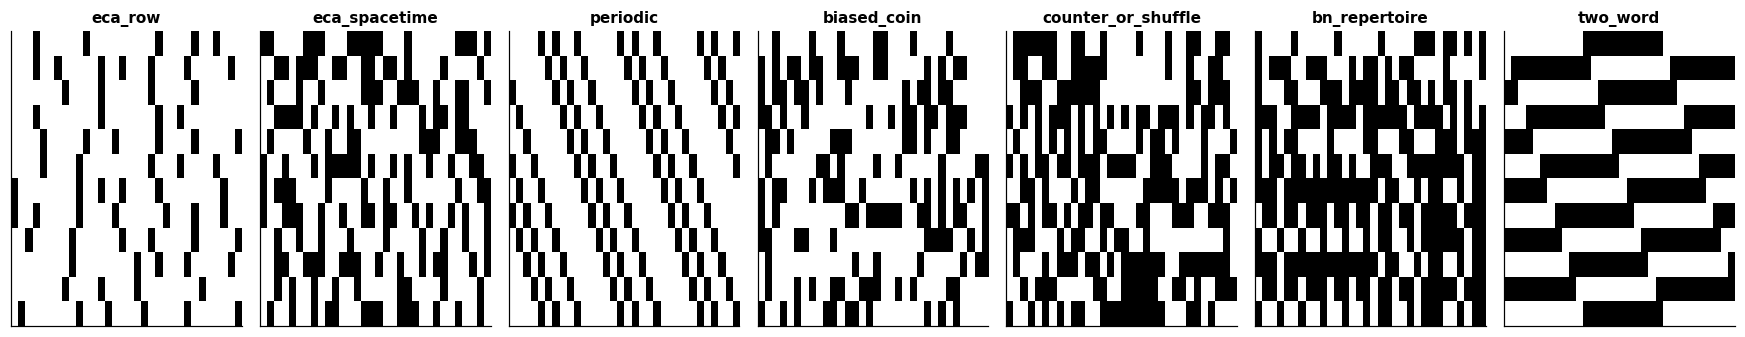

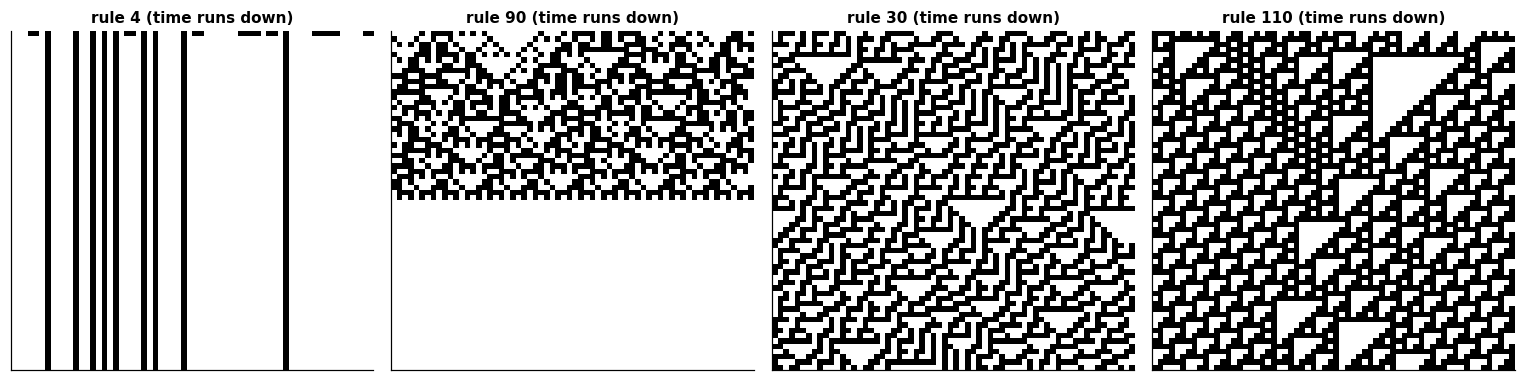

live re-computation of a saved H5 record: identical


In [4]:
fig, ax = plt.subplots(1, 7, figsize=(16, 3.2))
for a, fid in zip(ax, P.FAMILIES):
    s = P.family(fid, 384, P.rng("H5", fid, 384, 0))
    show_bits(a, wrap(s, 32), fid)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1, 4, figsize=(14, 3.6))
for a, rule in zip(ax, (4, 90, 30, 110)):
    r = P.rng("H3", rule, 0)
    A = evolve_eca(rule, [r.randrange(2) for _ in range(64)], 64)
    show_bits(a, ["".join(map(str, row)) for row in A], f"rule {rule} (time runs down)")
plt.tight_layout(); plt.show()

# live check: the first saved H5 record at 384 bits is re-computed through the producer
rec = next(o for o in H5["raw"] if o["n"] == 384 and o["family"] == "eca_row" and o["j"] == 0)
again = P._h5_job(("eca_row", 384, 0, [4, 8, 12], rec.get("flip_at")))
assert json.loads(json.dumps(again, default=str)) == rec
print("live re-computation of a saved H5 record: identical")

## 2 · How BDM reads a string

BDM cuts the string into windows of a fixed **word length** *b*, looks each distinct window up
in a table of CTM values (the D(5) Turing-machine table, words of 1 to 12 bits), and adds
log2 of how many times each window occurs. pybdm takes a **step** between window starts;
the **overlap** is word length minus step.

The string `1111100000` below is read with words of 5 at steps 5, 2 and 1. At step 2 (overlap
3) the windows are `11111`, `11100`, `10000`, and **the tenth bit is never read**: a fourth
window would run past the end. pybdm drops it silently; our owner refuses unless told to
drop.

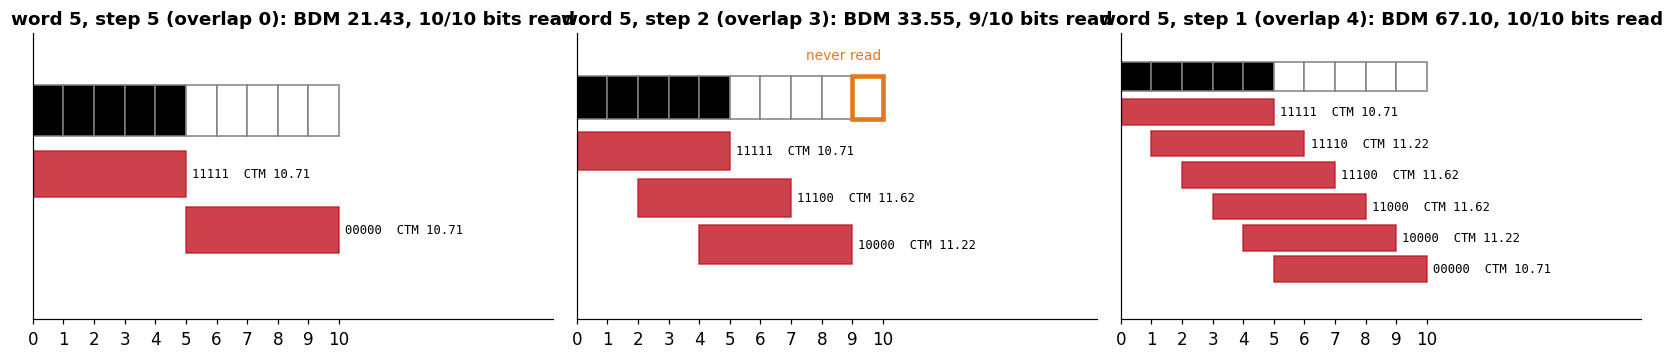

In [5]:
DM4 = R["DM"]["DM4"]
fig, ax = plt.subplots(1, 3, figsize=(15, 3.4))
x = "1111100000"
for a, st in zip(ax, ("5", "2", "1")):
    t = DM4[st]
    for j, ch in enumerate(x):
        a.add_patch(plt.Rectangle((j, 0), 1, 1, color="black" if ch == "1" else "white", ec="0.5"))
    for r in t["rows"]:
        y = -1.2 - 1.1 * r["step"]
        a.add_patch(plt.Rectangle((r["start"], y), r["length"], .9, color=HL, alpha=.8))
        a.text(r["start"] + r["length"] + .2, y + .45, f"{r['block']}  CTM {r['ctm']:.2f}",
               va="center", fontsize=8, family="monospace")
    if t["covered_bits"] < 10:
        a.add_patch(plt.Rectangle((t["covered_bits"], 0), 10 - t["covered_bits"], 1, fill=False, ec=BAD, lw=3))
        a.text(t["covered_bits"] - 1.5, 1.4, "never read", color=BAD, fontsize=9)
    a.set(xlim=(0, 17), ylim=(-1.4 - 1.1 * len(t["rows"]), 2), yticks=[],
          title=f"word 5, step {st} (overlap {5 - int(st)}): BDM {t['score']:.2f}, {t['covered_bits']}/10 bits read")
    a.set_xticks(range(11)); a.grid(False)
plt.tight_layout(); plt.show()
assert [DM4[s]["covered_bits"] for s in ("5", "2", "1")] == [10, 9, 10]
assert [r["block"] for r in DM4["2"]["rows"]] == ["11111", "11100", "10000"]

## 2b · The calculation by hand: exactly what pybdm does

This section opens pybdm 0.1.0, the library behind every BDM value in this repository, and
repeats its calculation the way one would on paper. It takes no shortcut through `bdm()`:
every number below is read from pybdm's own lookup table and added by hand, and the totals
are then compared with pybdm's answer. The source lines quoted come from the installed
package (`venv/lib/python3.13/site-packages/pybdm/`).

**Step 1 — load the table** (`utils.get_ctm_dataset("CTM-B2-D12")`). The table is a gzipped
pickle. It maps a *shape* (word length 1 to 12) to a dictionary {string: CTM value in bits}.
The value is CTM(s) = −log2 D(5)(s), where D(5)(s) is the share of halting 5-state Turing
machines that print s (Soler-Toscano et al., 2014). This is the one step that cannot be
redone by hand: it took billions of machine runs. We take the numbers as given. A string
missing from the table would get (largest value in the table + 1); for binary strings up to
12 bits this never happens, as the cell below checks.

**Step 2 — cut the string** (`utils.iter_slices`, `partitions.PartitionIgnore/Correlated`).
Without overlap, windows start at 0, b, 2b, … For a step s, they start at
`range(0, n − b + 1, s)`. Any piece shorter than b is **thrown away**
(`if part.shape == self.shape: yield part`).

**Step 3 — make the key** (`encoding.string_from_array`, then `encoding.normalize_key`). The
window is written as a string. Then the symbols are **renamed in order of first appearance**:
the first symbol becomes 0, the next new symbol becomes 1. So `11111` is looked up as
`00000`, and `11100` as `00011`. This is why the table stores only strings that start with 0
(16 of the 32 strings of length 5), and why a string and its complement always have the same
CTM.

**Step 4 — look up** (`bdm.lookup`): `cmx = self._ctm[shape][normalized_key]`. It yields the
pair (**original** string, CTM value). The original string is kept, not the normalised one.

**Step 5 — count** (`bdm.count`): `Counter(pairs)`. Identical windows are merged and counted.
Because the original string is the key, `11111` and `00000` are counted as **two different
blocks**, even though they share one table entry.

**Step 6 — add up** (`bdm.compute_bdm`):
`for (key, ctm), n in counter.items(): bdm += ctm + log2(n)`. Each distinct block pays its
CTM **once**, plus log2 of the number of times it occurred.

In [6]:
# Didactic re-derivation of pybdm's arithmetic, checked against pybdm itself. It defines no
# measure: the owner remains description_lengths.bdm_1d.
from pybdm import BDM
from pybdm.utils import get_ctm_dataset
from pybdm.encoding import normalize_key
from pybdm.partitions import PartitionCorrelated
TABLE, MISSING = get_ctm_dataset("CTM-B2-D12")
print("table shapes:", sorted(L for (L,) in TABLE))
print("entries per length:", {L: len(TABLE[(L,)]) for (L,) in sorted(TABLE)}, " = 2^(L-1): every normalised string")
assert all(len(TABLE[(L,)]) == 2 ** (L - 1) for L in range(1, 13))       # so the 'missing' rule never fires
print(f"value used for a missing length-5 string (max + 1): {MISSING[(5,)]:.6f}")

def by_hand(x, b, step):
    """Steps 2-6 written out; returns the ledger and the total."""
    n = len(x)
    starts = list(range(0, n, b)) if step == b else list(range(0, n - b + 1, step))
    windows = [(s, x[s:s + b]) for s in starts if len(x[s:s + b]) == b]          # step 2
    looked = [(s, w, normalize_key(w), TABLE[(b,)][normalize_key(w)]) for s, w in windows]   # steps 3-4
    counts = collections.Counter((w, c) for _, w, _, c in looked)               # step 5
    terms = [(w, c, k, math.log2(k)) for (w, c), k in counts.items()]          # step 6
    return windows, looked, terms, sum(c + l for _, c, _, l in terms)

def show_ledger(x, b, step, kw):
    windows, looked, terms, total = by_hand(x, b, step)
    print(f"\n=== {x}  word {b}, step {step} (overlap {b - step}) ===")
    print("steps 2-4: window, normalised key, value read from the table")
    for s, w, k, c in looked:
        print(f"   bits {s + 1:>2}-{s + b:<2}  {'.' * s}{w}{'.' * (len(x) - s - b)}   key {w} -> {k}   CTM = {c:.6f}")
    read = {i for s, _ in windows for i in range(s, s + b)}
    unread = [i + 1 for i in range(len(x)) if i not in read]
    if unread:
        print(f"   bits never read: {unread}")
    print("steps 5-6: distinct blocks, count n, CTM + log2(n)")
    for w, c, k, l in terms:
        print(f"   {w}   n = {k}   {c:.6f} + log2({k}) = {c:.6f} + {l:.6f} = {c + l:.6f}")
    print("   BDM = " + " + ".join(f"{c + l:.6f}" for _, c, _, l in terms) + f" = {total:.6f}")
    owner = bdm_1d(x, **kw)
    lib = (BDM(ndim=1, shape=(b,)) if step == b else
           BDM(ndim=1, shape=(b,), partition=PartitionCorrelated, shift=step)).bdm(np.array([int(ch) for ch in x]))
    print(f"   pybdm BDM.bdm() = {lib:.6f};  owner bdm_1d = {owner:.6f}")
    assert abs(total - lib) < 1e-12 and abs(total - owner) < 1e-12
    return looked, terms, total

X = "1111100000"
L5 = show_ledger(X, 5, 5, dict(block=5))
L2 = show_ledger(X, 5, 2, dict(block=5, shift=2, remainder="drop"))
L1 = show_ledger(X, 5, 1, dict(block=5, shift=1))

table shapes: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
entries per length: {1: 1, 2: 2, 3: 4, 4: 8, 5: 16, 6: 32, 7: 64, 8: 128, 9: 256, 10: 512, 11: 1024, 12: 2048}  = 2^(L-1): every normalised string
value used for a missing length-5 string (max + 1): 12.834019

=== 1111100000  word 5, step 5 (overlap 0) ===
steps 2-4: window, normalised key, value read from the table
   bits  1-5   11111.....   key 11111 -> 00000   CTM = 10.712579
   bits  6-10  .....00000   key 00000 -> 00000   CTM = 10.712579
steps 5-6: distinct blocks, count n, CTM + log2(n)
   11111   n = 1   10.712579 + log2(1) = 10.712579 + 0.000000 = 10.712579
   00000   n = 1   10.712579 + log2(1) = 10.712579 + 0.000000 = 10.712579
   BDM = 10.712579 + 10.712579 = 21.425158
   pybdm BDM.bdm() = 21.425158;  owner bdm_1d = 21.425158

=== 1111100000  word 5, step 2 (overlap 3) ===
steps 2-4: window, normalised key, value read from the table
   bits  1-5   11111.....   key 11111 -> 00000   CTM = 10.712579
   bits  3-7   ..11100..

**Two more strings, one for each subtlety of step 5.** In `1111111111` the block `11111`
occurs twice, so it pays its CTM once plus log2 2 = 1 bit. In `0000011111` the blocks
`00000` and `11111` share one table entry, `00000`, but they are different strings, so
each pays the full CTM.

In [7]:
R2 = show_ledger("1111111111", 5, 5, dict(block=5))
R3 = show_ledger("0000011111", 5, 5, dict(block=5))
assert abs(R2[2] - (TABLE[(5,)]["00000"] + 1)) < 1e-12
assert abs(R3[2] - 2 * TABLE[(5,)]["00000"]) < 1e-12


=== 1111111111  word 5, step 5 (overlap 0) ===
steps 2-4: window, normalised key, value read from the table
   bits  1-5   11111.....   key 11111 -> 00000   CTM = 10.712579
   bits  6-10  .....11111   key 11111 -> 00000   CTM = 10.712579
steps 5-6: distinct blocks, count n, CTM + log2(n)
   11111   n = 2   10.712579 + log2(2) = 10.712579 + 1.000000 = 11.712579
   BDM = 11.712579 = 11.712579
   pybdm BDM.bdm() = 11.712579;  owner bdm_1d = 11.712579

=== 0000011111  word 5, step 5 (overlap 0) ===
steps 2-4: window, normalised key, value read from the table
   bits  1-5   00000.....   key 00000 -> 00000   CTM = 10.712579
   bits  6-10  .....11111   key 11111 -> 00000   CTM = 10.712579
steps 5-6: distinct blocks, count n, CTM + log2(n)
   00000   n = 1   10.712579 + log2(1) = 10.712579 + 0.000000 = 10.712579
   11111   n = 1   10.712579 + log2(1) = 10.712579 + 0.000000 = 10.712579
   BDM = 10.712579 + 10.712579 = 21.425158
   pybdm BDM.bdm() = 21.425158;  owner bdm_1d = 21.425158


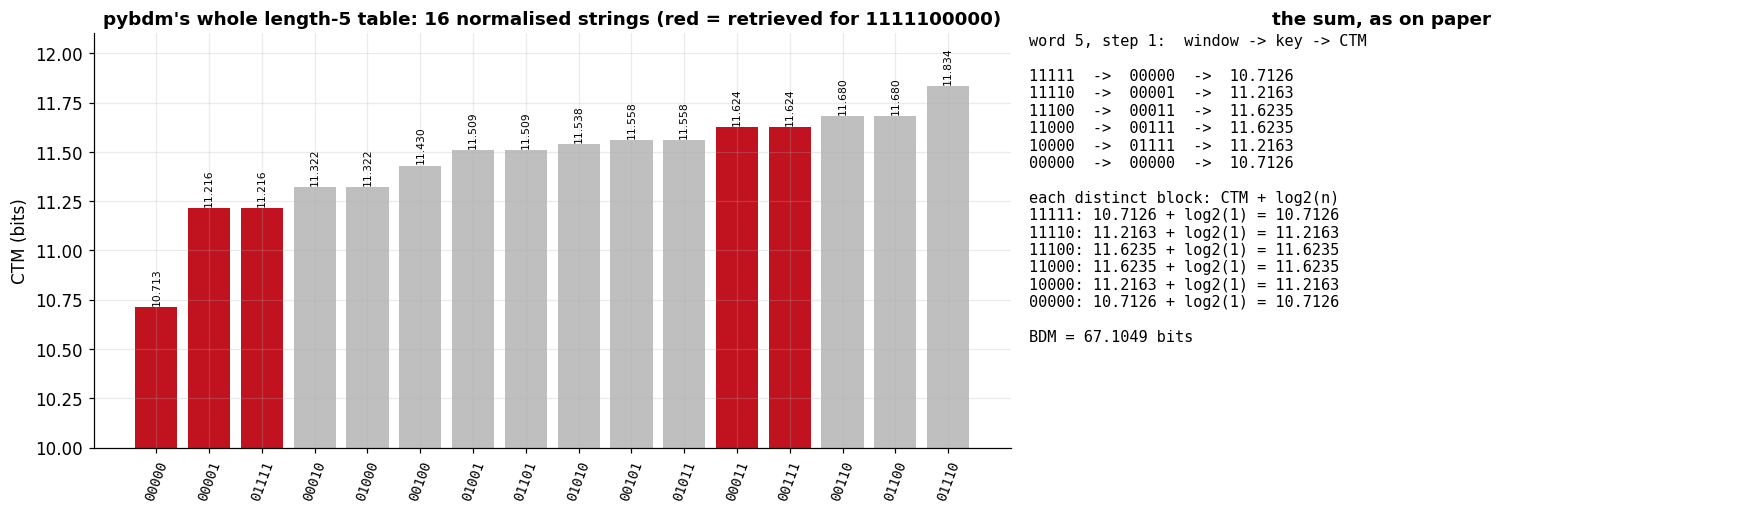

retrieved from the length-5 table: ['00000', '00001', '00011', '00111', '01111']


In [8]:
# The table itself: all 16 entries for length 5, with the ones the walks above retrieved.
t5 = sorted(TABLE[(5,)].items(), key=lambda kv: kv[1])
used = {key for _, _, key, _ in L5[0] + L2[0] + L1[0]}
fig, ax = plt.subplots(1, 2, figsize=(16, 4.8), gridspec_kw={"width_ratios": [1.3, 1]})
cols = [HL if k in used else "0.75" for k, _ in t5]
ax[0].bar(range(16), [v for _, v in t5], color=cols)
ax[0].set_xticks(range(16)); ax[0].set_xticklabels([k for k, _ in t5], rotation=70, family="monospace", fontsize=9)
ax[0].set_ylim(10, 12.1); ax[0].set_ylabel("CTM (bits)")
ax[0].set_title("pybdm's whole length-5 table: 16 normalised strings (red = retrieved for 1111100000)")
for i, (k, v) in enumerate(t5):
    ax[0].text(i, v + .02, f"{v:.3f}", ha="center", fontsize=7, rotation=90)
# the worked sheet for step 1 (overlap 4), drawn
looked, terms, total = L1
ax[1].axis("off")
lines = ["word 5, step 1:  window -> key -> CTM", ""]
lines += [f"{w}  ->  {k}  ->  {c:.4f}" for _, w, k, c in looked]
lines += ["", "each distinct block: CTM + log2(n)"]
lines += [f"{w}: {c:.4f} + log2({k}) = {c + l:.4f}" for w, c, k, l in terms]
lines += ["", f"BDM = {total:.4f} bits"]
ax[1].text(0, 1, "\n".join(lines), va="top", family="monospace", fontsize=10)
ax[1].set_title("the sum, as on paper")
plt.tight_layout(); plt.show()
print(f"retrieved from the length-5 table: {sorted(used)}")

**The same calculation in two dimensions** (used for the cellular automata of §6 and §8). The
table is `CTM-B2-D4x4`: square shapes 1×1 to 4×4, 32,768 normalised entries for 4×4. A block
becomes its key by reading its 16 cells **row by row** (`arr.flat`), then normalising as
above. Below, an 8 × 8 corner of the rule-30 diagram splits into four 4 × 4 blocks.

2-D shapes: [(1, 1), (2, 2), (3, 3), (4, 4)]  entries: {(1, 1): 1, (2, 2): 8, (3, 3): 256, (4, 4): 32768}


block rows 0-3, cols 0-3: read row by row 0111010011100000 -> key 0111010011100000 -> CTM 28.540910
block rows 0-3, cols 4-7: read row by row 0101010111011001 -> key 0101010111011001 -> CTM 30.861709
block rows 4-7, cols 0-3: read row by row 1001011111000011 -> key 0110100000111100 -> CTM 31.906758
block rows 4-7, cols 4-7: read row by row 1111000010001100 -> key 0000111101110011 -> CTM 26.830645


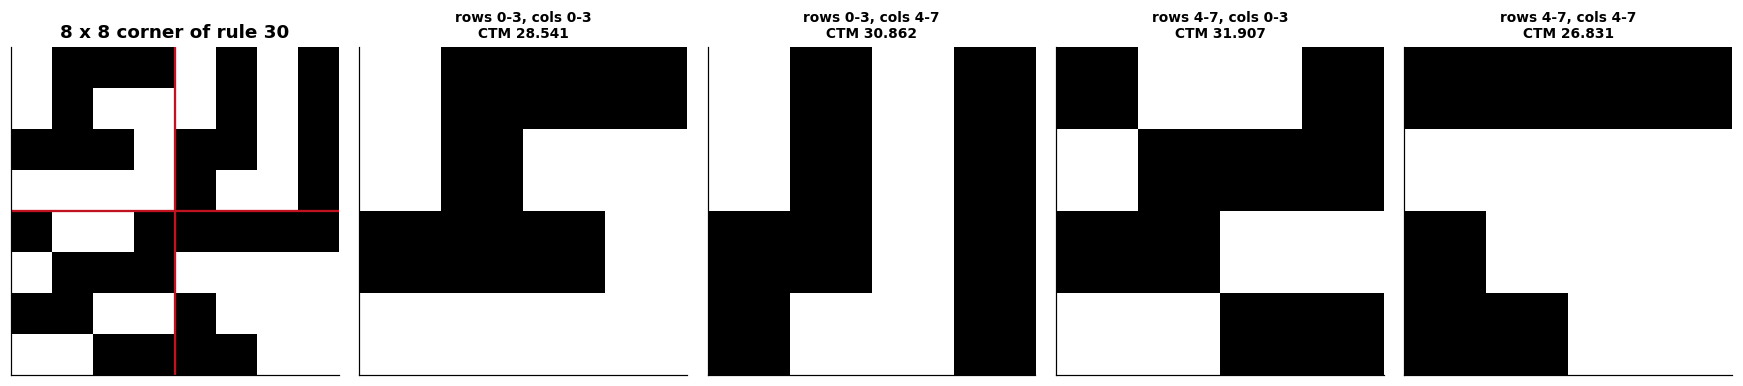

BDM = (28.540910 + log2 1) + (30.861709 + log2 1) + (31.906758 + log2 1) + (26.830645 + log2 1) = 118.140023
pybdm BDM(ndim=2).bdm() = 118.140023;  owner bdm_2d = 118.140023


In [9]:
T2D, _ = get_ctm_dataset("CTM-B2-D4x4")
print("2-D shapes:", sorted(T2D), " entries:", {k: len(v) for k, v in sorted(T2D.items())})
r = P.rng("H3", 30, 0)
A30 = np.array(evolve_eca(30, [r.randrange(2) for _ in range(64)], 64))[:8, :8]
fig, ax = plt.subplots(1, 5, figsize=(16, 3.4))
ax[0].imshow(1 - A30, cmap="gray", interpolation="nearest"); ax[0].set_title("8 x 8 corner of rule 30")
ax[0].axhline(3.5, color=HL); ax[0].axvline(3.5, color=HL); ax[0].set_xticks([]); ax[0].set_yticks([])
blocks2d, total2d = [], 0.0
for i, (r0, c0) in enumerate([(0, 0), (0, 4), (4, 0), (4, 4)]):
    B = A30[r0:r0 + 4, c0:c0 + 4]
    key = "".join(map(str, B.flat)); kn = normalize_key(key); c = T2D[(4, 4)][kn]
    blocks2d.append((key, c))
    ax[i + 1].imshow(1 - B, cmap="gray", interpolation="nearest"); ax[i + 1].set_xticks([]); ax[i + 1].set_yticks([])
    ax[i + 1].set_title(f"rows {r0}-{r0 + 3}, cols {c0}-{c0 + 3}\nCTM {c:.3f}", fontsize=9)
    print(f"block rows {r0}-{r0 + 3}, cols {c0}-{c0 + 3}: read row by row {key} -> key {kn} -> CTM {c:.6f}")
plt.tight_layout(); plt.show()
cnt = collections.Counter(blocks2d)
total2d = sum(c + math.log2(k) for (_, c), k in cnt.items())
print("BDM = " + " + ".join(f"({c:.6f} + log2 {k})" for (_, c), k in cnt.items()) + f" = {total2d:.6f}")
lib2d = BDM(ndim=2).bdm(A30)
print(f"pybdm BDM(ndim=2).bdm() = {lib2d:.6f};  owner bdm_2d = {bdm_2d(A30):.6f}")
assert abs(total2d - lib2d) < 1e-12 and abs(total2d - bdm_2d(A30)) < 1e-12

**Reading.** BDM is six steps: a table loaded once, a cut, a renaming of symbols, a lookup,
a count, and a sum. The hand calculation reproduces pybdm and our owner to 1e-12 in every
case above, in one and in two dimensions. Three facts that matter for the rest of the notebook
are visible here, with no theory at all:

* only the 2^(b−1) table entries of the chosen length are ever read, and a string and its
  complement always receive the same value (step 3);
* a piece shorter than the word is discarded, which is why bit 10 is never read at step 2;
* repeats cost log2 n while new blocks cost their full CTM, and nothing in the sum records
  *where* each block was. This is the omission §3 measures.

## 3 · What BDM keeps, and what it leaves out

Think of sending a string, cut into *m* blocks, to someone who must rebuild it exactly. The
message needs three things:

| part | says | in BDM? |
|---|---|---|
| **dictionary** | which distinct words occur | yes, priced by CTM |
| **counts** | how often each occurs | yes, log2 of each count |
| **arrangement** | in which order the blocks come | **no** |

The arrangement of a given set of counts is one of m!/(n1! n2! …) possibilities, and costs
log2 of that number. For long strings this is almost exactly *m* times the Shannon entropy
of the block histogram. So **BDM keeps what block entropy throws away (what each word is),
and throws away what block entropy keeps (how the words are arranged).**

`block_code_parts` (owner) returns all three parts, plus the length of an *actual* prefix
code that sends all three: each word in ⌈CTM⌉ bits, counts in Elias-γ, then the rank of
the arrangement. The owner's tests encode and decode it bit for bit.

**The four example strings, before any measure.** Each has 384 bits, drawn below as 48 rows of
8 bits: one row is one block of 8, the word BDM reads. Next to each picture are its first
blocks, how many *different* blocks it has, and the most frequent ones.

* **periodic (period 6):** `011010` repeated 64 times. A period of 6 does not fit a block of 8,
  so the blocks cycle through 3 phases: lcm(6, 8) = 24 bits.
* **counter, 8-bit words:** the numbers 0, 1, 2, …, 47 written in binary, 8 bits each. All 48
  blocks differ, yet one short rule ("add one") makes them all.
* **biased coin (q = 0.1):** each bit is 1 with probability 0.1, independently: mostly
  zeros, with scattered ones.
* **fair coin:** each bit is 0 or 1 with probability ½, independently: no structure at all.

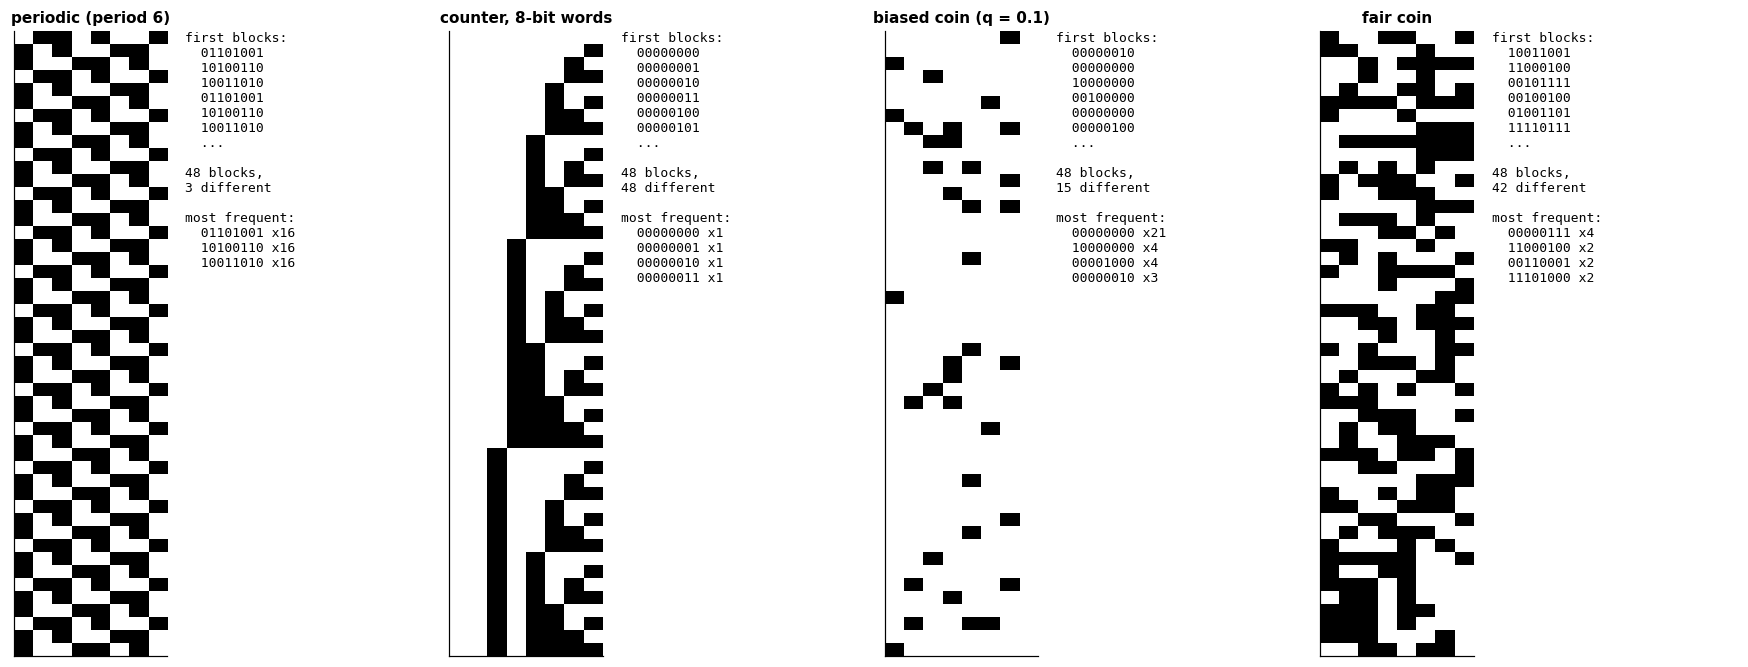

In [10]:
rng0 = random.Random(5)
examples = {
    "periodic (period 6)": ("011010" * 64),
    "counter, 8-bit words": "".join(format(i, "08b") for i in range(48)),
    "biased coin (q = 0.1)": "".join("1" if rng0.random() < .1 else "0" for _ in range(384)),
    "fair coin": "".join(rng0.choice("01") for _ in range(384)),
}
fig, ax = plt.subplots(1, 8, figsize=(16, 6.2), gridspec_kw={"width_ratios": [1, 1.6] * 4})
for i, (name, s) in enumerate(examples.items()):
    blocks = wrap(s, 8)
    show_bits(ax[2 * i], blocks, name)
    cnt = collections.Counter(blocks)
    txt = ["first blocks:"] + [f"  {b}" for b in blocks[:6]] + ["  ...", "",
           f"{len(blocks)} blocks,", f"{len(cnt)} different", "", "most frequent:"]
    txt += [f"  {b} x{n}" for b, n in cnt.most_common(4)]
    ax[2 * i + 1].axis("off")
    ax[2 * i + 1].text(0, 1, "\n".join(txt), va="top", family="monospace", fontsize=8.5)
plt.tight_layout(); plt.show()
assert [len(set(wrap(s, 8))) for s in list(examples.values())[:2]] == [3, 48]

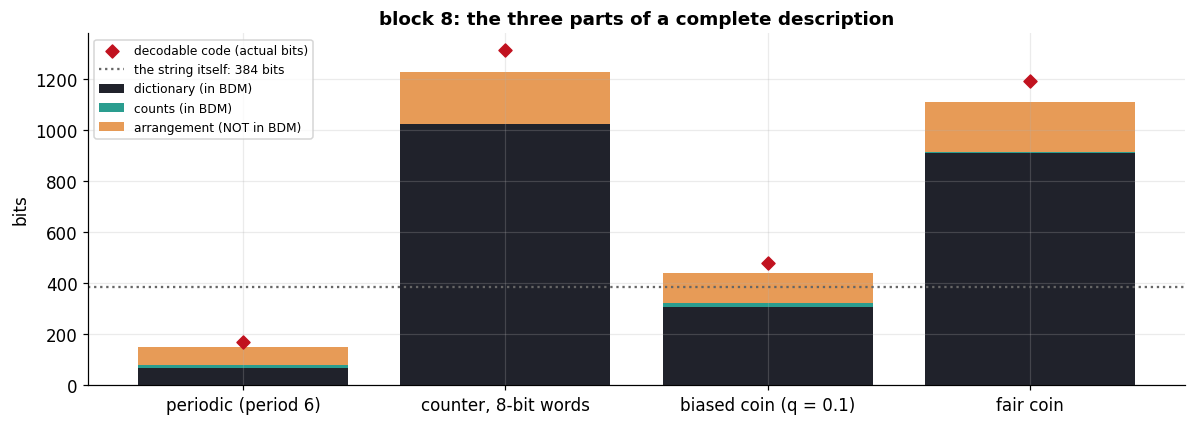

periodic (period 6)      BDM     78.2 = dictionary    66.2 + counts  12.0;  arrangement    70.2;  decodable 170
counter, 8-bit words     BDM   1023.8 = dictionary  1023.8 + counts   0.0;  arrangement   202.9;  decodable 1312
biased coin (q = 0.1)    BDM    321.2 = dictionary   307.1 + counts  14.1;  arrangement   119.6;  decodable 479
fair coin                BDM    913.2 = dictionary   908.2 + counts   5.0;  arrangement   195.4;  decodable 1190

T1: 0 failures in 42,000 block permutations (7 families x 2 lengths x 3 blocks x 1,000)
T2: 0 violations of BDM <= C_b + 2^b log2 m in 75 fair-coin strings


In [11]:
parts = {k: block_code_parts(s, block=8) for k, s in examples.items()}
fig, ax = plt.subplots(figsize=(11, 4))
names = list(parts)
d = np.array([parts[k]["dictionary_bits"] for k in names]); c = np.array([parts[k]["count_bits"] for k in names])
a = np.array([parts[k]["arrangement_bits"] for k in names])
ax.bar(names, d, color=INK, label="dictionary (in BDM)")
ax.bar(names, c, bottom=d, color=OK, label="counts (in BDM)")
ax.bar(names, a, bottom=d + c, color=BAD, alpha=.75, label="arrangement (NOT in BDM)")
ax.scatter(names, [parts[k]["decodable_bits"] for k in names], marker="D", color=HL, zorder=5, label="decodable code (actual bits)")
ax.axhline(384, color="0.4", ls=":", label="the string itself: 384 bits")
ax.set(ylabel="bits", title="block 8: the three parts of a complete description"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
for k in names:
    p = parts[k]
    print(f"{k:<24} BDM {p['bdm']:8.1f} = dictionary {p['dictionary_bits']:7.1f} + counts {p['count_bits']:5.1f};"
          f"  arrangement {p['arrangement_bits']:7.1f};  decodable {p['decodable_bits']}")
    assert abs(p["bdm"] - bdm_1d(examples[k], block=8)) < 1e-9
print(f"\nT1: {T1['failures']} failures in {T1['checked']:,} block permutations (7 families x 2 lengths x 3 blocks x 1,000)")
print(f"T2: {T2['violations']} violations of BDM <= C_b + 2^b log2 m in {T2['checked']} fair-coin strings")

**Reading the printed lines above, term by term.** Take the first line, the periodic string:
`BDM 78.2 = dictionary 66.2 + counts 12.0; arrangement 70.2; decodable 170`. The periodic
string, cut into blocks of 8, contains only **3 different words**, each **16 times**
(48 blocks). The cell below takes that line apart.

* **Dictionary (66.2):** the three CTM values **retrieved from the lookup table**, one per
  *different* word, added up. Each word is paid for once, however often it occurs.
* **Counts (12.0):** for each different word, log2 of the number of times it occurs. Here
  log2 16 = 4 bits per word, × 3 words = 12. This is BDM's charge for repetition.
* **BDM (78.2)** is exactly dictionary + counts: 66.2 + 12.0. Nothing else enters.
* **Arrangement (70.2):** the bits needed to say **in which order** the 48 blocks come. With
  16 copies of each of 3 words there are 48! / (16! · 16! · 16!) possible orders, about
  1.36 × 10^21, and log2 of that is 70.2. **BDM leaves this out.** That is why shuffling the
  blocks never changes BDM.
* **Decodable (170):** the length in whole bits of a real message from which the string can be
  rebuilt exactly: how many words there are, each word with its count, then which order.
  It is larger than dictionary + counts + arrangement (148.4) because a real code must use
  whole bits and must mark where each number ends.

the string cut into blocks of 8: 48 blocks, 3 different words

word       times  CTM from table  log2(times) | ceil(CTM) gamma(times)
01101001      16          22.111        4.000 |        23            9
10100110      16          22.026        4.000 |        23            9
10011010      16          22.026        4.000 |        23            9

dictionary  = 22.111 + 22.026 + 22.026 = 66.2
counts      = log2 16 + log2 16 + log2 16 = 12.0
BDM         = dictionary + counts = 66.2 + 12.0 = 78.2   (pybdm: 78.2)
arrangement = log2( 48! / (16! 16! 16!) ) = log2(1,355,345,464,406,015,082,330) = 70.2   <- not in BDM
decodable   = gamma(3 words) + sum(ceil(CTM) + gamma(times)) + order rank = 3 + 96 + 71 = 170   (owner: 170)


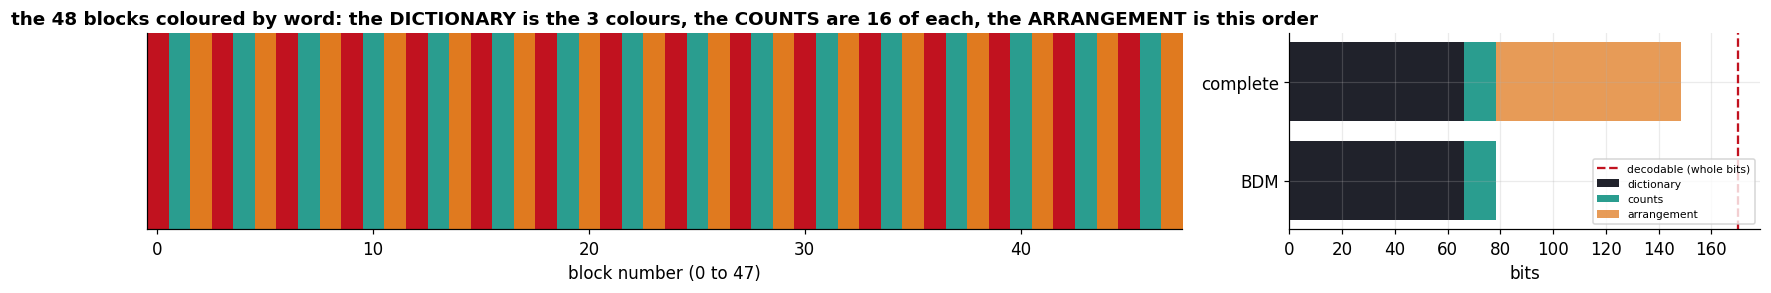

In [12]:
s = examples["periodic (period 6)"]
p = parts["periodic (period 6)"]
blocks = wrap(s, 8)
g = lambda x: 2 * (x.bit_length() - 1) + 1          # Elias-gamma length, as in the owner
print(f"the string cut into blocks of 8: {len(blocks)} blocks, {len(p['counts'])} different words\n")
print(f"{'word':<10} {'times':>5} {'CTM from table':>15} {'log2(times)':>12} | {'ceil(CTM)':>9} {'gamma(times)':>12}")
for w, n in p["counts"].items():
    print(f"{w:<10} {n:>5} {ctm_1d(w):>15.3f} {math.log2(n):>12.3f} | {math.ceil(ctm_1d(w)):>9} {g(n):>12}")
dic = sum(ctm_1d(w) for w in p["counts"]); cnt = sum(math.log2(n) for n in p["counts"].values())
M = math.factorial(len(blocks))
for n in p["counts"].values():
    M //= math.factorial(n)
print(f"\ndictionary  = {' + '.join(f'{ctm_1d(w):.3f}' for w in p['counts'])} = {dic:.1f}")
print(f"counts      = {' + '.join(f'log2 {n}' for n in p['counts'].values())} = {cnt:.1f}")
print(f"BDM         = dictionary + counts = {dic:.1f} + {cnt:.1f} = {dic + cnt:.1f}   (pybdm: {bdm_1d(s, block=8):.1f})")
print(f"arrangement = log2( 48! / (16! 16! 16!) ) = log2({M:,}) = {math.log2(M):.1f}   <- not in BDM")
head = g(len(p["counts"])); per_word = sum(math.ceil(ctm_1d(w)) + g(n) for w, n in p["counts"].items()); rank = (M - 1).bit_length()
print(f"decodable   = gamma(3 words) + sum(ceil(CTM) + gamma(times)) + order rank"
      f" = {head} + {per_word} + {rank} = {head + per_word + rank}   (owner: {p['decodable_bits']})")
assert abs(dic + cnt - p["bdm"]) < 1e-9 and abs(math.log2(M) - p["arrangement_bits"]) < 1e-9
assert head + per_word + rank == p["decodable_bits"] == 170

# the three parts, drawn on the object itself
ids = {w: i for i, w in enumerate(p["counts"])}
fig, ax = plt.subplots(1, 2, figsize=(15, 2.8), gridspec_kw={"width_ratios": [2.2, 1]})
ax[0].imshow([[ids[b] for b in blocks]], cmap=matplotlib.colors.ListedColormap([HL, OK, BAD]), aspect="auto")
ax[0].set(yticks=[], xlabel="block number (0 to 47)",
          title="the 48 blocks coloured by word: the DICTIONARY is the 3 colours, the COUNTS are 16 of each, "
                "the ARRANGEMENT is this order")
ax[0].grid(False)
ax[1].barh(["BDM", "complete"], [dic, dic], color=INK, label="dictionary")
ax[1].barh(["BDM", "complete"], [cnt, cnt], left=[dic, dic], color=OK, label="counts")
ax[1].barh(["complete"], [math.log2(M)], left=[dic + cnt], color=BAD, alpha=.75, label="arrangement")
ax[1].axvline(170, color=HL, ls="--", label="decodable (whole bits)")
ax[1].set(xlabel="bits"); ax[1].legend(fontsize=7, loc="lower right")
plt.tight_layout(); plt.show()

**Why the arrangement is so large for such a simple string.** The order here is utterly
regular: red, green, orange, repeated. The arrangement term charges for *any* order of 16 + 16
+ 16 blocks, so it costs 70.2 bits even though "repeat the cycle" would cost a few. That is
the point of §4: a complete code is **honest** (it can rebuild the string) but not
**clever** (it cannot exploit a simple order). Exploiting order needs a model of the order,
which is what a generator, or the abstraction of §3b, supplies.

### Anatomy of T1 and T2: where "0 failures in 42,000" and "0 violations in 75" come from

**T1, the claim.** Aligned BDM depends only on *which* blocks occur and *how often*, never on
their order. **What would have made it false:** a single reordering of whole blocks that
changed BDM by more than 1e-9 (float rounding).

**How 42,000 is made.** The protocol takes one string from each of the 7 families, at 2 lengths
(96 and 384 bits), cuts it with 3 block lengths (4, 8, 12), and shuffles its blocks 1,000
times: 7 × 2 × 3 × 1,000 = 42,000 comparisons. Below is one of the 42 (family, length, block)
cases, the periodic string at 96 bits and block 8, run live in full, with 3 of its 1,000
shuffles drawn.

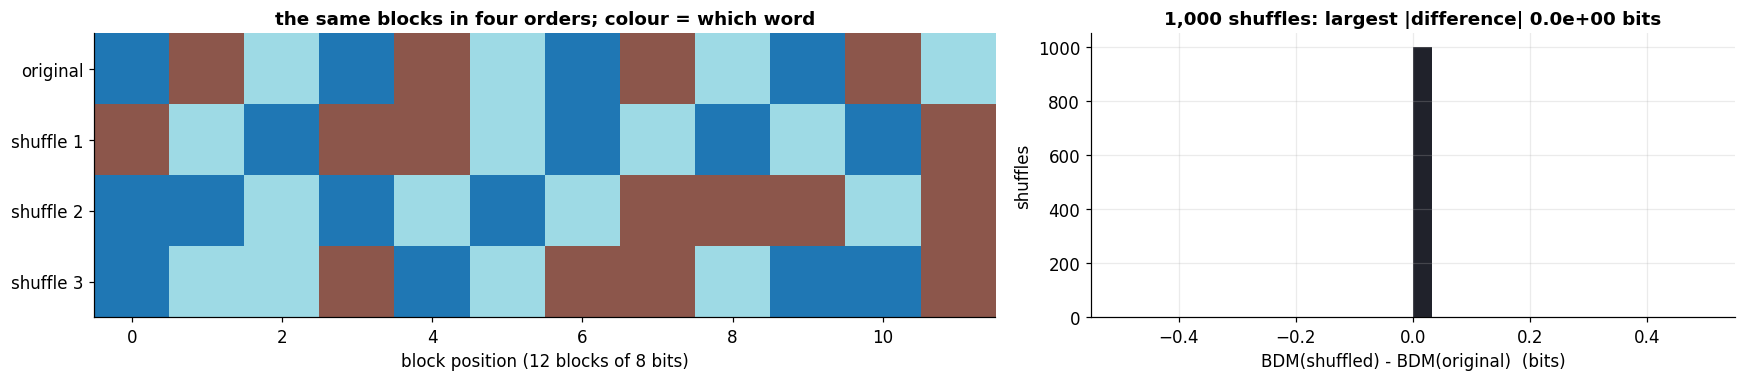

string: 111101111101111101111101111101111101111101111101111101111101111101111101111101111101111101111101
blocks: 12, different words 3: 11110111 x4, 11011111 x4, 01111101 x4
BDM = sum over words of CTM + log2(times) = (19.914 + log2 4) + (20.431 + log2 4) + (21.280 + log2 4) = 67.624
a shuffle changes the positions, not the words or their counts, so every term above is unchanged

this case: 0 failures in 1000 shuffles
all cases: 7 families x 2 lengths x 3 blocks x 1,000 = 42,000; saved run: 0 failures in 42,000


In [13]:
t1_s = P.family("periodic", 96, P.rng("T1", "periodic", 96))
t1_blocks = wrap(t1_s, 8)
t1_base = bdm_1d(t1_s, block=8)
t1_r = P.rng("T1perm", "periodic", 96, 8)
t1_perm_blocks, t1_diffs = [], []
for t in range(1000):                       # exactly the producer's loop for this case
    t1_r.shuffle(t1_blocks)
    if t < 3:
        t1_perm_blocks.append(t1_blocks[:])
    t1_diffs.append(bdm_1d("".join(t1_blocks), block=8) - t1_base)
t1_ids = {w: i for i, w in enumerate(dict.fromkeys(wrap(t1_s, 8)))}
fig, ax = plt.subplots(1, 2, figsize=(16, 3.6), gridspec_kw={"width_ratios": [1.4, 1]})
rows_ = [wrap(t1_s, 8)] + t1_perm_blocks
ax[0].imshow([[t1_ids[w] for w in r] for r in rows_], cmap="tab20", aspect="auto")
ax[0].set(yticks=range(4), yticklabels=["original", "shuffle 1", "shuffle 2", "shuffle 3"],
          xlabel="block position (12 blocks of 8 bits)", title="the same blocks in four orders; colour = which word")
ax[0].grid(False)
ax[1].hist(t1_diffs, bins=30, color=INK)
ax[1].set(xlabel="BDM(shuffled) - BDM(original)  (bits)", ylabel="shuffles",
          title=f"1,000 shuffles: largest |difference| {max(map(abs, t1_diffs)):.1e} bits")
plt.tight_layout(); plt.show()
t1_cnt = collections.Counter(wrap(t1_s, 8))
print(f"string: {t1_s}")
print(f"blocks: {len(wrap(t1_s, 8))}, different words {len(t1_cnt)}: " + ", ".join(f"{w} x{n}" for w, n in t1_cnt.items()))
print(f"BDM = sum over words of CTM + log2(times) = " +
      " + ".join(f"({ctm_1d(w):.3f} + log2 {n})" for w, n in t1_cnt.items()) + f" = {t1_base:.3f}")
print("a shuffle changes the positions, not the words or their counts, so every term above is unchanged")
t1_fail = sum(abs(d) >= 1e-9 for d in t1_diffs)
print(f"\nthis case: {t1_fail} failures in {len(t1_diffs)} shuffles")
print(f"all cases: 7 families x 2 lengths x 3 blocks x 1,000 = {7 * 2 * 3 * 1000:,}; saved run: "
      f"{T1['failures']} failures in {T1['checked']:,}")
assert t1_fail == 0 and T1["checked"] == 7 * 2 * 3 * 1000

**T2, the claim.** With a fixed block length *b*, BDM can never exceed
C_b + 2^b · log2 m, where *m* is the number of blocks and C_b is the sum of the table's CTM
values over **all** 2^b words of length *b*. **Why it must hold:** at most 2^b different words
can occur, each pays its CTM once (so the dictionary is at most C_b), and each occurs at most *m*
times (so each count term is at most log2 m). **What would have made it false:** any string
scoring above the bound, which would mean a defect in the code. **How 75 is made:** 3 block
lengths × 5 values of m × 5 seeds, all fair coins.

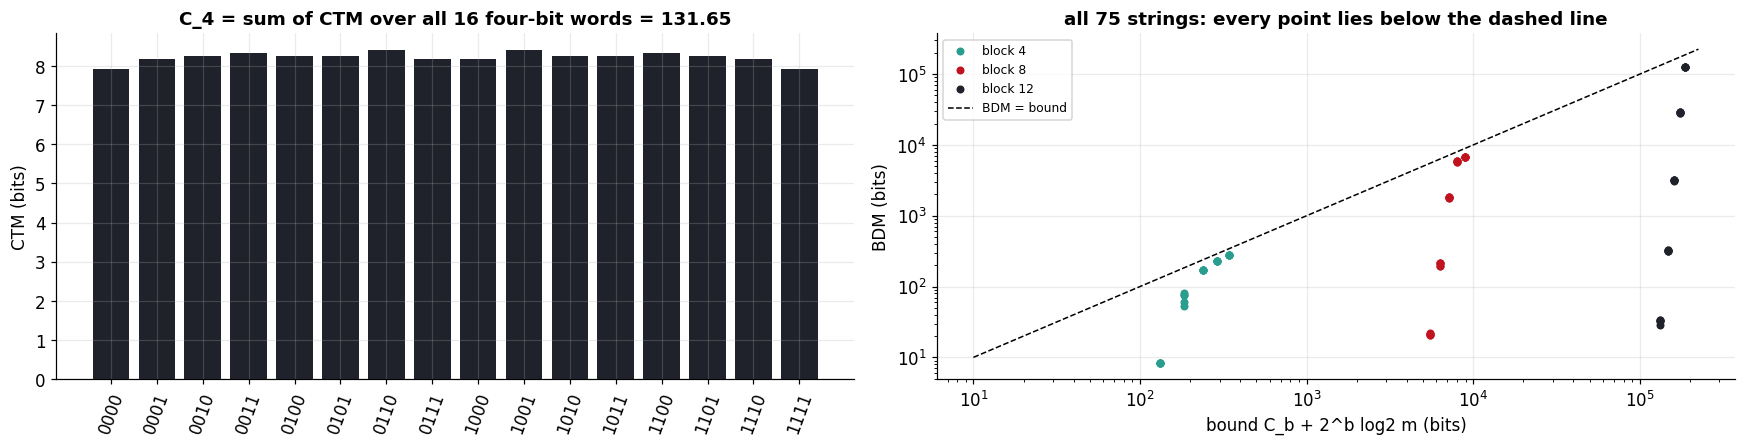

one case, block 4, m = 100 blocks (400 bits), seed 0: bound = 131.65 + 16 x log2(100) = 131.65 + 106.30 = 237.95; BDM = 171.39
all cases: 3 blocks x 5 m x 5 seeds = 75; violations 0
closest approach to the bound: BDM / bound = 0.814


In [14]:
t2_C4 = {format(i, "04b"): ctm_1d(format(i, "04b")) for i in range(16)}
t2_row = next(r for r in T2["rows"] if r["block"] == 4 and r["m"] == 100 and r["seed"] == 0)
fig, ax = plt.subplots(1, 2, figsize=(16, 4.2))
ax[0].bar(list(t2_C4), list(t2_C4.values()), color=INK)
ax[0].set(ylabel="CTM (bits)", title=f"C_4 = sum of CTM over all 16 four-bit words = {sum(t2_C4.values()):.2f}")
ax[0].tick_params(axis="x", labelrotation=70)
for b, col in zip((4, 8, 12), (OK, HL, INK)):
    rr = [r for r in T2["rows"] if r["block"] == b]
    ax[1].scatter([r["bound"] for r in rr], [r["bdm"] for r in rr], color=col, s=18, label=f"block {b}")
lim = [10, max(r["bound"] for r in T2["rows"]) * 1.2]
ax[1].plot(lim, lim, "k--", lw=1, label="BDM = bound")
ax[1].set(xscale="log", yscale="log", xlabel="bound C_b + 2^b log2 m (bits)", ylabel="BDM (bits)",
          title="all 75 strings: every point lies below the dashed line"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
t2_bound = sum(t2_C4.values()) + 16 * math.log2(100)
print(f"one case, block 4, m = 100 blocks (400 bits), seed 0: bound = {sum(t2_C4.values()):.2f} + 16 x log2(100) "
      f"= {sum(t2_C4.values()):.2f} + {16 * math.log2(100):.2f} = {t2_bound:.2f}; BDM = {t2_row['bdm']:.2f}")
print(f"all cases: 3 blocks x 5 m x 5 seeds = {3 * 5 * 5}; violations {T2['violations']}")
print(f"closest approach to the bound: BDM / bound = {max(r['bdm'] / r['bound'] for r in T2['rows']):.3f}")
assert abs(t2_bound - t2_row["bound"]) < 1e-9 and T2["checked"] == 75

**H1: what happens on pure noise as the string grows.** Fair coin flips, block 12, four
lengths over three decades, 20 seeds each. A random string has no structure, so an honest
description needs about one bit per bit.

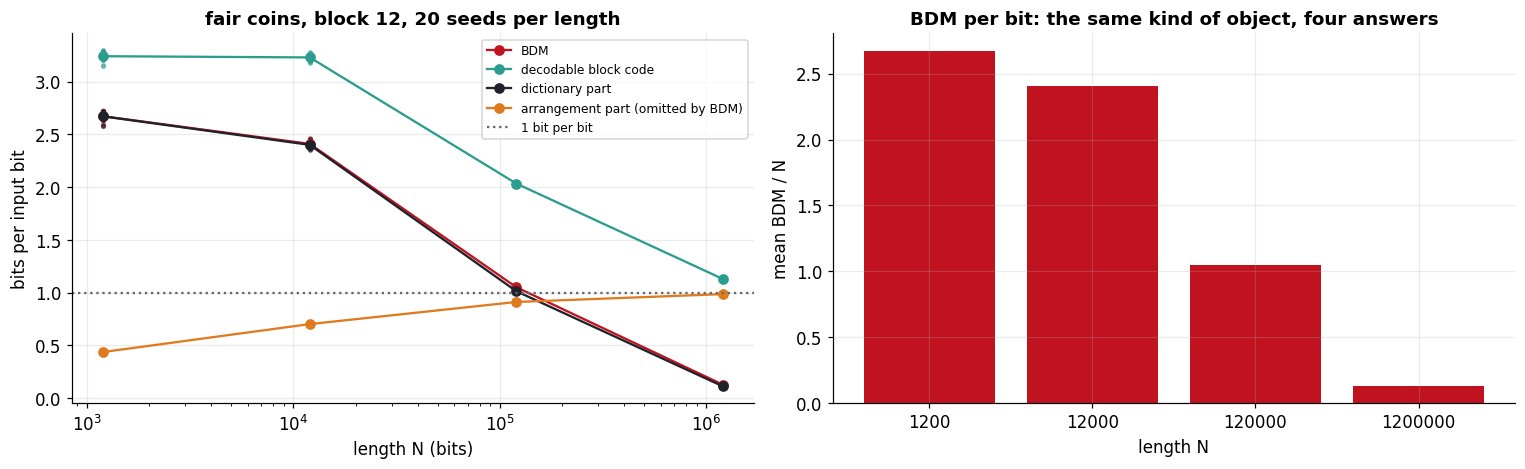

mean BDM/N       : {'1200': 2.672, '12000': 2.41, '120000': 1.051, '1200000': 0.127}
mean decodable/N : {'1200': 3.241, '12000': 3.23, '120000': 2.034, '1200000': 1.129}
criteria: {'a_ratio_gt_5': True, 'b_bdm_per_bit_lt_0.2': True, 'c_decodable_ge_0.95_and_in_1_1.2': True}


In [15]:
Ns = sorted({r["N"] for r in H1["rows"]})
fig, ax = plt.subplots(1, 2, figsize=(14, 4.4))
for key, col, lab in (("bdm", HL, "BDM"), ("decodable_bits", OK, "decodable block code"),
                      ("dictionary_bits", INK, "dictionary part"), ("arrangement_bits", BAD, "arrangement part (omitted by BDM)")):
    ys = [[r[key] / r["N"] for r in H1["rows"] if r["N"] == N] for N in Ns]
    ax[0].plot(Ns, [np.mean(y) for y in ys], "o-", color=col, label=lab)
    for N, y in zip(Ns, ys):
        ax[0].scatter([N] * len(y), y, s=6, color=col, alpha=.4)
ax[0].axhline(1, color="0.4", ls=":", label="1 bit per bit")
ax[0].set(xscale="log", xlabel="length N (bits)", ylabel="bits per input bit", title="fair coins, block 12, 20 seeds per length")
ax[0].legend(fontsize=8)
ax[1].bar([str(N) for N in Ns], [H1["mean_bdm_per_bit"][str(N)] for N in Ns], color=HL)
ax[1].set(title="BDM per bit: the same kind of object, four answers", xlabel="length N", ylabel="mean BDM / N")
plt.tight_layout(); plt.show()
mb, md_ = H1["mean_bdm_per_bit"], H1["mean_decodable_per_bit"]
print("mean BDM/N       :", {N: round(v, 3) for N, v in mb.items()})
print("mean decodable/N :", {N: round(v, 3) for N, v in md_.items()})
print("criteria:", H1["criteria"])
c12 = [ctm_1d(format(i, "012b")) for i in range(4096)]
assert (round(min(c12), 1), round(max(c12), 1)) == (25.6, 37.5)
assert round(mb["1200"], 2) == 2.67 and round(mb["1200000"], 3) == 0.127 and round(md_["1200000"], 2) == 1.13
live = P._h1_job((1200, 0, 12)); saved = next(r for r in H1["rows"] if r["N"] == 1200 and r["seed"] == 0)
assert all(abs(live[k] - saved[k]) < 1e-9 for k in saved), "H1 live re-computation differs"

### Anatomy of H1: where "2.67 bits per bit" and "0.127 bits per bit" come from

**The claim.** On strings with no structure, BDM per bit depends on how long the string is,
while a complete code stays near one bit per bit. **What would have made it false:** BDM/N
roughly constant across lengths, or the complete code compressing fair coins (below 0.95).

**One string at each end, taken apart.** Seed 0 at 1,200 bits (100 blocks of 12) and at
1,200,000 bits (100,000 blocks). Both are fair coins, re-generated exactly as the producer
does and checked against the saved values. Then the four terms, per bit.

N =     1,200: m =     100 blocks of 12, different words    99 (of 4,096 possible); most frequent word occurs 2 times
   dictionary  = sum of CTM over the 99 different words       =      3,225.6
   counts      = sum of log2(times) over those words           =          1.0
   BDM         = dictionary + counts                           =      3,226.6  -> BDM / N = 2.689
   arrangement = log2(m! / prod(times!))                        =        523.8
   decodable   = whole-bit code of all three                   =        3,911  -> per bit 3.259


N = 1,200,000: m = 100,000 blocks of 12, different words 4,096 (of 4,096 possible); most frequent word occurs 50 times
   dictionary  = sum of CTM over the 4,096 different words       =    133,138.5
   counts      = sum of log2(times) over those words           =     18,752.8
   BDM         = dictionary + counts                           =    151,891.3  -> BDM / N = 0.127
   arrangement = log2(m! / prod(times!))                        =  1,182,138.7
   decodable   = whole-bit code of all three                   =    1,354,560  -> per bit 1.129

at N = 1,200,000 every one of the 4,096 words occurs, so the dictionary is the whole table: C_12 = 133,138.5


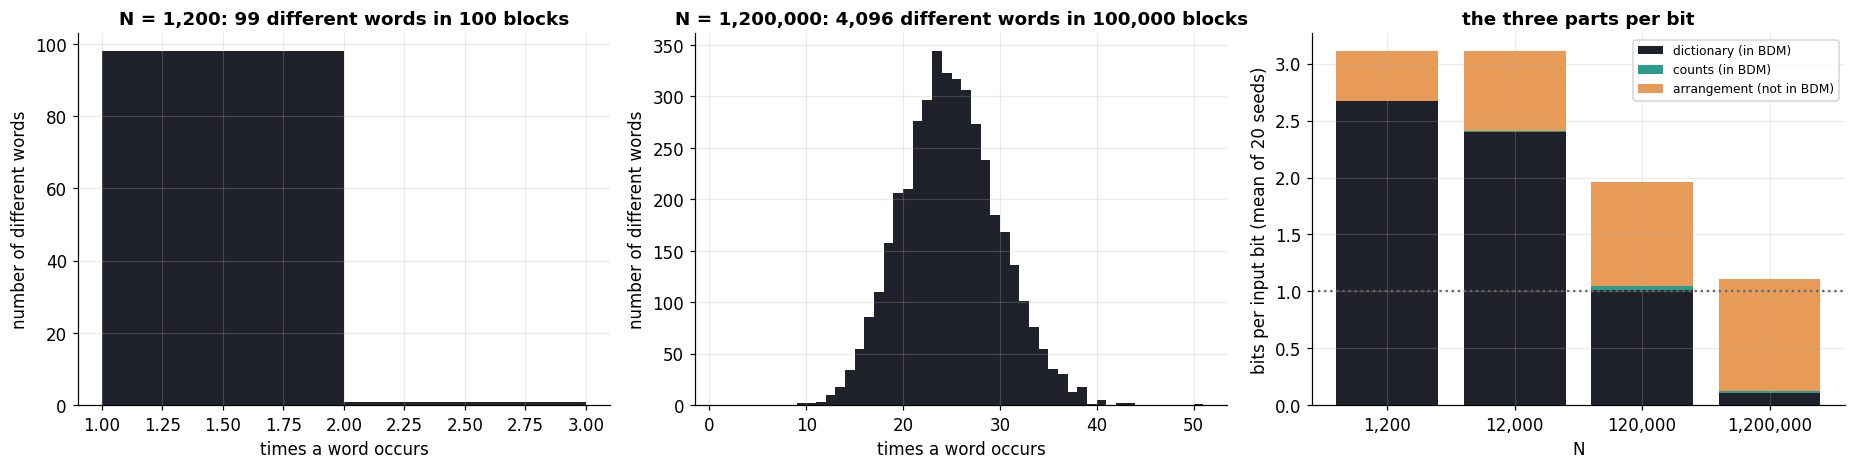

In [16]:
h1_rows = {}
for N in (1200, 1200000):
    r_ = P.rng("H1", N, 0)
    s_ = "".join(r_.choice("01") for _ in range(N))
    p_ = block_code_parts(s_, block=12)
    saved_ = next(r for r in H1["rows"] if r["N"] == N and r["seed"] == 0)
    assert abs(p_["bdm"] - saved_["bdm"]) < 1e-6 * saved_["bdm"] and p_["decodable_bits"] == saved_["decodable_bits"]
    h1_rows[N] = p_
    print(f"N = {N:>9,}: m = {p_['m']:>7,} blocks of 12, different words {p_['distinct']:>5,} "
          f"(of 4,096 possible); most frequent word occurs {max(p_['counts'].values())} times")
    print(f"   dictionary  = sum of CTM over the {p_['distinct']:,} different words       = {p_['dictionary_bits']:>12,.1f}")
    print(f"   counts      = sum of log2(times) over those words           = {p_['count_bits']:>12,.1f}")
    print(f"   BDM         = dictionary + counts                           = {p_['bdm']:>12,.1f}  -> BDM / N = {p_['bdm'] / N:.3f}")
    print(f"   arrangement = log2(m! / prod(times!))                        = {p_['arrangement_bits']:>12,.1f}")
    print(f"   decodable   = whole-bit code of all three                   = {p_['decodable_bits']:>12,}  -> per bit {p_['decodable_bits'] / N:.3f}")
C12 = sum(ctm_1d(format(i, "012b")) for i in range(4096))
print(f"\nat N = 1,200,000 every one of the 4,096 words occurs, so the dictionary is the whole table: C_12 = {C12:,.1f}")
assert h1_rows[1200000]["distinct"] == 4096 and abs(h1_rows[1200000]["dictionary_bits"] - C12) < 1e-6
fig, ax = plt.subplots(1, 3, figsize=(17, 4.4))
for a_, N in zip(ax[:2], (1200, 1200000)):
    cnts = list(h1_rows[N]["counts"].values())
    a_.hist(cnts, bins=range(1, max(cnts) + 2), color=INK)
    a_.set(xlabel="times a word occurs", ylabel="number of different words",
           title=f"N = {N:,}: {h1_rows[N]['distinct']:,} different words in {h1_rows[N]['m']:,} blocks")
Ns_ = sorted({r["N"] for r in H1["rows"]})
parts_ = {k: [np.mean([r[k] / r["N"] for r in H1["rows"] if r["N"] == N]) for N in Ns_]
          for k in ("dictionary_bits", "count_bits", "arrangement_bits")}
xs_ = np.arange(len(Ns_))
ax[2].bar(xs_, parts_["dictionary_bits"], color=INK, label="dictionary (in BDM)")
ax[2].bar(xs_, parts_["count_bits"], bottom=parts_["dictionary_bits"], color=OK, label="counts (in BDM)")
ax[2].bar(xs_, parts_["arrangement_bits"], bottom=np.add(parts_["dictionary_bits"], parts_["count_bits"]),
          color=BAD, alpha=.75, label="arrangement (not in BDM)")
ax[2].axhline(1, color="0.4", ls=":")
ax[2].set(xticks=xs_, xticklabels=[f"{N:,}" for N in Ns_], xlabel="N", ylabel="bits per input bit (mean of 20 seeds)",
          title="the three parts per bit"); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

**How the reading follows from these numbers.** At 1,200 bits almost every block is a new word,
so BDM pays a full CTM, about 32 bits, for nearly every 12-bit block: more than 2.6 bits per
bit. At 1,200,000 bits all 4,096 words have been seen many times. The dictionary is capped at
the whole table, 133,138.5 bits, and each further block adds only a sliver of log2. So BDM
per bit falls towards zero. The information has not vanished: it has moved into the
arrangement, the red part, which BDM does not count. The three criteria of H1 are read
directly from the 20-seed means:

* (a) largest / smallest mean BDM/N > 5;
* (b) mean BDM/N at 1.2 million < 0.2;
* (c) decodable/N ≥ 0.95 for every one of the 80 strings, with a mean in [1.0, 1.2] at
  1.2 million.

**Reading.** H1 is supported on all three pre-registered criteria. On fair coins, BDM per bit
falls from 2.67 at 1,200 bits to 0.127 at 1,200,000 bits (20 seeds per length, plotted
individually). At first it is *above* one bit per bit, because a 12-bit word costs between
25.6 and 37.5 bits of CTM. In the end it is far *below*, because once every word has been
seen, each new block adds only a logarithm. The decodable code, which also pays for the
arrangement, falls towards one bit per bit and ends at 1.13. So **BDM is not a code length**,
and its value per bit depends on how long the input is, even when there is no structure at
all. Comparing BDM across objects of different sizes therefore compares different regimes of
the measure. This is the mechanism behind the pathinfo finding that BDM tracks molecule size
at r = 0.998.

## 3b · Abstraction: replace each word by a short code, and look again

**Why this experiment.** The next version of our deconvolution is planned to work on
*abstracted* inputs. The words of a string are replaced by short codes, giving a simpler
representation of the same object. The analysis is then repeated on that representation, and
again on the next one, at several levels. The hope is twofold: less work at each level,
because the string gets shorter, and a wider view of relationships, because one window at a
higher level spans several words of the level below. This section tests what that does to
BDM, and to Shannon entropy used as a foil, before the idea is built into anything.

**The procedure, exactly as asked.**

1. Take an input, a word length *b* and a step *s*.
2. List the windows pybdm actually reads (the same partition as §2b, taken from
   `bdm_1d_trace`) and count the **different** words among them: *k*.
3. Give each different word a code of c = ⌈log2 k⌉ bits, in order of first appearance. With
   4 different words the codes are 00, 01, 10, 11. First appearance is the same rule pybdm
   uses for its own keys (step 3 of §2b), so the labelling is canonical rather than chosen.
4. Write the codes in the order of the windows: this is the **abstracted input**.
5. Run pybdm on the abstracted input with a block of c·⌊12/c⌋ bits, so that every window
   holds ⌊12/c⌋ whole codes. One window therefore covers ⌊12/c⌋ **original words**: this
   is the "wider view".
6. Compare with Shannon entropy, a foil and not a measure in this programme, computed two
   ways: over the bits of the input (n·H1), and over the words (m·H_w, m = number of windows).

**Status.** This is an **exploratory** experiment, outside the frozen protocol. Seeds are
pinned, and the abstraction helper is written in this notebook because no owner exists yet.
When the new deconvolution adopts it, it moves to its owner.

input            : 011010011010011010011010011010011010011010011010 (48 bits)
words read (b=4) : 0110 1001 1010 0110 1001 1010 0110 1001 1010 0110 1001 1010
different words  : k = 3 -> code width c = ceil(log2 3) = 2 bits
code table       : 0110 -> 00, 1001 -> 01, 1010 -> 10
abstracted input : 000110000110000110000110 (24 bits)
BDM of the input with block 4      : 31.072
BDM of the abstraction, block 12    : 33.816  (each window holds 6 codes = 24 original bits)
Shannon foil: bits 48.00, words 19.02; words of the abstraction 19.02


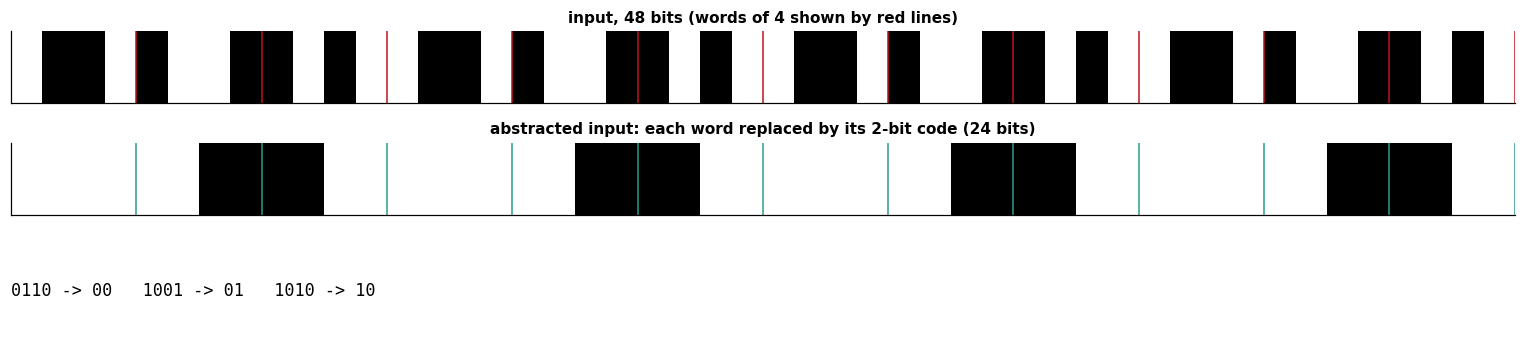

In [17]:
def pybdm_words(x, b, step):
    """The windows pybdm reads, in order (from the owner's trace)."""
    kw = dict(block=b, remainder="recursive") if step == b else dict(block=b, shift=step, remainder="drop")
    return [r["block"] for r in bdm_1d_trace(x, **kw)["rows"]], kw

def abstract(words, order="first", seed=0):
    """Codes of ceil(log2 k) bits for the k different words; returns (abstracted, code table, c)."""
    first = list(dict.fromkeys(words))
    cnt = collections.Counter(words)
    if order == "frequency":
        first = sorted(first, key=lambda w: (-cnt[w], first.index(w)))
    elif order == "random":
        random.Random(seed).shuffle(first)
    c = max(1, math.ceil(math.log2(len(first))))
    table = {w: format(i, f"0{c}b") for i, w in enumerate(first)}
    return "".join(table[w] for w in words), table, c

def bdm_abstracted(a, c):
    B = min(c * (12 // c), len(a))
    return bdm_1d(a, block=B, remainder="recursive"), B

def shannon_bits(x):
    """FOIL ONLY: n * H1 over the 0/1 frequencies of x."""
    n = len(x); return sum(-v * math.log2(v / n) for v in collections.Counter(x).values())

def shannon_words(words):
    """FOIL ONLY: m * H over the word frequencies."""
    m = len(words); return sum(-v * math.log2(v / m) for v in collections.Counter(words).values())

# A worked example by hand: the period-6 string, 48 bits, words of 4, no overlap.
x = "011010" * 8
words, kw = pybdm_words(x, 4, 4)
a, table, c = abstract(words)
B = c * (12 // c)
print("input            :", x, f"({len(x)} bits)")
print("words read (b=4) :", " ".join(words))
print(f"different words  : k = {len(table)} -> code width c = ceil(log2 {len(table)}) = {c} bits")
print("code table       :", ", ".join(f"{w} -> {cd}" for w, cd in table.items()))
print("abstracted input :", a, f"({len(a)} bits)")
print(f"BDM of the input with block 4      : {bdm_1d(x, **kw):.3f}")
print(f"BDM of the abstraction, block {B}    : {bdm_abstracted(a, c)[0]:.3f}  "
      f"(each window holds {12 // c} codes = {12 // c * 4} original bits)")
print(f"Shannon foil: bits {shannon_bits(x):.2f}, words {shannon_words(words):.2f}; "
      f"words of the abstraction {shannon_words(wrap(a, c)):.2f}")
assert (len(table), c, a[:12]) == (3, 2, "000110000110")
assert abs(shannon_words(words) - shannon_words(wrap(a, c))) < 1e-12   # a relabelling keeps word entropy exactly

fig, ax = plt.subplots(3, 1, figsize=(14, 3.2))
show_bits(ax[0], [x], "input, 48 bits (words of 4 shown by red lines)")
for i in range(0, 49, 4):
    ax[0].axvline(i - .5, color=HL, lw=1)
show_bits(ax[1], ["".join(table[w] for w in words)], f"abstracted input: each word replaced by its {c}-bit code ({len(a)} bits)")
for i in range(0, len(a) + 1, c):
    ax[1].axvline(i - .5, color=OK, lw=1)
ax[2].axis("off")
ax[2].text(0, .5, "   ".join(f"{w} -> {cd}" for w, cd in table.items()), family="monospace", fontsize=11, va="center")
plt.tight_layout(); plt.show()

**The experiment.** The seven families of §1, 30 strings each, 1,536 bits, under four settings
of (word, step): (4, 4), (8, 8), (12, 12) without overlap, and (8, 4) with overlap 4. For every
string the cell records *k*, *c*, BDM of the input, BDM of the abstraction, and the two
Shannon foils. As a control it also **shuffles the words**, rebuilds the input and its
abstraction, and measures them again. §3 showed that a shuffle cannot change plain BDM;
the question is whether it changes the abstraction.

In [18]:
SETTINGS = [(4, 4), (8, 8), (12, 12), (8, 4)]
ABS = []
for b, step in SETTINGS:
    for fid in P.FAMILIES:
        for j in range(30):
            x = P.family(fid, 1536, P.rng("ABS", fid, j))
            words, kw = pybdm_words(x, b, step)
            a, table, c = abstract(words)
            sh = words[:]; random.Random(j).shuffle(sh)
            a_sh = "".join(table[w] for w in sh)
            rec = dict(b=b, step=step, family=fid, j=j, k=len(table), c=c, m=len(words),
                       bdm=bdm_1d(x, **kw), bdm_abs=bdm_abstracted(a, c)[0],
                       bdm_abs_shuffled=bdm_abstracted(a_sh, c)[0],
                       H_bits=shannon_bits(x), H_words=shannon_words(words),
                       view_bits=(12 // c) * b if c <= 12 else b)
            if step == b:      # a shuffled input exists only when words tile the string
                rec["bdm_shuffled"] = bdm_1d("".join(sh), **kw)
            ABS.append(rec)
print(f"{len(ABS)} (string, setting) records: 7 families x 30 strings x {len(SETTINGS)} settings")
assert len(ABS) == 7 * 30 * len(SETTINGS)
assert all(abs(r["bdm_shuffled"] - r["bdm"]) < 1e-6 for r in ABS if "bdm_shuffled" in r)   # §3, T1 again

840 (string, setting) records: 7 families x 30 strings x 4 settings


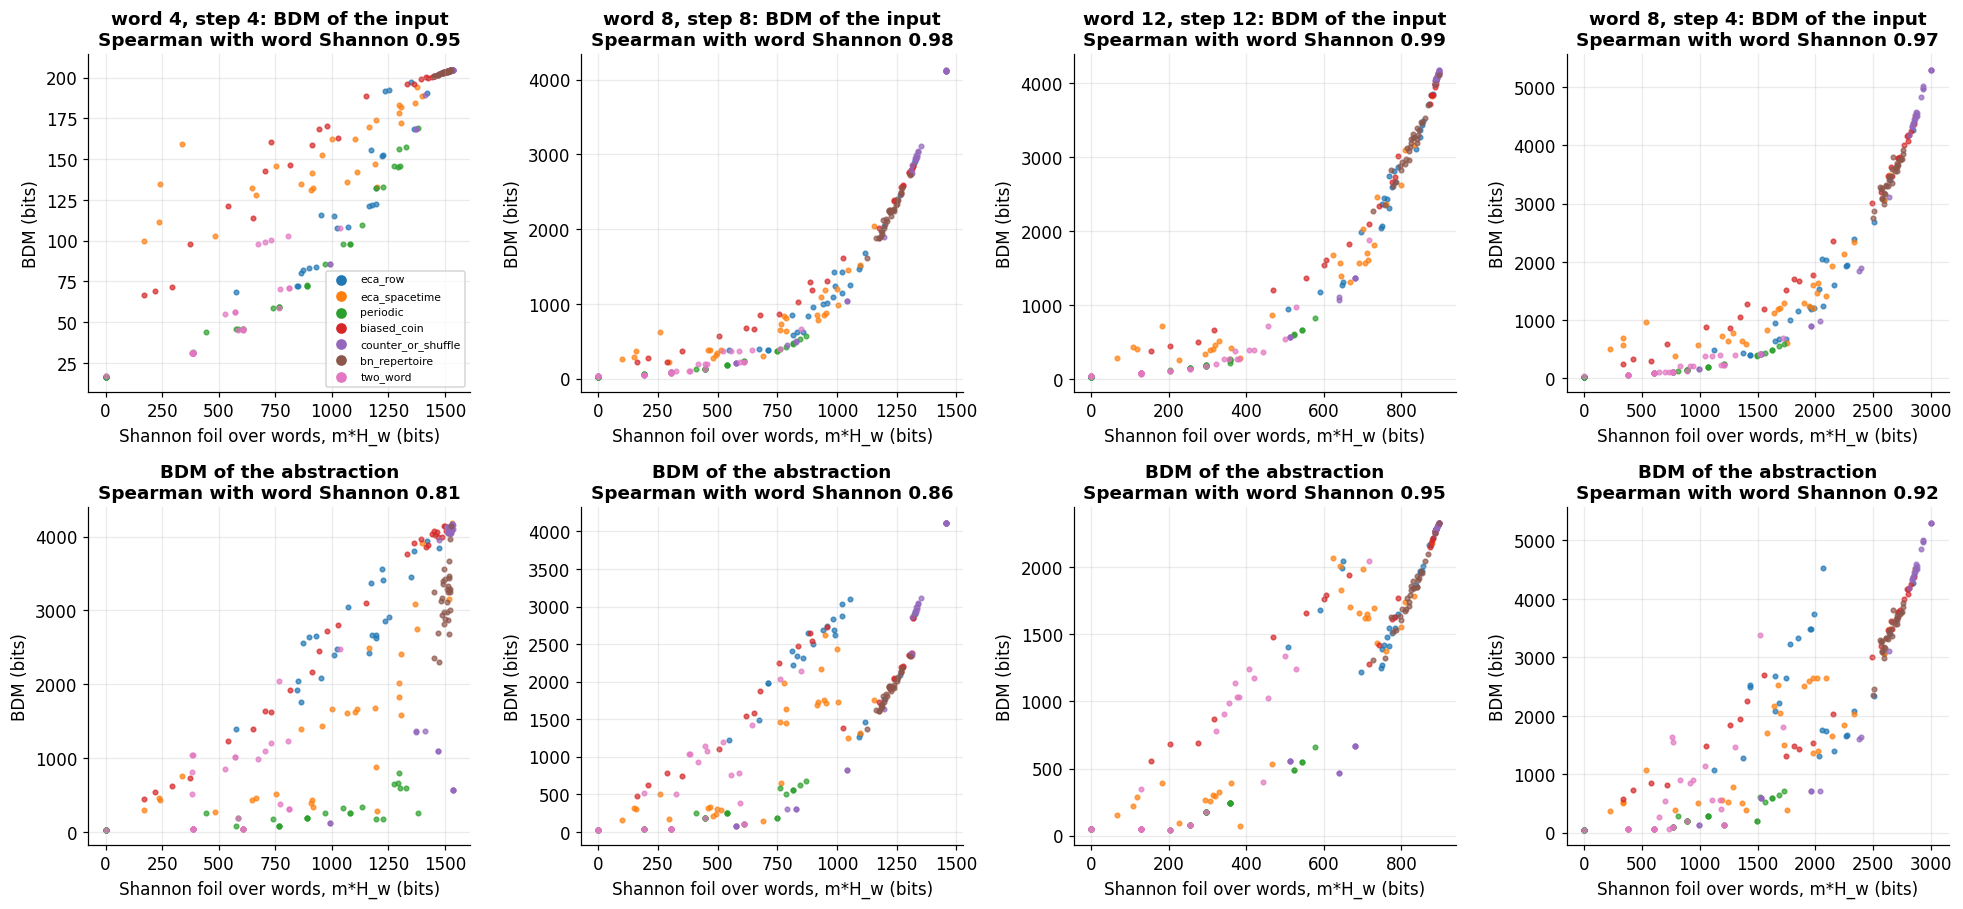

word  4, step  4: Spearman  BDM~word-Shannon 0.95 | abstracted BDM~word-Shannon 0.81 | BDM~bit-Shannon 0.27 | abstracted~input BDM 0.84
word  8, step  8: Spearman  BDM~word-Shannon 0.98 | abstracted BDM~word-Shannon 0.86 | BDM~bit-Shannon 0.13 | abstracted~input BDM 0.88
word 12, step 12: Spearman  BDM~word-Shannon 0.99 | abstracted BDM~word-Shannon 0.95 | BDM~bit-Shannon 0.11 | abstracted~input BDM 0.96
word  8, step  4: Spearman  BDM~word-Shannon 0.97 | abstracted BDM~word-Shannon 0.92 | BDM~bit-Shannon 0.15 | abstracted~input BDM 0.94


In [19]:
from scipy.stats import spearmanr
fam_col = {f: plt.cm.tab10(i) for i, f in enumerate(P.FAMILIES)}
fig, ax = plt.subplots(2, 4, figsize=(18, 8.4))
summary = {}
for j, (b, step) in enumerate(SETTINGS):
    rr = [r for r in ABS if r["b"] == b and r["step"] == step]
    Hw = np.array([r["H_words"] for r in rr]); o = np.array([r["bdm"] for r in rr]); a_ = np.array([r["bdm_abs"] for r in rr])
    Hb = np.array([r["H_bits"] for r in rr])
    rho_o, rho_a = spearmanr(o, Hw).correlation, spearmanr(a_, Hw).correlation
    rho_ob = spearmanr(o, Hb).correlation
    summary[b, step] = dict(rho_bdm_Hw=rho_o, rho_abs_Hw=rho_a, rho_bdm_Hbits=rho_ob,
                            rho_abs_bdm=spearmanr(a_, o).correlation)
    for r in rr:
        ax[0, j].scatter(r["H_words"], r["bdm"], s=9, color=fam_col[r["family"]], alpha=.7)
        ax[1, j].scatter(r["H_words"], r["bdm_abs"], s=9, color=fam_col[r["family"]], alpha=.7)
    ax[0, j].set(title=f"word {b}, step {step}: BDM of the input\nSpearman with word Shannon {rho_o:.2f}",
                 xlabel="Shannon foil over words, m*H_w (bits)", ylabel="BDM (bits)")
    ax[1, j].set(title=f"BDM of the abstraction\nSpearman with word Shannon {rho_a:.2f}",
                 xlabel="Shannon foil over words, m*H_w (bits)", ylabel="BDM (bits)")
for f, col in fam_col.items():
    ax[0, 0].scatter([], [], color=col, label=f)
ax[0, 0].legend(fontsize=7)
plt.tight_layout(); plt.show()
for (b, step), v in summary.items():
    print(f"word {b:>2}, step {step:>2}: Spearman  BDM~word-Shannon {v['rho_bdm_Hw']:.2f} | "
          f"abstracted BDM~word-Shannon {v['rho_abs_Hw']:.2f} | BDM~bit-Shannon {v['rho_bdm_Hbits']:.2f} | "
          f"abstracted~input BDM {v['rho_abs_bdm']:.2f}")
assert [round(summary[k]["rho_bdm_Hw"], 2) for k in SETTINGS] == [0.95, 0.98, 0.99, 0.97]
assert [round(summary[k]["rho_abs_Hw"], 2) for k in SETTINGS] == [0.81, 0.86, 0.95, 0.92]
assert [round(summary[k]["rho_abs_bdm"], 2) for k in SETTINGS] == [0.84, 0.88, 0.96, 0.94]

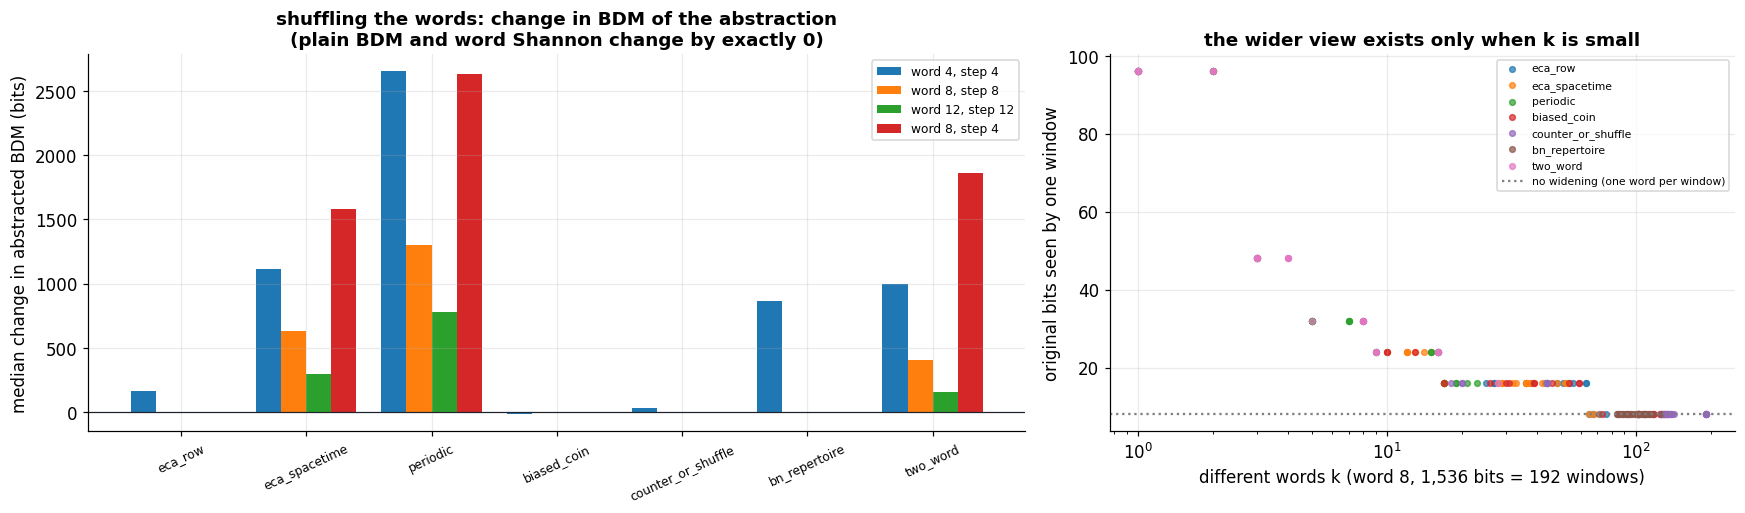

word  4, step  4: abstraction sees the shuffle in 96% of 210 strings; its window is wider than one word in 100%
word  8, step  8: abstraction sees the shuffle in 55% of 210 strings; its window is wider than one word in 62%
word 12, step 12: abstraction sees the shuffle in 45% of 210 strings; its window is wider than one word in 52%
word  8, step  4: abstraction sees the shuffle in 51% of 210 strings; its window is wider than one word in 56%


In [20]:
# The order control: shuffle the words. Plain BDM and both Shannon foils cannot move; does the abstraction?
fig, ax = plt.subplots(1, 2, figsize=(16, 4.8), gridspec_kw={"width_ratios": [1.5, 1]})
w = .2
for j, (b, step) in enumerate(SETTINGS):
    med = [np.median([r["bdm_abs_shuffled"] - r["bdm_abs"] for r in ABS
                      if r["b"] == b and r["step"] == step and r["family"] == f]) for f in P.FAMILIES]
    ax[0].bar(np.arange(7) + (j - 1.5) * w, med, w, label=f"word {b}, step {step}")
ax[0].axhline(0, color=INK, lw=.8)
ax[0].set(xticks=range(7), ylabel="median change in abstracted BDM (bits)",
          title="shuffling the words: change in BDM of the abstraction\n(plain BDM and word Shannon change by exactly 0)")
ax[0].set_xticklabels(P.FAMILIES, rotation=25, fontsize=8); ax[0].legend(fontsize=8)
for f in P.FAMILIES:
    rr = [r for r in ABS if r["b"] == 8 and r["step"] == 8 and r["family"] == f]
    ax[1].scatter([r["k"] for r in rr], [r["view_bits"] for r in rr], s=14, color=fam_col[f], label=f, alpha=.7)
ax[1].axhline(8, color="0.5", ls=":", label="no widening (one word per window)")
ax[1].set(xscale="log", xlabel="different words k (word 8, 1,536 bits = 192 windows)",
          ylabel="original bits seen by one window", title="the wider view exists only when k is small")
ax[1].legend(fontsize=7)
plt.tight_layout(); plt.show()
for b, step in SETTINGS:
    rr = [r for r in ABS if r["b"] == b and r["step"] == step]
    moved = np.mean([abs(r["bdm_abs_shuffled"] - r["bdm_abs"]) > 1e-6 for r in rr])
    wide = np.mean([r["view_bits"] > b for r in rr])
    print(f"word {b:>2}, step {step:>2}: abstraction sees the shuffle in {moved:.0%} of 210 strings; "
          f"its window is wider than one word in {wide:.0%}")
seen = [round(np.mean([abs(r["bdm_abs_shuffled"] - r["bdm_abs"]) > 1e-6 for r in ABS if (r["b"], r["step"]) == k]), 2) for k in SETTINGS]
assert seen == [0.96, 0.55, 0.45, 0.51], seen

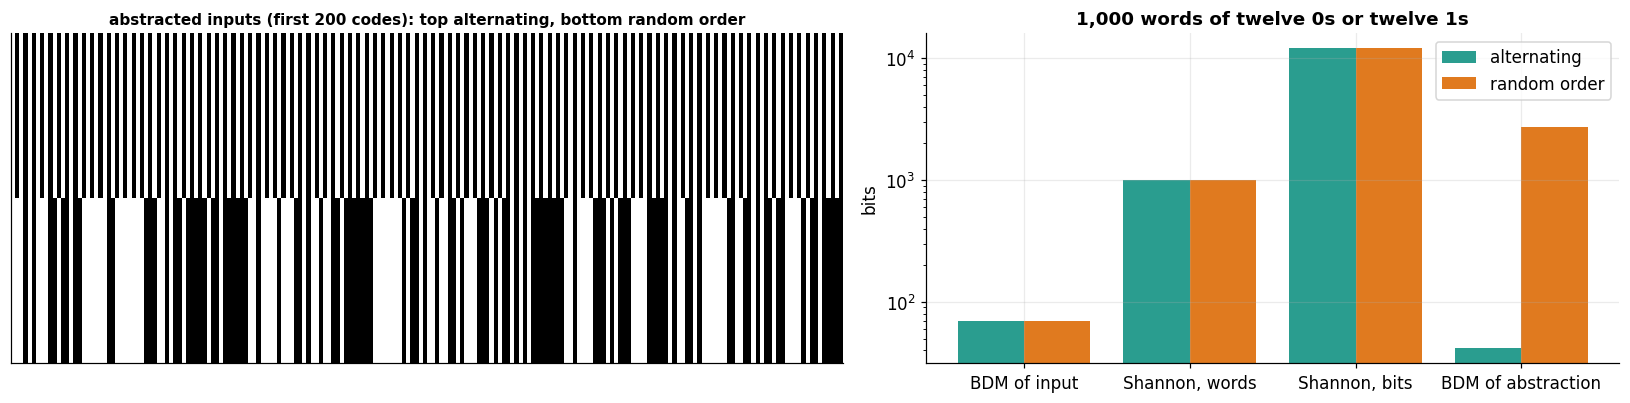

alternating   BDM 69.15 | Shannon words 1000.0, bits 12000.0 | abstracted BDM 41.62
random order  BDM 69.15 | Shannon words 1000.0, bits 12000.0 | abstracted BDM 2699.19


In [21]:
# The decisive pair from §4 (DM1): same words, same counts, different order.
m = 1000
alt = "".join(("1" if i % 2 else "0") * 12 for i in range(m))
seq = [0] * (m // 2) + [1] * (m - m // 2); P.rng("DM1", m).shuffle(seq)
rnd = "".join(("1" if v else "0") * 12 for v in seq)
pair = {}
for name, s in (("alternating", alt), ("random order", rnd)):
    words, kw = pybdm_words(s, 12, 12); a, table, c = abstract(words)
    pair[name] = dict(bdm=bdm_1d(s, **kw), H_words=shannon_words(words), H_bits=shannon_bits(s),
                      abs=a, bdm_abs=bdm_abstracted(a, c)[0])
fig, ax = plt.subplots(1, 2, figsize=(15, 3.8), gridspec_kw={"width_ratios": [1.2, 1]})
show_bits(ax[0], [pair["alternating"]["abs"][:200], pair["random order"]["abs"][:200]],
          "abstracted inputs (first 200 codes): top alternating, bottom random order")
lab = ["BDM of input", "Shannon, words", "Shannon, bits", "BDM of abstraction"]
xx = np.arange(4)
for off, name, col in ((-.2, "alternating", OK), (.2, "random order", BAD)):
    p = pair[name]
    ax[1].bar(xx + off, [p["bdm"], p["H_words"], p["H_bits"], p["bdm_abs"]], .4, color=col, label=name)
ax[1].set(xticks=xx, xticklabels=lab, yscale="log", ylabel="bits", title="1,000 words of twelve 0s or twelve 1s")
ax[1].legend(); plt.tight_layout(); plt.show()
for name, p in pair.items():
    print(f"{name:<13} BDM {p['bdm']:.2f} | Shannon words {p['H_words']:.1f}, bits {p['H_bits']:.1f} | abstracted BDM {p['bdm_abs']:.2f}")
assert abs(pair["alternating"]["bdm"] - pair["random order"]["bdm"]) < 1e-9
assert abs(pair["alternating"]["H_words"] - pair["random order"]["H_words"]) < 1e-9
assert (round(pair["alternating"]["bdm_abs"], 2), round(pair["random order"]["bdm_abs"], 2)) == (41.62, 2699.19)

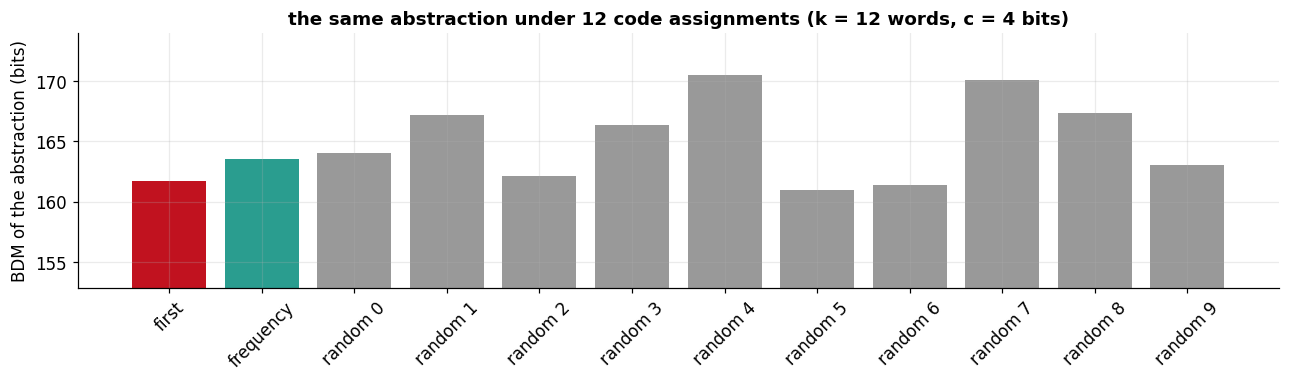

range over labellings: 160.9 to 170.5 bits (5.9% of the median); word Shannon is identical for all: 98.8


In [22]:
# How much does the arbitrary choice of codes matter? One structured string, 12 labellings.
x = P.family("eca_spacetime", 1536, P.rng("ABS", "eca_spacetime", 3))
words, _ = pybdm_words(x, 8, 8)
lab_vals = {}
for order, seed in [("first", 0), ("frequency", 0)] + [("random", s) for s in range(10)]:
    a, table, c = abstract(words, order, seed)
    lab_vals[f"{order}{'' if order != 'random' else ' ' + str(seed)}"] = bdm_abstracted(a, c)[0]
fig, ax = plt.subplots(figsize=(12, 3.6))
ax.bar(list(lab_vals), list(lab_vals.values()), color=[HL, OK] + ["0.6"] * 10)
ax.set(ylabel="BDM of the abstraction (bits)", ylim=(min(lab_vals.values()) * .95, max(lab_vals.values()) * 1.02),
       title=f"the same abstraction under 12 code assignments (k = {len(table)} words, c = {c} bits)")
ax.tick_params(axis="x", labelrotation=45); plt.tight_layout(); plt.show()
v = np.array(list(lab_vals.values()))
print(f"range over labellings: {v.min():.1f} to {v.max():.1f} bits ({(v.max() - v.min()) / np.median(v):.1%} of the median); "
      f"word Shannon is identical for all: {shannon_words(words):.1f}")
assert round((v.max() - v.min()) / np.median(v), 3) == 0.059

**Several levels.** The planned deconvolution applies the step again: the codes of level 1 are
grouped in pairs, each pair becomes a word of level 2, those words get codes, and so on. Each
level halves the number of words, and one level-L word stands for 8·2^(L−1) original bits.
Below, the first string of each family, from level 1 to level 6.

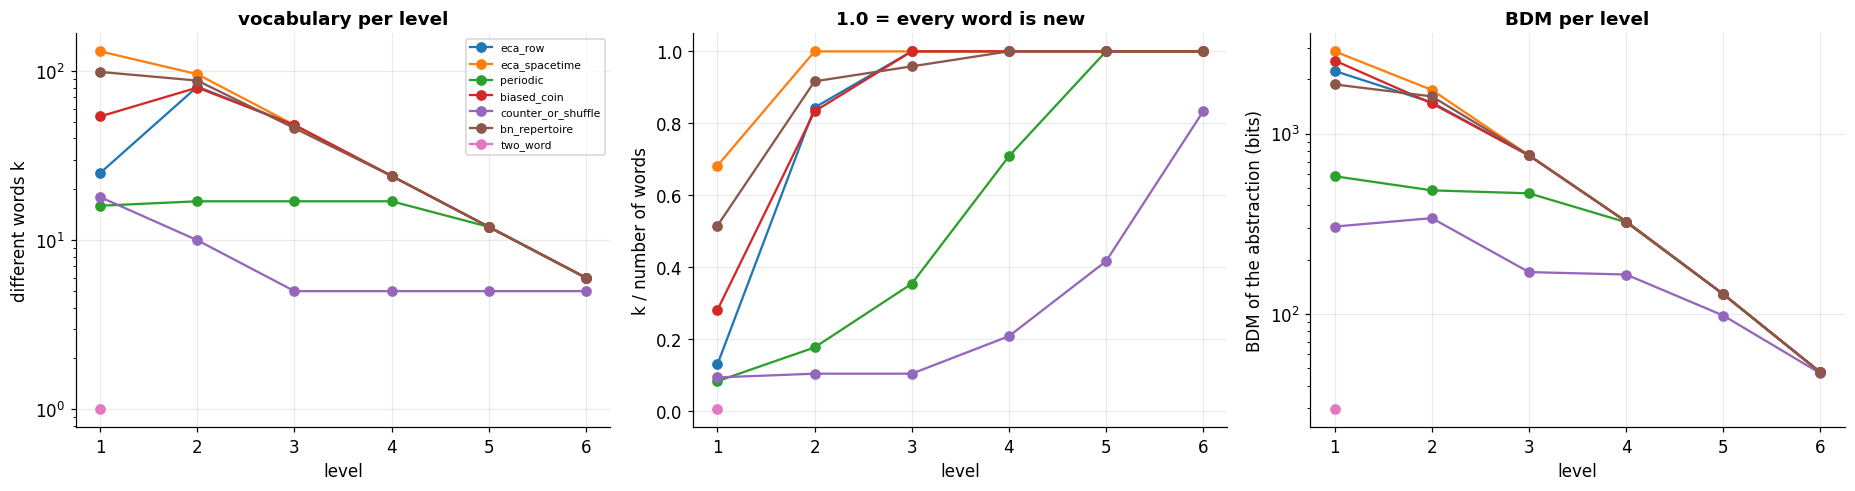

eca_row            L1: k=25/192  L2: k=81/96  L3: k=48/48  L4: k=24/24  L5: k=12/12  L6: k=6/6
eca_spacetime      L1: k=131/192  L2: k=96/96  L3: k=48/48  L4: k=24/24  L5: k=12/12  L6: k=6/6
periodic           L1: k=16/192  L2: k=17/96  L3: k=17/48  L4: k=17/24  L5: k=12/12  L6: k=6/6
biased_coin        L1: k=54/192  L2: k=80/96  L3: k=48/48  L4: k=24/24  L5: k=12/12  L6: k=6/6
counter_or_shuffle L1: k=18/192  L2: k=10/96  L3: k=5/48  L4: k=5/24  L5: k=5/12  L6: k=5/6
bn_repertoire      L1: k=99/192  L2: k=88/96  L3: k=46/48  L4: k=24/24  L5: k=12/12  L6: k=6/6
two_word           L1: k=1/192

families whose level-3 words are all new: ['eca_row', 'eca_spacetime', 'biased_coin']
their level-3 abstractions are identical strings: True


In [23]:
def levels(x, b=8, g=2, top=6):
    cur = [x[i:i + b] for i in range(0, len(x) - len(x) % b, b)]
    out = []
    for L in range(1, top + 1):
        a, table, c = abstract(cur)
        out.append(dict(level=L, words=len(cur), k=len(table), c=c, bits=len(a), bdm=bdm_abstracted(a, c)[0],
                        dictionary_literal=len(table) * len(cur[0]), span=b * g ** (L - 1), abs=a))
        codes = wrap(a, c)
        if len(table) == 1 or len(codes) < 2 * g:
            break
        cur = ["".join(codes[i:i + g]) for i in range(0, len(codes) - len(codes) % g, g)]
    return out
LV = {f: levels(P.family(f, 1536, P.rng("ABS", f, 0))) for f in P.FAMILIES}
fig, ax = plt.subplots(1, 3, figsize=(17, 4.6))
for f, out in LV.items():
    Ls = [d["level"] for d in out]
    ax[0].plot(Ls, [d["k"] for d in out], "o-", color=fam_col[f], label=f)
    ax[1].plot(Ls, [d["k"] / d["words"] for d in out], "o-", color=fam_col[f])
    ax[2].plot(Ls, [d["bdm"] for d in out], "o-", color=fam_col[f])
ax[0].set(xlabel="level", ylabel="different words k", yscale="log", title="vocabulary per level"); ax[0].legend(fontsize=7)
ax[1].set(xlabel="level", ylabel="k / number of words", title="1.0 = every word is new")
ax[2].set(xlabel="level", ylabel="BDM of the abstraction (bits)", yscale="log", title="BDM per level")
plt.tight_layout(); plt.show()
for f, out in LV.items():
    print(f"{f:<19}" + "  ".join(f"L{d['level']}: k={d['k']}/{d['words']}" for d in out))
same = [f for f in P.FAMILIES if len(LV[f]) >= 3 and LV[f][2]["k"] == LV[f][2]["words"]]
print("\nfamilies whose level-3 words are all new:", same)
print("their level-3 abstractions are identical strings:", len({LV[f][2]["abs"] for f in same}) == 1)
assert same == ["eca_row", "eca_spacetime", "biased_coin"] and len({LV[f][2]["abs"] for f in same}) == 1

**What this experiment shows, and what it means for the new deconvolution.**

**1. Is there a trend against Shannon?** Yes, and it points the useful way. Plain BDM tracks
the word-level Shannon foil almost perfectly in every setting (Spearman 0.95–0.99): both are
driven by how many different words there are and how often each occurs. BDM of the
abstraction tracks it **less** (0.81–0.95). The gap is not noise. In the scatter plots, the
families that leave the Shannon curve are the ones with order between their words: periodic
strings fall far below it, and cellular-automaton rows and diagrams move away from it.
Word-level Shannon is *exactly* unchanged by abstraction, because the codes are a renaming of
the words, so whatever BDM of the abstraction adds is information that no histogram contains.

**2. Abstraction makes order visible.** This is the central finding. §3 proved that plain BDM
cannot see the order of whole blocks (P1), and the shuffle control confirms it here: 0 change,
every time. BDM of the abstraction sees the shuffle in 96 % of strings at word 4, and in about
half of them at words 8 and 12. On the pair of §4, the same 1,000 words in alternating and in
random order, plain BDM gives 69.15 bits for both, and both Shannon foils are identical. BDM of
the abstraction gives **41.62 against 2,699.19**. The mechanism is the one the design intends:
after abstraction, one BDM window spans several original words. What used to be order
*between* blocks becomes content *inside* a block, and content inside a block is exactly what
CTM measures.

**3. The wider view exists only where there is structure.** The window widens only if the
number of different words k is small, so that the codes are shorter than the words (right-hand
panel of the shuffle figure). On noise, almost every word is new, the code is as long as the
word, and the abstraction is a mere renaming: abstracted and plain BDM then agree (Spearman up
to 0.96 at word 12). So abstraction **reduces work exactly where structure exists, and costs
nothing where it does not**. That is the property one wants in a multi-level method.

**4. The abstraction alone is not a description.** Two observations make this concrete. The
codes are arbitrary: 12 labellings of one string move its abstracted BDM by 5.9 % while word
Shannon stays fixed, so a canonical rule (first appearance, as pybdm itself uses for its keys)
is required for reproducible numbers. And at high levels, once every word is new, the
abstraction of three unrelated families is **the identical string** 0, 1, 2, …, because all
the information has moved into the dictionary (level plots). A complete representation is
therefore the abstraction **plus its dictionary**, both paid for, as with the complete codes
of §10 (P4). Dropping the dictionary would compare objects that no longer determine their
inputs.

**5. What this means for the next deconvolution.** Four design rules follow from what was
measured here, not from taste:

* **Label canonically** (first appearance). Otherwise the numbers depend on an arbitrary
  choice.
* **Charge the dictionary at every level.** The pair (dictionary, abstraction) is a complete
  code; the abstraction alone is not.
* **Stop when the vocabulary saturates.** When k equals the number of words at a level, the
  next level is a pure renaming and carries nothing. The ratio k / words in the level plots
  is a natural stopping rule.
* **Read levels for relationships, not single values.** The gain from abstraction is the
  order information it exposes between neighbouring words, the very thing plain BDM and
  Shannon both discard. Our index sets (L, Ω) describe positions and their relations
  directly, so they are the natural language for that higher level.

**Caution on absolute numbers.** In the worked example the abstraction is half as long as the
input, yet its BDM is slightly higher (33.8 against 31.1 bits). The two are read with
different block lengths (12 against 4), and CTM values grow with the block length (§2b). So
compare BDM values within one setting, or through ranks as above; never across block lengths.

## 4 · Strings that fool BDM, and why

Three deterministic demonstrations (protocol §4, DM1–DM3). Each follows from §3.

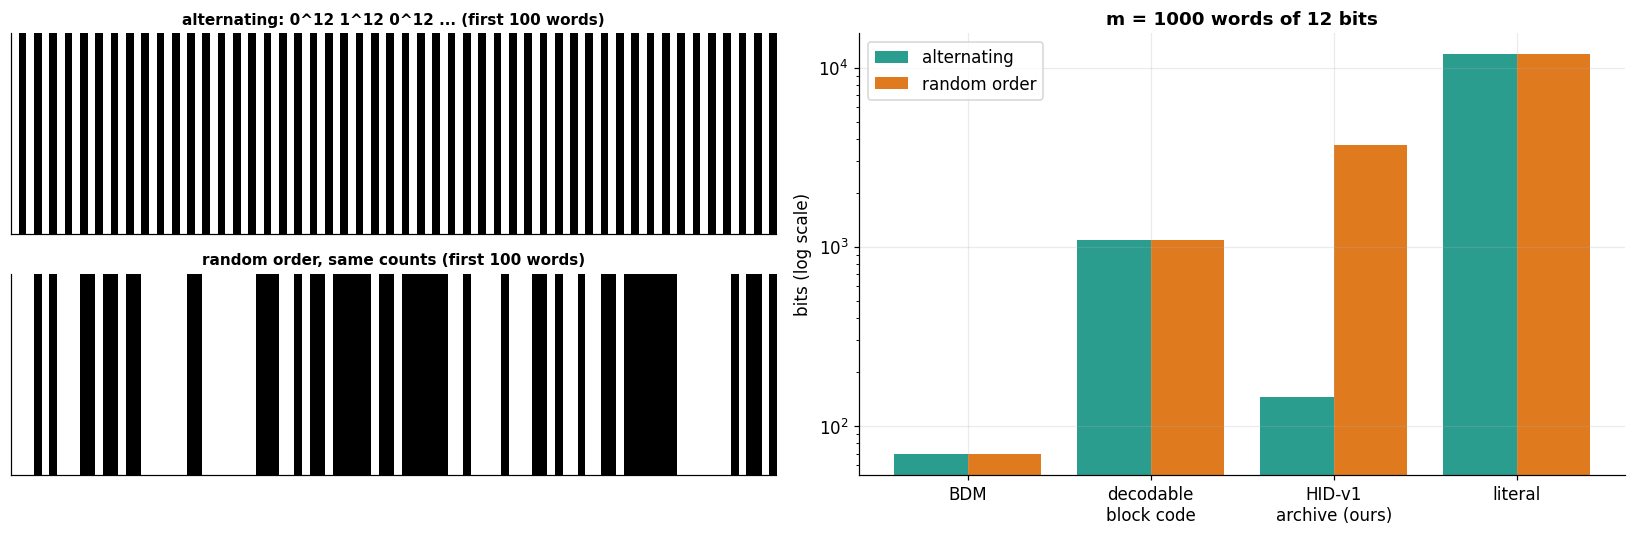

m=   100: BDM alternating 62.51, random 62.51; naming the random order needs about 96.3 bits
m=  1000: BDM alternating 69.15, random 69.15; naming the random order needs about 994.7 bits
m= 10000: BDM alternating 75.80, random 75.80; naming the random order needs about 9993.0 bits
HID-v1 archive: alternating 144 bits, random order 3680 bits


In [24]:
DM1 = {d["m"]: d for d in R["DM"]["DM1"]}
m = 1000
alt = "".join(("1" if i % 2 else "0") * 12 for i in range(m))
seq = [0] * (m // 2) + [1] * (m - m // 2); P.rng("DM1", m).shuffle(seq)
rnd = "".join(("1" if x else "0") * 12 for x in seq)
hid_alt, hid_rnd = infer(alt).archive_bits, infer(rnd).archive_bits
fig = plt.figure(figsize=(15, 5))
a0 = fig.add_subplot(2, 2, 1); show_bits(a0, [alt[:1200]], "alternating: 0^12 1^12 0^12 ... (first 100 words)")
a1 = fig.add_subplot(2, 2, 3); show_bits(a1, [rnd[:1200]], "random order, same counts (first 100 words)")
a2 = fig.add_subplot(1, 2, 2)
labels = ["BDM", "decodable\nblock code", "HID-v1\narchive (ours)", "literal"]
va = [DM1[m]["bdm_alternating"], DM1[m]["decodable_alternating"], hid_alt, 12 * m]
vr = [DM1[m]["bdm_random"], DM1[m]["decodable_random"], hid_rnd, 12 * m]
xx = np.arange(4)
a2.bar(xx - .2, va, .4, color=OK, label="alternating"); a2.bar(xx + .2, vr, .4, color=BAD, label="random order")
a2.set(xticks=xx, xticklabels=labels, yscale="log", ylabel="bits (log scale)", title=f"m = {m} words of 12 bits")
a2.legend(); plt.tight_layout(); plt.show()
for mm, d in DM1.items():
    print(f"m={mm:>6}: BDM alternating {d['bdm_alternating']:.2f}, random {d['bdm_random']:.2f};"
          f" naming the random order needs about {d['arrangement_random']:.1f} bits")
print(f"HID-v1 archive: alternating {hid_alt} bits, random order {hid_rnd} bits")
assert all(abs(d["bdm_alternating"] - d["bdm_random"]) < 1e-9 for d in DM1.values())
assert DM1[m]["decodable_alternating"] == DM1[m]["decodable_random"] and hid_alt < hid_rnd

### Anatomy of DM1: where "69.15 for both" and "994.7 bits" come from

Both strings are 1,000 blocks of 12 bits. Each block is one of two words, `000000000000` or
`111111111111`, and each word occurs 500 times. Only the order differs.

In [25]:
dm_w0, dm_w1 = "0" * 12, "1" * 12
print(f"CTM({dm_w0}) = {ctm_1d(dm_w0):.4f}, CTM({dm_w1}) = {ctm_1d(dm_w1):.4f}  (the same table entry, see 2b step 3)")
print(f"BDM = (CTM + log2 500) + (CTM + log2 500) = 2 x ({ctm_1d(dm_w0):.4f} + {math.log2(500):.4f}) = "
      f"{2 * (ctm_1d(dm_w0) + math.log2(500)):.2f}, for ANY order of the 1,000 blocks")
dm_M = math.comb(1000, 500)
print(f"possible orders with 500 of each = C(1000, 500) = a number with {len(str(dm_M))} digits; "
      f"log2 of it = {math.log2(dm_M):.1f} bits")
print("a random order is, for almost every draw, one of those orders with no shorter description,")
print("so stating it needs about that many bits; the alternating order needs only a few (a two-line program)")
assert abs(2 * (ctm_1d(dm_w0) + math.log2(500)) - R["DM"]["DM1"][1]["bdm_random"]) < 1e-9
assert round(math.log2(dm_M), 1) == 994.7

CTM(000000000000) = 25.6104, CTM(111111111111) = 25.6104  (the same table entry, see 2b step 3)
BDM = (CTM + log2 500) + (CTM + log2 500) = 2 x (25.6104 + 8.9658) = 69.15, for ANY order of the 1,000 blocks
possible orders with 500 of each = C(1000, 500) = a number with 300 digits; log2 of it = 994.7 bits
a random order is, for almost every draw, one of those orders with no shorter description,
so stating it needs about that many bits; the alternating order needs only a few (a two-line program)


**Reading (DM1).** The two strings get **identical BDM at every size**, 75.80 bits at 10,000
words, while naming the random order needs about 9,993 bits. A counting argument (§10)
shows that almost every string with those counts has Kolmogorov complexity near that larger
number. So BDM understates it by an amount that grows without limit.

Note the second pair of bars: the decodable block code is *also* equal for both strings. It
is complete, so it is honest, but it pays full price for any arrangement and cannot exploit
a simple one. **Completeness is not compression: to use a simple order, a code needs a model
of the order.** That is what a generator-level code does: the HID-v1 archive, ours, separates
the two strings.

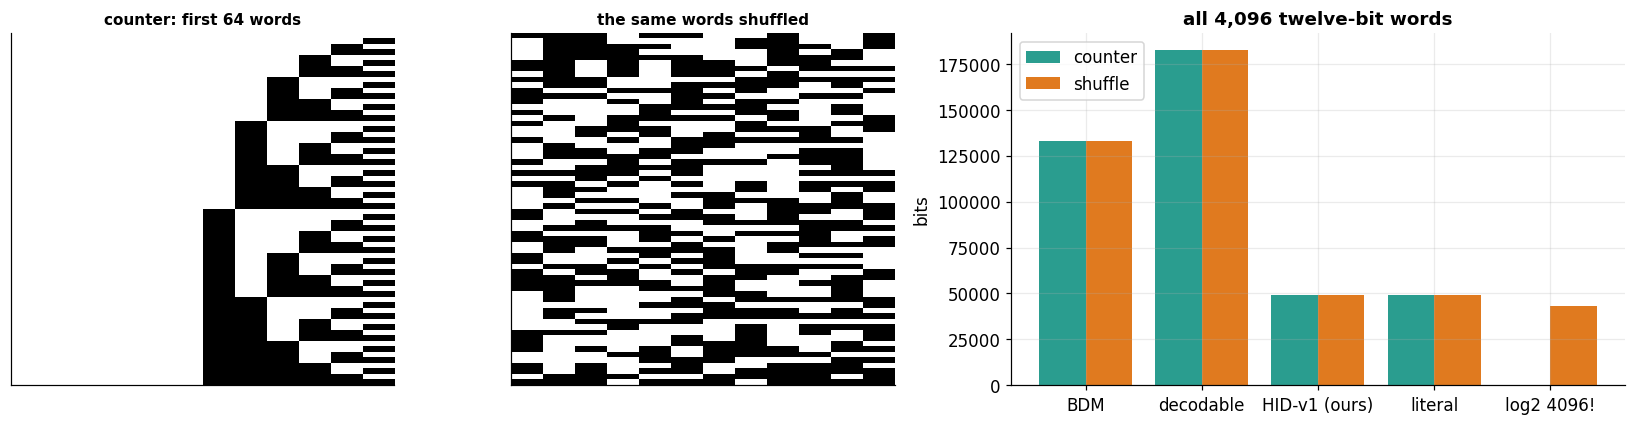

BDM counter 133138.5, shuffle 133138.5; literal 49152; HID counter 49232, shuffle 49232


In [26]:
DM2 = R["DM"]["DM2"]
words = [format(i, "012b") for i in range(4096)]
sh = words[:]; P.rng("DM2").shuffle(sh)
hid_c, hid_s = infer("".join(words)).archive_bits, infer("".join(sh)).archive_bits
fig, ax = plt.subplots(1, 3, figsize=(15, 4), gridspec_kw={"width_ratios": [1, 1, 1.6]})
show_bits(ax[0], wrap("".join(words)[:12 * 64], 12), "counter: first 64 words")
show_bits(ax[1], wrap("".join(sh)[:12 * 64], 12), "the same words shuffled")
lab = ["BDM", "decodable", "HID-v1 (ours)", "literal", "log2 4096!"]
ax[2].bar(np.arange(5) - .2, [DM2["bdm_counter"], DM2["decodable_counter"], hid_c, DM2["literal"], np.nan], .4, color=OK, label="counter")
ax[2].bar(np.arange(5) + .2, [DM2["bdm_shuffle"], DM2["decodable_shuffle"], hid_s, DM2["literal"], DM2["log2_4096_factorial"]], .4, color=BAD, label="shuffle")
ax[2].set(xticks=range(5), xticklabels=lab, ylabel="bits", title="all 4,096 twelve-bit words"); ax[2].legend()
plt.tight_layout(); plt.show()
print(f"BDM counter {DM2['bdm_counter']:.1f}, shuffle {DM2['bdm_shuffle']:.1f}; literal {DM2['literal']}; "
      f"HID counter {hid_c}, shuffle {hid_s}")
assert abs(DM2["bdm_counter"] - DM2["bdm_shuffle"]) < 1e-6

**Reading (DM2).** Counting from 0 to 4,095 is a tiny program; a random shuffle of the same
words needs up to log2 4096! ≈ 43,250 bits to state. BDM gives both the same value, the sum
of the whole 12-bit table, which is 2.7 times the length of the string itself, because CTM
values are not on the scale of raw bits. **HID-v1 does not separate them either**: both
archives come out at the literal length plus the envelope, because HID-v1 has no rule for
counting. This is a limit of the present format, not of the idea of a generator-level code:
a counter is a three-line program, and a format that cannot say "count" pays for every word.

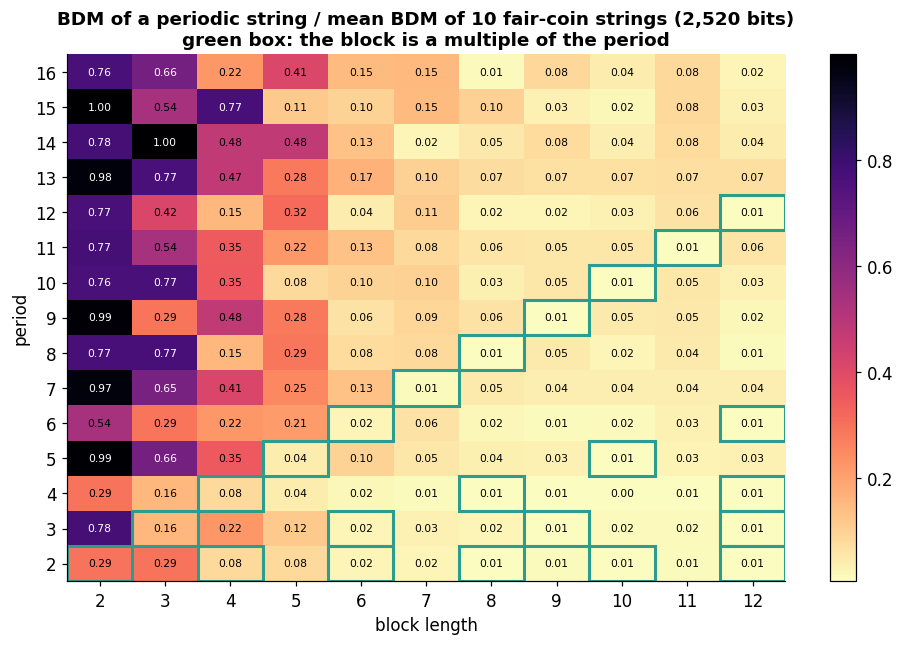

ratio when the block is a multiple of the period: median 0.007 (23 cells)
ratio otherwise (blocks 4-12): median 0.059, max 0.773 (114 cells)


distinct blocks <= p / gcd(p, b) in 150 of 150 (period, block) cells


In [27]:
G = R["DM"]["DM3"]
ps = sorted({g["period"] for g in G}); bs = sorted({g["block"] for g in G})
M = np.array([[next(g["ratio"] for g in G if g["period"] == p and g["block"] == b) for b in bs] for p in ps])
fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(M, cmap="magma_r", aspect="auto", origin="lower")
for i, p in enumerate(ps):
    for j, b in enumerate(bs):
        ax.text(j, i, f"{M[i, j]:.2f}", ha="center", va="center", fontsize=7, color="white" if M[i, j] > .55 else "black")
        if b % p == 0:
            ax.add_patch(plt.Rectangle((j - .5, i - .5), 1, 1, fill=False, ec=OK, lw=2))
ax.set(xticks=range(len(bs)), xticklabels=bs, yticks=range(len(ps)), yticklabels=ps, xlabel="block length",
       ylabel="period", title="BDM of a periodic string / mean BDM of 10 fair-coin strings (2,520 bits)\n"
                              "green box: the block is a multiple of the period")
ax.grid(False); plt.colorbar(im); plt.tight_layout(); plt.show()
multiple = [M[i, j] for i, p in enumerate(ps) for j, b in enumerate(bs) if b % p == 0]
other = [M[i, j] for i, p in enumerate(ps) for j, b in enumerate(bs) if b % p and b > 3]
print(f"ratio when the block is a multiple of the period: median {np.median(multiple):.3f} ({len(multiple)} cells)")
print(f"ratio otherwise (blocks 4-12): median {np.median(other):.3f}, max {max(other):.3f} ({len(other)} cells)")
# why: a period-p string cut into blocks of b has exactly p / gcd(p, b) distinct blocks
checked = 0
for p in ps:
    ru = P.rng("DM3unit", p); unit = "".join(ru.choice("01") for _ in range(p))
    s = (unit * (2520 // p + 1))[:2520]
    for b in bs:
        if 2520 % b == 0:
            assert block_code_parts(s, block=b)["distinct"] <= p // math.gcd(p, b)
            checked += 1
print(f"distinct blocks <= p / gcd(p, b) in {checked} of {checked} (period, block) cells")
assert checked == 150 and round(np.median(multiple), 3) == 0.007 and round(np.median(other), 3) == 0.059

### Anatomy of one DM3 cell: period 7, block 8

Each number in the heat map is one periodic string's BDM divided by the mean BDM of 10 random
strings of the same length (2,520 bits), read with the same block. Here is the cell for
period 7 and block 8, built live and checked against the saved value.

unit: 0001100 (7 bits), repeated to 2,520 bits; cut into 315 blocks of 8
different blocks: 7 = 7 / gcd(7, 8) = 7 (the block start cycles through all 7 phases of the period)
   00011000  x 45   CTM 21.303 + log2 45 = 26.794
   00110000  x 45   CTM 21.124 + log2 45 = 26.616
   01100000  x 45   CTM 20.910 + log2 45 = 26.402
   11000001  x 45   CTM 22.164 + log2 45 = 27.656
   10000011  x 45   CTM 22.164 + log2 45 = 27.656
   00000110  x 45   CTM 20.910 + log2 45 = 26.402
   00001100  x 45   CTM 21.124 + log2 45 = 26.616
BDM of the periodic string = 188.14
BDM of 10 random strings of 2,520 bits: 4010, 4003, 4042, 4020, 3894, 4057, 4101, 4006, 3909, 4028; mean 4007.0
ratio = 188.14 / 4007.0 = 0.047


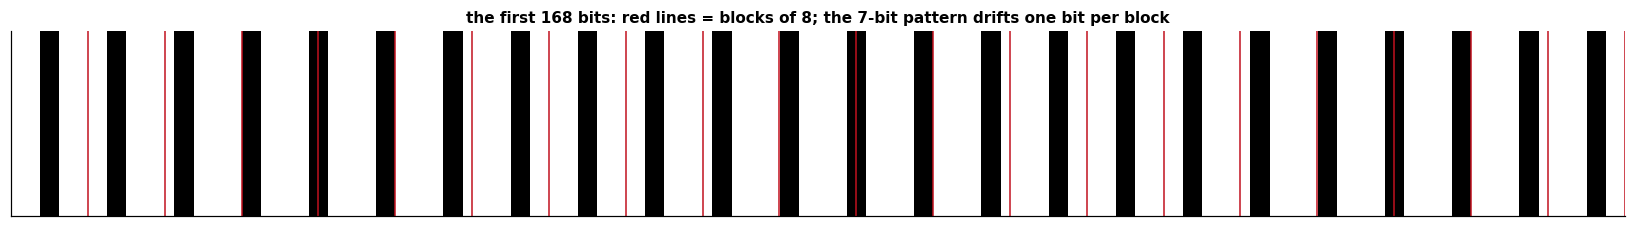

In [28]:
dm3_ru = P.rng("DM3unit", 7); dm3_unit = "".join(dm3_ru.choice("01") for _ in range(7))
dm3_s = (dm3_unit * (2520 // 7 + 1))[:2520]
dm3_blocks = wrap(dm3_s, 8); dm3_cnt = collections.Counter(dm3_blocks)
print(f"unit: {dm3_unit} (7 bits), repeated to 2,520 bits; cut into {len(dm3_blocks)} blocks of 8")
print(f"different blocks: {len(dm3_cnt)} = 7 / gcd(7, 8) = 7 (the block start cycles through all 7 phases of the period)")
for w, n in dm3_cnt.items():
    print(f"   {w}  x{n:>3}   CTM {ctm_1d(w):.3f} + log2 {n} = {ctm_1d(w) + math.log2(n):.3f}")
dm3_v = bdm_1d(dm3_s, block=8, remainder="recursive")
dm3_ctrl = [bdm_1d((lambda rc: "".join(rc.choice("01") for _ in range(2520)))(P.rng("DM3ctl", 8, j)),
                   block=8, remainder="recursive") for j in range(10)]
print(f"BDM of the periodic string = {dm3_v:.2f}")
print(f"BDM of 10 random strings of 2,520 bits: {', '.join(f'{c:.0f}' for c in dm3_ctrl)}; mean {np.mean(dm3_ctrl):.1f}")
print(f"ratio = {dm3_v:.2f} / {np.mean(dm3_ctrl):.1f} = {dm3_v / np.mean(dm3_ctrl):.3f}")
saved_ = next(g for g in R["DM"]["DM3"] if g["period"] == 7 and g["block"] == 8)
assert abs(dm3_v / np.mean(dm3_ctrl) - saved_["ratio"]) < 1e-12
fig, ax = plt.subplots(figsize=(15, 2.2))
show_bits(ax, [dm3_s[:168]], "the first 168 bits: red lines = blocks of 8; the 7-bit pattern drifts one bit per block")
for i in range(0, 169, 8):
    ax.axvline(i - .5, color=HL, lw=1)
plt.tight_layout(); plt.show()

**Reading (DM3).** This corrects what bitacora 43 and the first draft of this notebook
said. On 2,520 bits, a periodic string stays cheap **whether or not** the block is a multiple
of the period: the median ratio to random is 0.007 in the multiple cells, against 0.059
elsewhere. The reason is counting. A string of period p, cut into blocks of b, has at most
p/gcd(p, b) distinct blocks, checked in every cell above. Each of them repeats many times,
and BDM charges a repeat only a logarithm. The partition shows a periodic string as random
only when lcm(p, b) is comparable to the whole length, so that nothing repeats. That is the
period-9, 72-bit case of notebook 15: lcm(9, 8) = 72 is the entire string. High ratios at
blocks 2 to 5 have a different cause: there the random *control* is itself saturated (§3), so
the ratio approaches 1 because the reference is cheap, not because the periodic string is
expensive. **What fools BDM is the ratio of the string's length to lcm(p, b), not the grid
alone.**

## 5 · When can BDM see a disruption point? (H2)

The test, as pre-registered: a string whose left half is periodic and whose right half is
random. Flip bits one at a time and record how much BDM changes. If the change is
systematically different between the two halves, the seam is visible. 49 cells: 7 lengths
(64 to 4,096 bits) × 7 block lengths (2 to 12), with 5 seam strings and 50 seamless random
strings per cell as the reference.

**The hypothesis (from bitacora 43):** the *fill ratio*, the number of blocks per half divided
by the 2^b possible words, decides visibility. With few blocks per possible word, repeats
happen only because of structure.

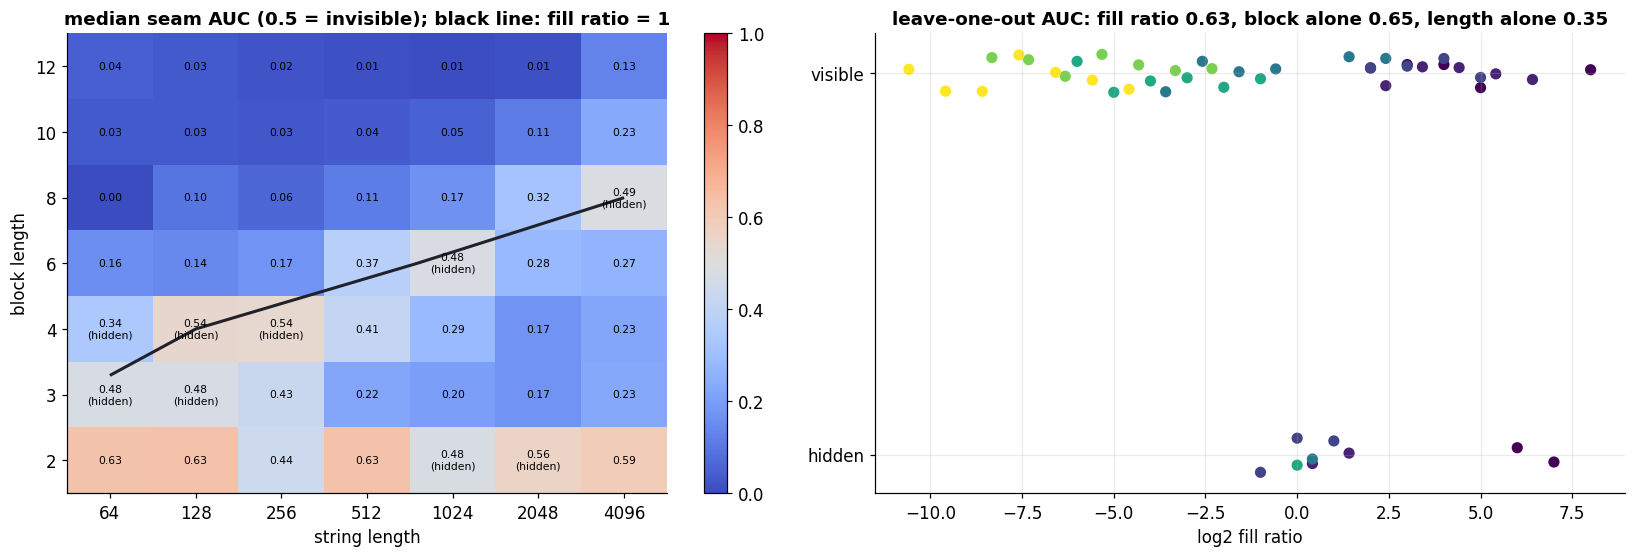

visible in 40 of 49 cells; hidden cells (length, block): [(64, 3), (64, 4), (128, 3), (128, 4), (256, 4), (1024, 2), (1024, 6), (2048, 2), (4096, 8)]
verdict: not_supported


In [29]:
cells = H2["cells"]
Ls = sorted({c["n"] for c in cells}); Bs = sorted({c["block"] for c in cells})
A = np.array([[next(c["seam_median"] for c in cells if c["n"] == n and c["block"] == b) for n in Ls] for b in Bs])
V = np.array([[next(c["visible"] for c in cells if c["n"] == n and c["block"] == b) for n in Ls] for b in Bs])
F = np.array([[np.log2(next(c["fill_ratio"] for c in cells if c["n"] == n and c["block"] == b)) for n in Ls] for b in Bs])
fig, ax = plt.subplots(1, 2, figsize=(15, 5.2))
im = ax[0].imshow(A, cmap="coolwarm", vmin=0, vmax=1, origin="lower", aspect="auto")
for i in range(len(Bs)):
    for j in range(len(Ls)):
        ax[0].text(j, i, f"{A[i, j]:.2f}" + ("" if V[i, j] else "\n(hidden)"), ha="center", va="center", fontsize=7)
ax[0].contour(F, levels=[0], colors=[INK], linewidths=2)
ax[0].set(xticks=range(len(Ls)), xticklabels=Ls, yticks=range(len(Bs)), yticklabels=Bs, xlabel="string length",
          ylabel="block length", title="median seam AUC (0.5 = invisible); black line: fill ratio = 1")
ax[0].grid(False); plt.colorbar(im, ax=ax[0])
fv = [np.log2(c["fill_ratio"]) for c in cells]; vis = [c["visible"] for c in cells]
jit = np.random.default_rng(0).uniform(-.05, .05, len(vis))
ax[1].scatter(fv, np.array(vis, float) + jit, c=[c["block"] for c in cells], cmap="viridis", s=40)
ax[1].set(xlabel="log2 fill ratio", yticks=[0, 1], yticklabels=["hidden", "visible"],
          title=f"leave-one-out AUC: fill ratio {H2['loo_auc_fill']:.2f}, block alone {H2['loo_auc_block']:.2f}, length alone {H2['loo_auc_length']:.2f}")
plt.tight_layout(); plt.show()
hidden = [(c["n"], c["block"]) for c in cells if not c["visible"]]
print(f"visible in {H2['n_visible']} of {H2['n_cells']} cells; hidden cells (length, block): {hidden}")
print("verdict:", H2["verdict"])
assert H2["n_visible"] == 40 and H2["verdict"] == "not_supported"
live = P._h2_job((64, 2, "seam", 0, 128))
saved_aucs = next(c for c in cells if c["n"] == 64 and c["block"] == 2)["seam_aucs"]
assert abs(live["auc"] - saved_aucs[0]) < 1e-12, "H2 live re-computation differs"

### Anatomy of H2: where one AUC, one "visible" and the 0.63 come from

**The claim.** The fill ratio predicts which cells show the seam. **What would have made it
true:** a leave-one-out AUC of at least 0.90. It came out at 0.63.

**Step 1: one seam string.** Cell length 256, block 8, seam string number 0, rebuilt exactly as
the producer builds it. The left half repeats a short random unit (period 2, 3 or 5), and the
right half is a fair coin.

period of the left half: 3, unit '001'; BDM of the whole string (block 8) = 393.56

Step 2, one flip: bit 5 (left half) is flipped, 1 -> 0; BDM after = 413.73; I = 393.56 - 413.73 = -20.17
   (in a periodic region one flip breaks a word that occurred many times and creates a new one, so BDM jumps)


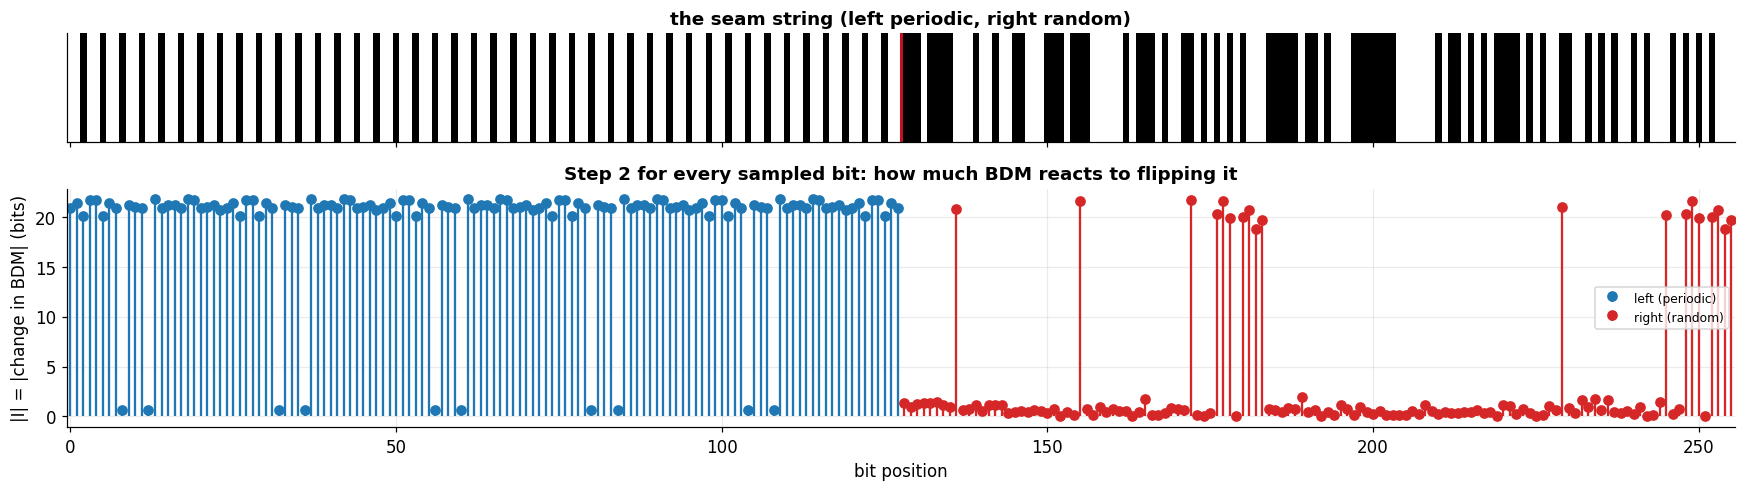

Step 3, AUC = share of (left, right) pairs in which the right bit reacts more (ties count 1/2):
   1085.0 of 128 x 128 = 16,384 pairs -> AUC = 0.0662   (0.5 = no difference; near 0 = the periodic half reacts more)


In [30]:
h2_n, h2_b, h2_k = 256, 8, 0
r_ = P.rng("H2", "seam", h2_n, h2_b, h2_k); half = h2_n // 2
p_ = r_.choice([2, 3, 5]); unit_ = "".join(r_.choice("01") for _ in range(p_))
h2_s = (unit_ * (half // p_ + 1))[:half] + "".join(r_.choice("01") for _ in range(h2_n - half))
pr_ = P.rng("H2pos", "seam", h2_n, h2_b, h2_k)
h2_left = sorted(pr_.sample(range(half), min(128, half))); h2_right = sorted(pr_.sample(range(half, h2_n), min(128, h2_n - half)))
kw_ = dict(block=h2_b, remainder="recursive")
h2_base = bdm_1d(h2_s, **kw_)
h2_I = {i: h2_base - bdm_1d(P.flip(h2_s, i), **kw_) for i in h2_left + h2_right}
print(f"period of the left half: {p_}, unit {unit_!r}; BDM of the whole string (block 8) = {h2_base:.2f}")
ex_ = h2_left[5]
print(f"\nStep 2, one flip: bit {ex_} (left half) is flipped, {h2_s[ex_]} -> {'1' if h2_s[ex_] == '0' else '0'};"
      f" BDM after = {bdm_1d(P.flip(h2_s, ex_), **kw_):.2f}; I = {h2_base:.2f} - {bdm_1d(P.flip(h2_s, ex_), **kw_):.2f} = {h2_I[ex_]:.2f}")
print("   (in a periodic region one flip breaks a word that occurred many times and creates a new one, so BDM jumps)")
fig, ax = plt.subplots(2, 1, figsize=(16, 4.6), gridspec_kw={"height_ratios": [1, 2.2]}, sharex=True)
ax[0].imshow([[int(c) for c in h2_s]], cmap="gray_r", aspect="auto"); ax[0].set(yticks=[], title="the seam string (left periodic, right random)")
ax[0].axvline(half - .5, color=HL, lw=2); ax[0].grid(False)
ax[1].stem(h2_left, [abs(h2_I[i]) for i in h2_left], linefmt="C0-", markerfmt="C0o", basefmt=" ", label="left (periodic)")
ax[1].stem(h2_right, [abs(h2_I[i]) for i in h2_right], linefmt="C3-", markerfmt="C3o", basefmt=" ", label="right (random)")
ax[1].set(xlabel="bit position", ylabel="|I| = |change in BDM| (bits)", title="Step 2 for every sampled bit: how much BDM reacts to flipping it")
ax[1].legend(fontsize=8); plt.tight_layout(); plt.show()
L_ = [abs(h2_I[i]) for i in h2_left]; Rr_ = [abs(h2_I[i]) for i in h2_right]
pairs_ = sum((r > l) + .5 * (r == l) for l in L_ for r in Rr_)
h2_auc = pairs_ / (len(L_) * len(Rr_))
print(f"Step 3, AUC = share of (left, right) pairs in which the right bit reacts more (ties count 1/2):")
print(f"   {pairs_:.1f} of {len(L_)} x {len(Rr_)} = {len(L_) * len(Rr_):,} pairs -> AUC = {h2_auc:.4f}"
      "   (0.5 = no difference; near 0 = the periodic half reacts more)")
cell_ = next(c for c in H2["cells"] if c["n"] == h2_n and c["block"] == h2_b)
assert abs(h2_auc - cell_["seam_aucs"][0]) < 1e-12

**Step 4: the cell's verdict.** The same is done for the cell's 5 seam strings, and for 50
**random strings with no seam** (the reference: what AUC looks like when there is nothing to
find). The cell is **visible** if the median of the 5 seam AUCs lies outside the 5–95 % range
of the 50 reference AUCs.

**Step 5: the test of the hypothesis.** Each of the 49 cells becomes one point: its fill ratio
(blocks per half ÷ possible words) and its verdict (visible or hidden). A logistic curve is
fitted to predict the verdict from log2 of the fill ratio. To avoid grading the curve on the
points it was fitted to, each cell is predicted by a curve fitted to the other 48: the
leave-one-out step. The 49 predictions are then scored by AUC against the true verdicts. A
score of 1.0 would mean the fill ratio sorts visible from hidden perfectly; 0.5 would mean it
is no better than a coin.

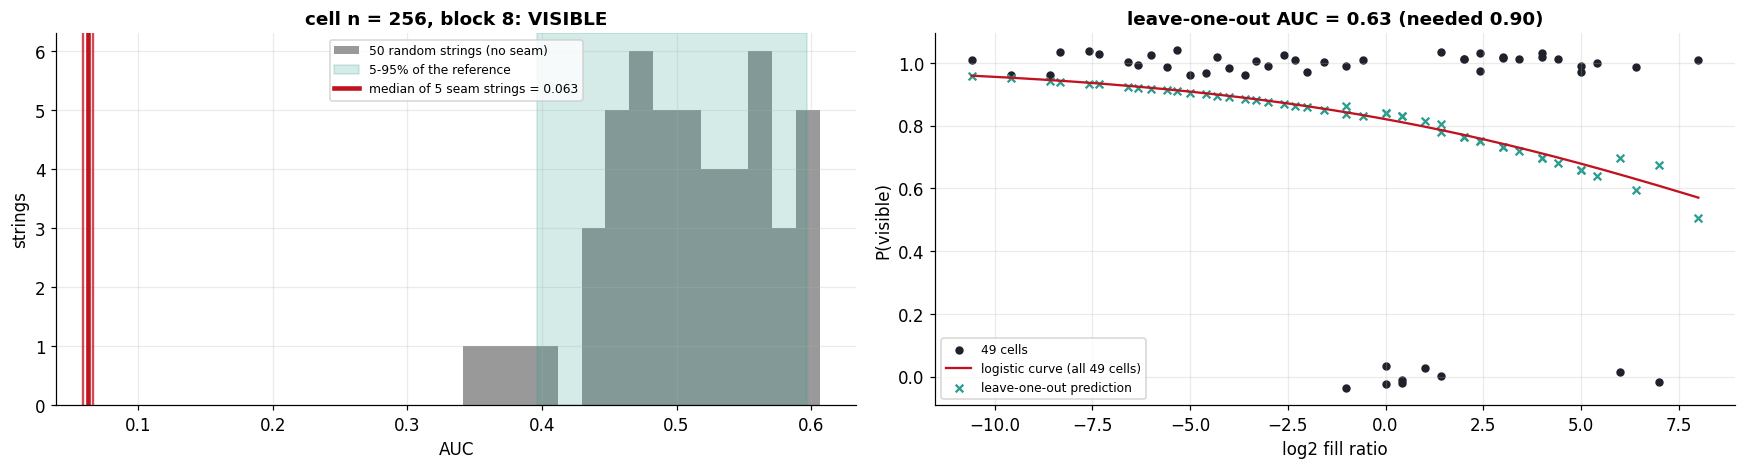

fill ratio of this cell = (128 / 8) / 2^8 = 0.0625; log2 = -4.0
visible cells 40 of 49; the curve is almost flat because hidden cells sit at many fill ratios


In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
fig, ax = plt.subplots(1, 2, figsize=(16, 4.4))
ax[0].hist(cell_["null_aucs"], bins=15, color="0.6", label="50 random strings (no seam)")
ax[0].axvspan(cell_["null_p5"], cell_["null_p95"], color=OK, alpha=.2, label="5-95% of the reference")
for a_ in cell_["seam_aucs"]:
    ax[0].axvline(a_, color=HL, alpha=.5)
ax[0].axvline(cell_["seam_median"], color=HL, lw=3, label=f"median of 5 seam strings = {cell_['seam_median']:.3f}")
ax[0].set(xlabel="AUC", ylabel="strings", title=f"cell n = {h2_n}, block {h2_b}: "
          + ("VISIBLE" if cell_["visible"] else "hidden")); ax[0].legend(fontsize=8)
X_ = np.log2([[c["fill_ratio"]] for c in H2["cells"]]); y_ = np.array([c["visible"] for c in H2["cells"]], int)
pred_ = []
for i in range(len(y_)):
    m_ = np.arange(len(y_)) != i
    pred_.append(LogisticRegression(C=1000, solver="lbfgs").fit(X_[m_], y_[m_]).predict_proba(X_[i:i + 1])[0, 1])
loo_ = roc_auc_score(y_, pred_)
full_ = LogisticRegression(C=1000, solver="lbfgs").fit(X_, y_)
xs_ = np.linspace(X_.min(), X_.max(), 200)[:, None]
ax[1].scatter(X_[:, 0], y_ + np.random.default_rng(0).uniform(-.04, .04, len(y_)), color=INK, s=20, label="49 cells")
ax[1].plot(xs_[:, 0], full_.predict_proba(xs_)[:, 1], color=HL, label="logistic curve (all 49 cells)")
ax[1].scatter(X_[:, 0], pred_, color=OK, marker="x", s=25, label="leave-one-out prediction")
ax[1].set(xlabel="log2 fill ratio", ylabel="P(visible)", title=f"leave-one-out AUC = {loo_:.2f} (needed 0.90)")
ax[1].legend(fontsize=8); plt.tight_layout(); plt.show()
print(f"fill ratio of this cell = (128 / 8) / 2^8 = {cell_['fill_ratio']:.4f}; log2 = {math.log2(cell_['fill_ratio']):.1f}")
print(f"visible cells {int(y_.sum())} of {len(y_)}; the curve is almost flat because hidden cells sit at many fill ratios")
assert abs(loo_ - H2["loo_auc_fill"]) < 1e-9

**Reading.** **H2 is not supported.** The seam is visible in 40 of 49 cells, including cells
where the dictionary is completely full (log2 fill ratio up to 8). The fill ratio predicts
which cells are hidden no better than the block length alone (leave-one-out AUC 0.63 against
0.65; the protocol required 0.90). The hidden cells cluster at blocks 3 and 4 and are
scattered elsewhere. The "fill ratio law" of bitacora 43 was drawn from one string at one
length, and it is **withdrawn**.

What does hold: with this design, BDM detects a periodic-versus-random seam at most settings.
Even block 2 sees it at most lengths, because the periodic half produces a run of identical
pairs. What decides the hidden cells is not established here, and this notebook does not
guess.

## 6 · Perturbations and the position of the block grid (H3, H4)

The causal calculus built on BDM reads the effect of flipping one element: the change in BDM
says whether the element is "information-adding" or "information-removing". BDM in 2-D cuts a
diagram into 4×4 blocks. **Rolling a periodic cellular automaton sideways by one, two or three
columns is an exact symmetry**: the same system, with every cell relabelled. Only the position
of the block grid changes. If a cell's effect is a property of the system, it must not change.

Protocol: all 256 rules × 5 seeds; 64 × 64 diagrams; 100 cells per diagram; four grid
positions. Below, rule 30, seed 0, is re-computed live and compared with the saved record.

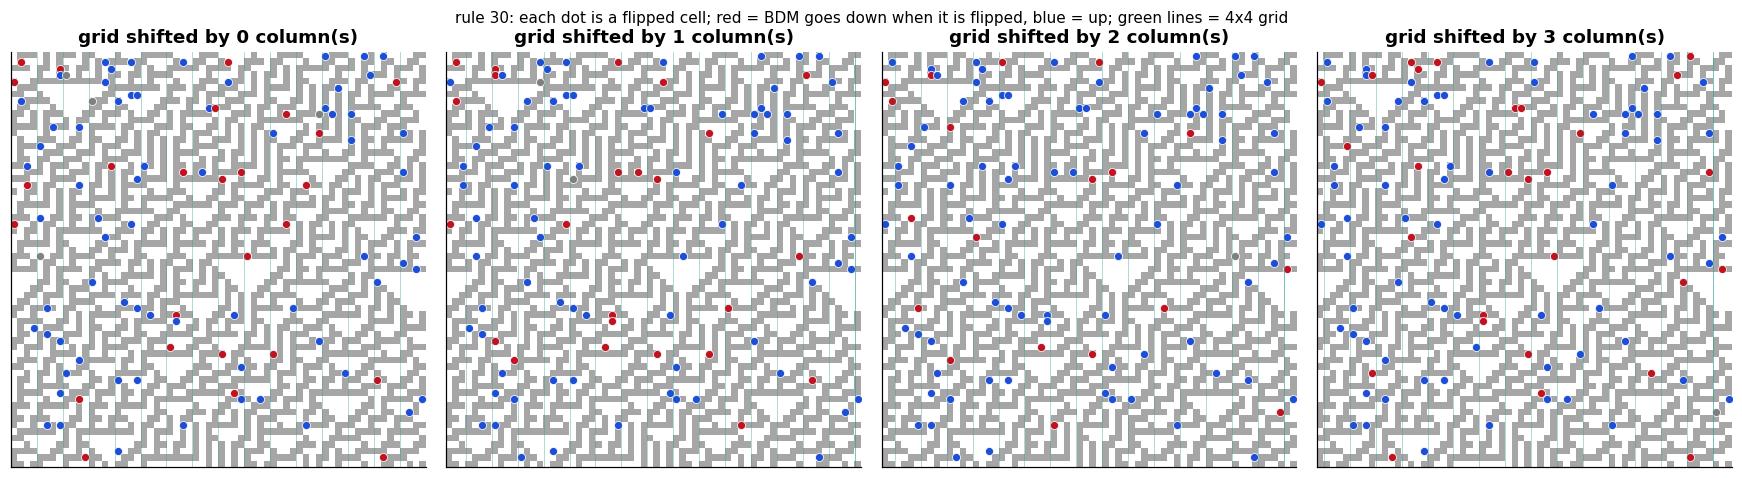

rule 30, seed 0: the sign changes with the grid for 62% of 100 cells


In [32]:
live = P._h3_job((30, 0, 64, 64, 100))
saved = next(o for o in H34["raw"] if o["rule"] == 30 and o["seed"] == 0)
assert live["delta"] == saved["delta"], "H3 live re-computation differs"
r = P.rng("H3", 30, 0)
Adiag = np.array(evolve_eca(30, [r.randrange(2) for _ in range(64)], 64))
cells30 = [(r.randrange(64), r.randrange(64)) for _ in range(100)]
D = np.array(saved["delta"])
fig, ax = plt.subplots(1, 4, figsize=(16, 4.4))
for p in range(4):
    ax[p].imshow(1 - Adiag, cmap="gray", alpha=.35, interpolation="nearest")
    sg = np.vectorize(P.sgn)(D[:, p])
    for (t, c), s_ in zip(cells30, sg):
        ax[p].scatter(c, t, s=28, color={1: HL, -1: "#1d4ed8", 0: "0.5"}[s_], edgecolors="white", linewidths=.5)
    for g in range(0, 65, 4):
        ax[p].axvline((g - p) % 64 - .5, color=OK, lw=.4, alpha=.6)
    ax[p].set(title=f"grid shifted by {p} column(s)", xticks=[], yticks=[]); ax[p].grid(False)
fig.suptitle("rule 30: each dot is a flipped cell; red = BDM goes down when it is flipped, blue = up; green lines = 4x4 grid", fontsize=10)
plt.tight_layout(); plt.show()
changed = np.mean([len(set(np.vectorize(P.sgn)(row))) > 1 for row in D])
print(f"rule 30, seed 0: the sign changes with the grid for {changed:.0%} of 100 cells")

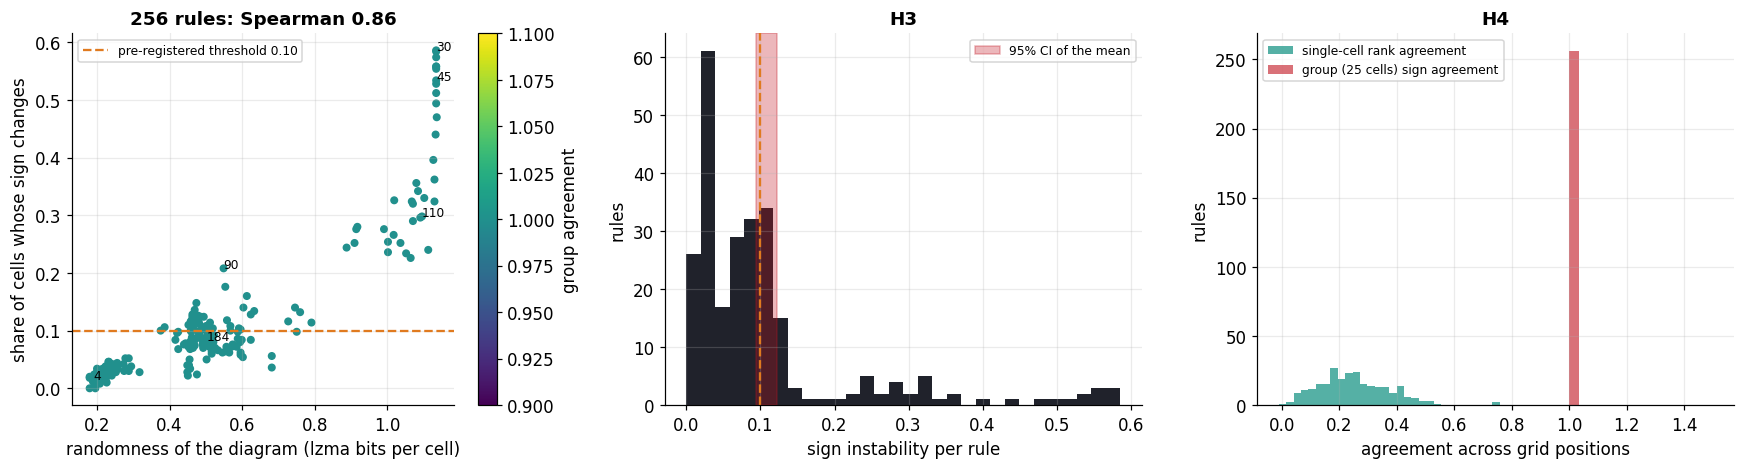

H3: mean instability 0.107, 95% CI 0.093-0.122; rules above 0.10: 80 of 256; Spearman with randomness 0.86 (CI 0.81-0.90)
H4: median group agreement 1.00; median single-cell rank agreement 0.24
most unstable rules: [(30, 0.59), (75, 0.58), (101, 0.57), (89, 0.56), (149, 0.56), (86, 0.55)]


In [33]:
pr = H34["per_rule"]
inst = np.array([x["sign_instability"] for x in pr]); prox = np.array([x["lzma_per_bit"] for x in pr])
grp = np.array([x["group_agreement"] for x in pr]); rank = np.array([x["rank_agreement"] for x in pr], float)
fig, ax = plt.subplots(1, 3, figsize=(16, 4.4))
sc = ax[0].scatter(prox, inst, c=grp, cmap="viridis", s=18)
for x in pr:
    if x["rule"] in (4, 30, 45, 90, 110, 184):
        ax[0].annotate(str(x["rule"]), (x["lzma_per_bit"], x["sign_instability"]), fontsize=8)
ax[0].axhline(.10, color=BAD, ls="--", label="pre-registered threshold 0.10")
ax[0].set(xlabel="randomness of the diagram (lzma bits per cell)", ylabel="share of cells whose sign changes",
          title=f"256 rules: Spearman {H34['H3']['spearman_instability_vs_lzma']:.2f}"); ax[0].legend(fontsize=8)
plt.colorbar(sc, ax=ax[0], label="group agreement")
ax[1].hist(inst, bins=30, color=INK); ax[1].axvline(.10, color=BAD, ls="--")
ax[1].axvspan(*H34["H3"]["ci95"], color=HL, alpha=.3, label="95% CI of the mean")
ax[1].set(xlabel="sign instability per rule", ylabel="rules", title="H3"); ax[1].legend(fontsize=8)
ax[2].hist(rank, bins=30, color=OK, alpha=.8, label="single-cell rank agreement")
ax[2].hist(grp, bins=30, color=HL, alpha=.6, label="group (25 cells) sign agreement")
ax[2].set(xlabel="agreement across grid positions", ylabel="rules", title="H4"); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()
h3, h4 = H34["H3"], H34["H4"]
print(f"H3: mean instability {h3['mean_instability']:.3f}, 95% CI {h3['ci95'][0]:.3f}-{h3['ci95'][1]:.3f}; "
      f"rules above 0.10: {int((inst > .10).sum())} of {len(inst)}; Spearman with randomness {h3['spearman_instability_vs_lzma']:.2f} "
      f"(CI {h3['spearman_ci95'][0]:.2f}-{h3['spearman_ci95'][1]:.2f})")
print(f"H4: median group agreement {h4['median_group_agreement']:.2f}; median single-cell rank agreement {h4['median_rank_agreement']:.2f}")
top = sorted(pr, key=lambda x: -x["sign_instability"])[:6]
print("most unstable rules:", [(x["rule"], round(x["sign_instability"], 2)) for x in top])
assert int((inst > .10).sum()) == 80 and round(h3["mean_instability"], 3) == 0.107

### Anatomy of H3 and H4: one cell, one diagram, one rule, then all 256

**The claim (H3).** Moving the 4×4 grid, which changes nothing in the system, changes the sign
of a single cell's BDM effect often enough that the average over rules exceeds 0.10.
**What would have made it true:** a 95 % interval for that average lying entirely above 0.10.

**Step 1: one cell, four grid positions.** Rule 30, seed 0, the first of its 100 sampled cells
whose sign changes with the grid.
In each grid position the cell sits in a different 4×4 block, with different neighbours. Flipping
the cell turns that block into another block. BDM then changes by exactly this:
(the old block loses one occurrence) and (the new block gains one). Each of those is either a
full CTM value, if the block appears or disappears, or a change in log2 of its count.

cell number 1 of 100 (the first whose sign changes): row 2, column 7; its value is 1
grid shifted 0: block rows 0-3, cols 4-7 of the shifted diagram
   old block 0101010111011001 (occurs 1x, CTM 30.862) -> new block 0101010111001001 (occurred 0x, CTM 29.907)
   change = -30.862 (old) +29.907 (new);  Delta = BDM before - BDM after = +0.955  -> sign +1
grid shifted 1: block rows 0-3, cols 8-11 of the shifted diagram
   old block 1110100011011001 (occurs 1x, CTM 28.272) -> new block 1110100001011001 (occurred 0x, CTM 26.823)
   change = -28.272 (old) +26.823 (new);  Delta = BDM before - BDM after = +1.449  -> sign +1
grid shifted 2: block rows 0-3, cols 8-11 of the shifted diagram
   old block 0111010001100100 (occurs 1x, CTM 30.108) -> new block 0111010000100100 (occurred 0x, CTM 30.707)
   change = -30.108 (old) +30.707 (new);  Delta = BDM before - BDM after = -0.599  -> sign -1
grid shifted 3: block rows 0-3, cols 8-11 of the shifted diagram
   old block 1011101010110010 (occurs 1x, CT

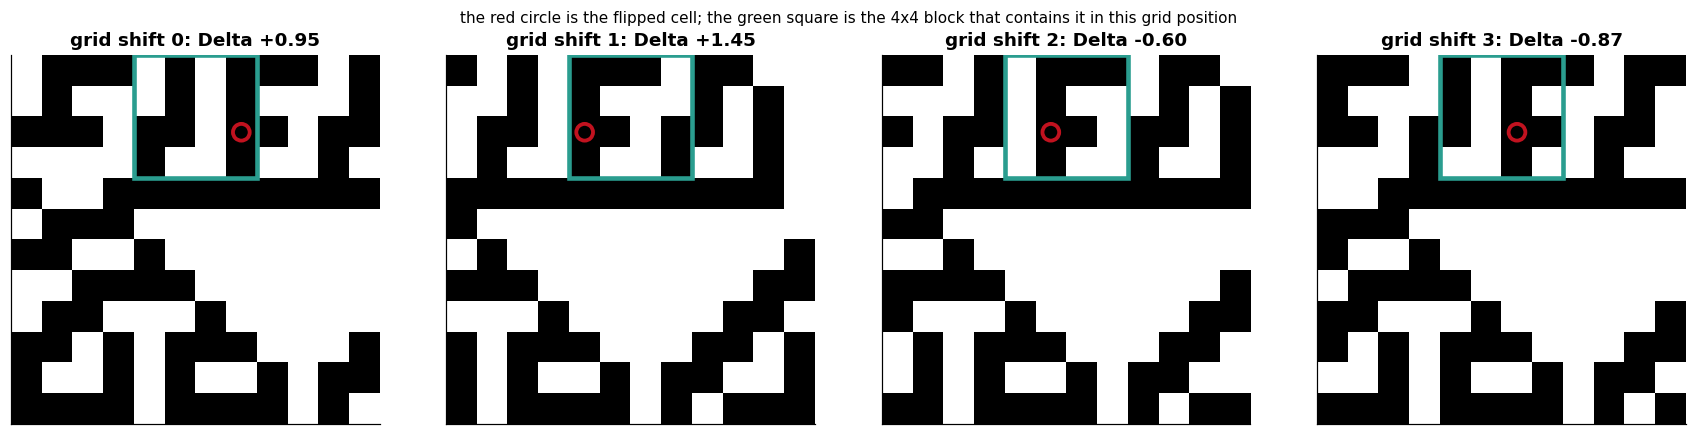

In [34]:
h3_r = P.rng("H3", 30, 0)
h3_A = np.array(evolve_eca(30, [h3_r.randrange(2) for _ in range(64)], 64))
h3_cells = [(h3_r.randrange(64), h3_r.randrange(64)) for _ in range(100)]
h3_D = np.array(next(o for o in H34["raw"] if o["rule"] == 30 and o["seed"] == 0)["delta"])
h3_q = next(q for q in range(100) if len({P.sgn(v) for v in h3_D[q]}) > 1)   # the first cell whose sign changes
t_, c_ = h3_cells[h3_q]
print(f"cell number {h3_q} of 100 (the first whose sign changes): row {t_}, column {c_}; its value is {h3_A[t_, c_]}")
def h3_blocks(M):
    return collections.Counter("".join(map(str, M[i:i + 4, j:j + 4].flat)) for i in range(0, 64, 4) for j in range(0, 64, 4))
fig, ax = plt.subplots(1, 4, figsize=(16, 4))
for dc in range(4):
    S_ = np.roll(h3_A, dc, axis=1); cc = (c_ + dc) % 64
    br, bc = (t_ // 4) * 4, (cc // 4) * 4
    old = "".join(map(str, S_[br:br + 4, bc:bc + 4].flat))
    T_ = S_.copy(); T_[t_, cc] ^= 1
    new = "".join(map(str, T_[br:br + 4, bc:bc + 4].flat))
    cnt = h3_blocks(S_)
    c_old, c_new = T2D[(4, 4)][normalize_key(old)], T2D[(4, 4)][normalize_key(new)]
    n_old, n_new = cnt[old], cnt[new]
    loss = -c_old if n_old == 1 else math.log2(n_old - 1) - math.log2(n_old)       # old block loses one copy
    gain = c_new if n_new == 0 else math.log2(n_new + 1) - math.log2(n_new)          # new block gains one copy
    delta = -(loss + gain)                                                           # Delta = BDM(before) - BDM(after)
    assert abs(delta - h3_D[h3_q, dc]) < 1e-9
    print(f"grid shifted {dc}: block rows {br}-{br + 3}, cols {bc}-{bc + 3} of the shifted diagram")
    print(f"   old block {old} (occurs {n_old}x, CTM {c_old:.3f}) -> new block {new} (occurred {n_new}x, CTM {c_new:.3f})")
    print(f"   change = {loss:+.3f} (old) {gain:+.3f} (new);  Delta = BDM before - BDM after = {delta:+.3f}  -> sign {P.sgn(delta):+d}")
    lo_r, lo_c = max(0, br - 4), max(0, bc - 4)
    view = S_[lo_r:lo_r + 12, lo_c:lo_c + 12]
    ax[dc].imshow(1 - view, cmap="gray", interpolation="nearest")
    ax[dc].add_patch(plt.Rectangle((bc - lo_c - .5, br - lo_r - .5), 4, 4, fill=False, ec=OK, lw=3))
    ax[dc].scatter([cc - lo_c], [t_ - lo_r], s=120, facecolors="none", edgecolors=HL, lw=2.5)
    ax[dc].set(title=f"grid shift {dc}: Delta {delta:+.2f}", xticks=[], yticks=[]); ax[dc].grid(False)
fig.suptitle("the red circle is the flipped cell; the green square is the 4x4 block that contains it in this grid position", fontsize=10)
plt.tight_layout(); plt.show()

**What decides the sign, read from the formula Δ = −(old-block term + new-block term).**

* If the cell's block is **repeated** (it occurs more than once), removing one copy saves only
  log2 of a count, a fraction of a bit, while the new block costs a full CTM. Δ is then
  large and negative, and its sign is fixed.
* If the cell's block is **unique**, the flip swaps one whole CTM value for another. Δ is
  the small difference CTM(old) − CTM(new), and its sign depends on which of the two blocks
  the table rates higher.

Moving the grid changes the cell's block in both ways. It can make the block unique or
repeated, and even when the block stays unique, the pair (old block, new block) is a
different pair of strings. The cell above is of the second kind: its block is unique in all
four positions, but the CTM difference is +0.96, +1.45, −0.60 and −0.87. So the sign belongs
to the pair of blocks the grid happens to cut, not to the cell.

**Step 2: from one cell to one diagram.** The same is done for all 100 cells. A cell is
**unstable** if its sign is not the same in all four grid positions. The diagram's instability
is the share of unstable cells. **Step 3: from one diagram to one rule:** the mean over the
rule's 5 seeds. **Step 4: from 256 rules to the verdict:** the mean over rules, with a 95 %
interval obtained by resampling the 256 rules with replacement 1,000 times (the bootstrap).

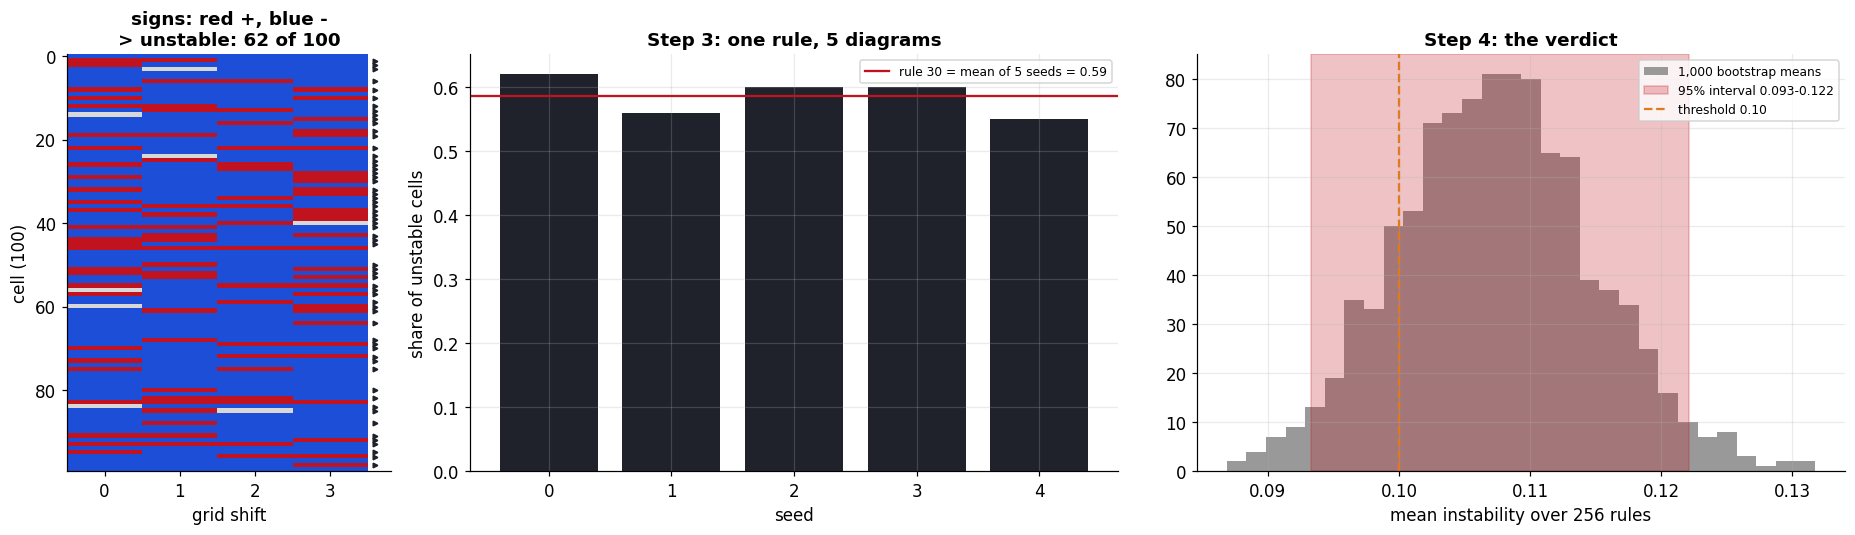

rule 30, seed 0: 62 of 100 cells unstable; rule 30 over 5 seeds: 0.62 0.56 0.60 0.60 0.55 -> mean 0.59
256 rules: mean 0.107; bootstrap 95% interval 0.093 to 0.122; lower end above 0.10? False


In [35]:
h3_S = np.vectorize(P.sgn)(h3_D)
h3_unstable = np.array([len(set(row)) > 1 for row in h3_S])
fig, ax = plt.subplots(1, 3, figsize=(17, 5), gridspec_kw={"width_ratios": [.5, 1, 1]})
ax[0].imshow(h3_S, cmap=matplotlib.colors.ListedColormap(["#1d4ed8", "0.85", HL]), vmin=-1, vmax=1, aspect="auto",
             interpolation="nearest")
for i in np.where(h3_unstable)[0]:
    ax[0].plot([3.6], [i], ">", color=INK, ms=3)
ax[0].set(xticks=range(4), xlabel="grid shift", ylabel="cell (100)",
          title=f"signs: red +, blue -\n> unstable: {h3_unstable.sum()} of 100"); ax[0].grid(False)
h3_inst = np.array([x["sign_instability"] for x in H34["per_rule"]])
h3_boot = []        # the producer's own bootstrap, with its resampled means captured for the histogram
lo_, hi_ = P.boot_ci(lambda idx: h3_boot.append(float(h3_inst[idx].mean())) or h3_boot[-1], 256, 1000, ("H3",))
assert [lo_, hi_] == H34["H3"]["ci95"] and len(h3_boot) == 1000
r30 = [np.mean([len(set(np.vectorize(P.sgn)(np.array(o["delta"])[q]))) > 1 for q in range(100)])
       for o in H34["raw"] if o["rule"] == 30]
ax[1].bar(range(5), r30, color=INK); ax[1].axhline(np.mean(r30), color=HL, label=f"rule 30 = mean of 5 seeds = {np.mean(r30):.2f}")
ax[1].set(xlabel="seed", ylabel="share of unstable cells", title="Step 3: one rule, 5 diagrams"); ax[1].legend(fontsize=8)
ax[2].hist(h3_boot, bins=30, color="0.6", label="1,000 bootstrap means")
ax[2].axvspan(lo_, hi_, color=HL, alpha=.25, label=f"95% interval {lo_:.3f}-{hi_:.3f}")
ax[2].axvline(.10, color=BAD, ls="--", label="threshold 0.10")
ax[2].set(xlabel="mean instability over 256 rules", title="Step 4: the verdict"); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()
print(f"rule 30, seed 0: {h3_unstable.sum()} of 100 cells unstable; rule 30 over 5 seeds: "
      f"{' '.join(f'{v:.2f}' for v in r30)} -> mean {np.mean(r30):.2f}")
print(f"256 rules: mean {h3_inst.mean():.3f}; bootstrap 95% interval {lo_:.3f} to {hi_:.3f}; lower end above 0.10? {lo_ > .10}")

**H4, the same data read two other ways.** The **group** reading takes the 100 cells in their
sampling order as 4 groups of 25, averages each group's effect, and asks whether the group's
sign is the same in all four grid positions. The **single-cell rank** reading asks whether the
cells keep their *order of effect* when the grid moves: the Spearman correlation between the 100
effects in position 0 and in position *k*.

rule 30, seed 0 - mean effect of each group of 25 cells (bits), in each grid position:
   group 1:   -8.67   -17.37   -22.68   -18.69   signs all the same
   group 2:  -11.65   -17.56   -15.27   -11.91   signs all the same
   group 3:  -13.78   -20.52   -16.88   -14.10   signs all the same
   group 4:  -15.34   -18.84   -20.11   -19.14   signs all the same


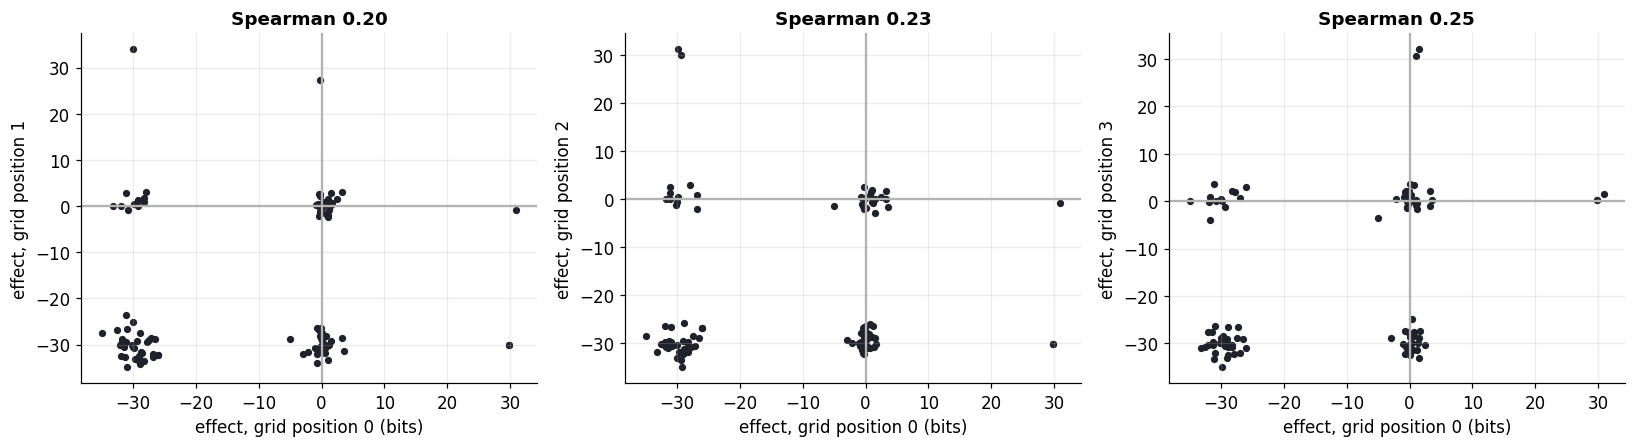

single-cell rank agreement for this diagram = median of 0.20, 0.23, 0.25 = 0.23
per rule: the mean over 5 seeds; H4 uses the median over 256 rules of each reading


In [36]:
from scipy.stats import spearmanr as _sp
groups_ = np.array_split(np.arange(100), 4)
gm_ = np.array([[h3_D[g, p].mean() for p in range(4)] for g in groups_])
print("rule 30, seed 0 - mean effect of each group of 25 cells (bits), in each grid position:")
for i, row in enumerate(gm_):
    print(f"   group {i + 1}: " + "  ".join(f"{v:+7.2f}" for v in row) +
          f"   signs {'all the same' if len({P.sgn(v) for v in row}) == 1 else 'differ'}")
rhos_ = [_sp(h3_D[:, 0], h3_D[:, p]).correlation for p in (1, 2, 3)]
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
for a_, p in zip(ax, (1, 2, 3)):
    a_.scatter(h3_D[:, 0], h3_D[:, p], s=14, color=INK); a_.axhline(0, color="0.7"); a_.axvline(0, color="0.7")
    a_.set(xlabel="effect, grid position 0 (bits)", ylabel=f"effect, grid position {p}",
           title=f"Spearman {rhos_[p - 1]:.2f}")
plt.tight_layout(); plt.show()
print(f"single-cell rank agreement for this diagram = median of {', '.join(f'{r:.2f}' for r in rhos_)} = {np.median(rhos_):.2f}")
print("per rule: the mean over 5 seeds; H4 uses the median over 256 rules of each reading")

**Reading.**

* **H3, as pre-registered, is not supported.** Averaged over all 256 rules, the share of cells
  whose sign changes with the grid is 0.107 (95 % CI 0.093–0.122). The lower end does not
  clear the 0.10 threshold. Most rules make simple diagrams, and there the effect is small.
* **The effect is concentrated, not absent.** 80 of 256 rules exceed 0.10. Rule 30 reaches
  0.59 over 5 seeds, and the instability tracks how random the diagram looks (Spearman 0.86,
  CI 0.81–0.90). The exploratory "50 % for rule 30" of bitacora 43 was the top of the
  distribution, not its centre.
* **H4 is supported.** The sign of a group of 25 cells agrees across grid positions in the
  median rule (1.00), while the *ranking* of single cells by effect barely does (median
  Spearman 0.24).

What may be said: **BDM's single-element causal attributions on complex diagrams depend on
where the block grid falls, and need averaging over grid positions; group-level readings do
not.** This bears on single-node claims made with BDM, not on group-level results.

## 7 · Can something simpler emulate BDM? (H5)

Bitacora 43 claimed that simply counting distinct blocks "comes close" to BDM. That rested on
one length, one block size and a rank correlation. The protocol tests six candidates against
BDM over 23 regimes (8 to 6,144 bits × blocks 4, 8, 12), with 2,100 strings per length from
all seven families. A candidate **emulates BDM in a regime** only if it satisfies both:

* it ranks the strings like BDM (lower 95 % bound of Spearman ≥ 0.95), **and**
* it takes the same **decisions** at least 95 % of the time. There are two decisions: which of
  two strings is more complex, and whether flipping one bit raises or lowers complexity. The
  second is the decision the BDM causal calculus is built on.

The candidates: **E0** block entropy (a foil); **E1** distinct blocks at a flat price of their
length; **E2** the same at the average CTM of their length; **E3a/E3b** zlib and lzma;
**E4** the HID-v1 archive (ours).

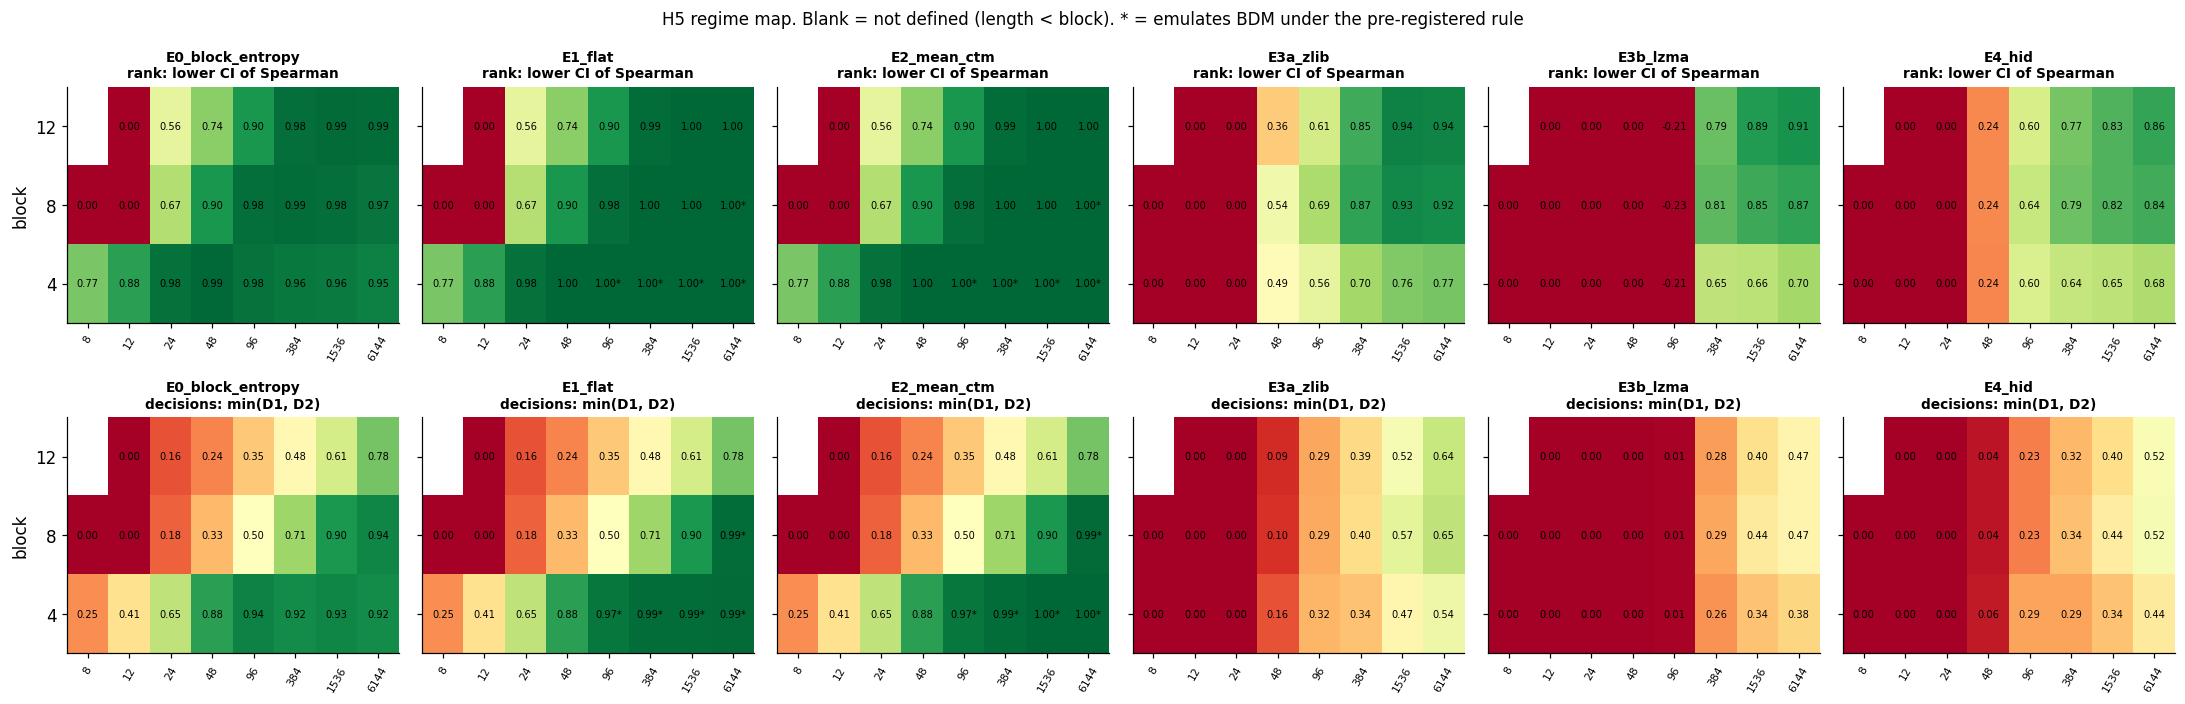

E0_block_entropy  emulates BDM in  0 of 23 regimes: []
E1_flat           emulates BDM in  5 of 23 regimes: [(96, 4), (384, 4), (1536, 4), (6144, 4), (6144, 8)]
E2_mean_ctm       emulates BDM in  5 of 23 regimes: [(96, 4), (384, 4), (1536, 4), (6144, 4), (6144, 8)]
E3a_zlib          emulates BDM in  0 of 23 regimes: []
E3b_lzma          emulates BDM in  0 of 23 regimes: []
E4_hid            emulates BDM in  0 of 23 regimes: []


In [37]:
Ln = sorted({r["n"] for r in H5["regimes"]}); Bk = sorted({r["block"] for r in H5["regimes"]})
def grid(e, key):
    M = np.full((len(Bk), len(Ln)), np.nan)
    for r in H5["regimes"]:
        v = r["emulators"][e]
        M[Bk.index(r["block"]), Ln.index(r["n"])] = (v["rho_ci95"][0] if key == "rho" else (v["decision"] or 0))
    return M
fig, ax = plt.subplots(2, 6, figsize=(20, 6.5), sharey=True)
for j, e in enumerate(EMU):
    for i, key in enumerate(("rho", "dec")):
        M = grid(e, key)
        ax[i, j].imshow(M, cmap="RdYlGn", vmin=0, vmax=1, origin="lower", aspect="auto")
        for r in H5["regimes"]:
            y, x = Bk.index(r["block"]), Ln.index(r["n"])
            v = M[y, x]
            star = "*" if r["emulators"][e]["emulates"] else ""
            ax[i, j].text(x, y, f"{v:.2f}{star}", ha="center", va="center", fontsize=6.5)
        ax[i, j].set(xticks=range(len(Ln)), xticklabels=Ln, yticks=range(len(Bk)), yticklabels=Bk)
        ax[i, j].tick_params(axis="x", labelrotation=60, labelsize=7); ax[i, j].grid(False)
        ax[i, j].set_title(f"{e}\n" + ("rank: lower CI of Spearman" if key == "rho" else "decisions: min(D1, D2)"), fontsize=9)
ax[0, 0].set_ylabel("block"); ax[1, 0].set_ylabel("block")
fig.suptitle("H5 regime map. Blank = not defined (length < block). * = emulates BDM under the pre-registered rule", fontsize=11)
plt.tight_layout(); plt.show()
for e in EMU:
    print(f"{e:<17} emulates BDM in {len(emulating[e]):>2} of {len(H5['regimes'])} regimes: {emulating[e]}")
assert emulating["E1_flat"] == [(96, 4), (384, 4), (1536, 4), (6144, 4), (6144, 8)]

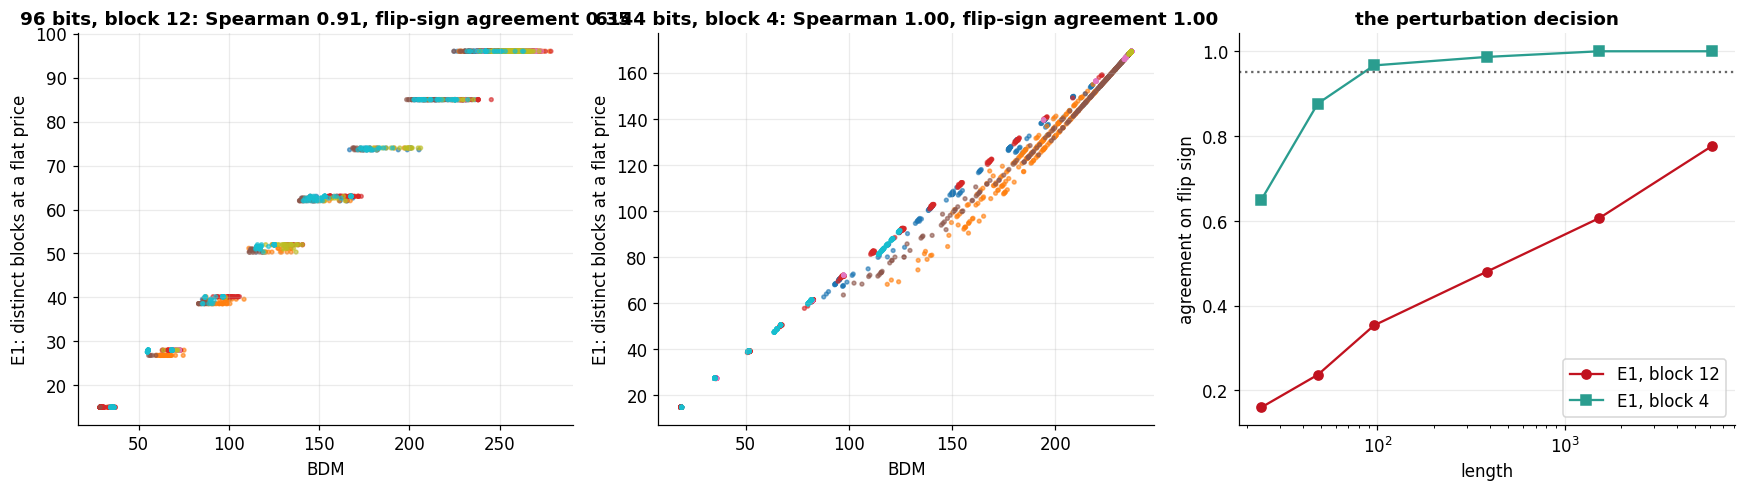

96 bits, block 12: in 194 of 300 flips E1 does not change at all while BDM does


In [38]:
def pick(n, b): return next(r for r in H5["regimes"] if r["n"] == n and r["block"] == b)
fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))
for a, (n, b) in zip(ax[:2], ((96, 12), (6144, 4))):
    recs = [o for o in H5["raw"] if o["n"] == n]
    xs = [o["orig"][str(b)]["bdm"] for o in recs]; ys = [o["orig"][str(b)]["E1_flat"] for o in recs]
    fam = [P.FAMILIES.index(o["family"]) for o in recs]
    a.scatter(xs, ys, c=fam, cmap="tab10", s=6, alpha=.6)
    v = pick(n, b)["emulators"]["E1_flat"]
    a.set(xlabel="BDM", ylabel="E1: distinct blocks at a flat price",
          title=f"{n} bits, block {b}: Spearman {v['rho']:.2f}, flip-sign agreement {v['D2']:.2f}")
flips = [o for o in H5["raw"] if o["n"] == 96 and "flipped" in o]
z = sum(1 for o in flips if abs(o["flipped"]["12"]["E1_flat"] - o["orig"]["12"]["E1_flat"]) < 1e-9
        and abs(o["flipped"]["12"]["bdm"] - o["orig"]["12"]["bdm"]) >= 1e-9)
d2 = {n: pick(n, 12)["emulators"]["E1_flat"]["D2"] for n in (24, 48, 96, 384, 1536, 6144)}
ax[2].plot(list(d2), list(d2.values()), "o-", color=HL, label="E1, block 12")
d2_4 = {n: pick(n, 4)["emulators"]["E1_flat"]["D2"] for n in (24, 48, 96, 384, 1536, 6144)}
ax[2].plot(list(d2_4), list(d2_4.values()), "s-", color=OK, label="E1, block 4")
ax[2].axhline(.95, color="0.4", ls=":"); ax[2].set(xscale="log", xlabel="length", ylabel="agreement on flip sign",
                                                 title="the perturbation decision"); ax[2].legend()
plt.tight_layout(); plt.show()
print(f"96 bits, block 12: in {z} of {len(flips)} flips E1 does not change at all while BDM does")
assert (z, len(flips)) == (194, 300)
d2_12 = [pick(n, 12)["emulators"]["E1_flat"]["D2"] for n in (24, 48, 96, 384, 1536, 6144)]
assert (round(min(d2_12), 2), round(max(d2_12), 2)) == (0.16, 0.78)
comp = [r["emulators"][e]["decision"] for r in H5["regimes"] for e in ("E3a_zlib", "E3b_lzma", "E4_hid")
        if not r["emulators"][e]["constant"]]
assert round(max(comp), 2) == 0.65
e1rho = [pick(n, b)["emulators"]["E1_flat"]["rho"] for n in (384, 1536, 6144) for b in (4, 8, 12)]
assert min(e1rho) >= 0.985

### Anatomy of H5: what each candidate computes, and where ρ, D1, D2 come from

**The claim.** A candidate emulates BDM in a regime if it ranks strings like BDM (lower end of
the 95 % interval of Spearman at least 0.95) **and** takes the same decisions at least 95 % of the
time. **The regime shown here:** 96-bit strings, block 12, so each string is 8 blocks of 12 bits.

**Step 1: one string, every candidate's number.** The first cellular-automaton row of the
regime with between 4 and 7 different words, re-generated and checked against the saved record.

In [39]:
h5_n, h5_b = 96, 12
h5_j = next(j for j in range(300)                     # the first CA row with 4 to 7 different words
            if 4 <= len(set(wrap(P.family("eca_row", h5_n, P.rng("H5", "eca_row", h5_n, j)), 12))) <= 7)
h5_s = P.family("eca_row", h5_n, P.rng("H5", "eca_row", h5_n, h5_j))
h5_rec = next(o for o in H5["raw"] if o["n"] == h5_n and o["family"] == "eca_row" and o["j"] == h5_j)
print(f"instance: cellular-automaton row number {h5_j} of the regime")
h5_m = P.measures(h5_s, [4, 8, 12])
assert json.loads(json.dumps(h5_m, default=str))["12"] == h5_rec["orig"]["12"]
h5_cnt = collections.Counter(wrap(h5_s, 12)); m_ = sum(h5_cnt.values())
mc12 = np.mean([ctm_1d(format(i, "012b")) for i in range(4096)])
print("string:", h5_s); print("blocks of 12:", " ".join(wrap(h5_s, 12)))
print(f"m = {m_} blocks, {len(h5_cnt)} different: " + ", ".join(f"{w} x{n}" for w, n in h5_cnt.items()))
print(f"\nBDM               = sum CTM(w) + sum log2(n_w) = {sum(ctm_1d(w) for w in h5_cnt):.2f} + "
      f"{sum(math.log2(n) for n in h5_cnt.values()):.2f} = {h5_m[12]['bdm']:.2f}")
print(f"E0 block entropy  = sum n_w log2(m / n_w)                    = {h5_m[12]['E0_block_entropy']:.2f}")
print(f"E1 flat price     = sum len(w) + sum log2(n_w) = {12 * len(h5_cnt)} + {sum(math.log2(n) for n in h5_cnt.values()):.2f}"
      f" = {h5_m[12]['E1_flat']:.2f}   (every word costs 12, its length)")
print(f"E2 mean CTM       = (number of words) x {mc12:.3f} + sum log2(n_w) = {h5_m[12]['E2_mean_ctm']:.2f}"
      "   (every word costs the AVERAGE CTM of 12-bit words)")
print(f"E3a zlib          = 8 x bytes of a zlib archive  = {h5_m['E3a_zlib']}")
print(f"E3b lzma          = 8 x bytes of an lzma archive = {h5_m['E3b_lzma']}")
print(f"E4 HID-v1 (ours)  = archive bits                  = {h5_m['E4_hid']}")
print("\nE1 and E2 see only HOW MANY different words there are and how often; BDM also sees WHICH words they are.")

instance: cellular-automaton row number 6 of the regime
string: 000000000000000000010000100010000001000010000000100000001000000000000000000000000100000000000000
blocks of 12: 000000000000 000000010000 100010000001 000010000000 100000001000 000000000000 000000000100 000000000000
m = 8 blocks, 6 different: 000000000000 x3, 000000010000 x1, 100010000001 x1, 000010000000 x1, 100000001000 x1, 000000000100 x1

BDM               = sum CTM(w) + sum log2(n_w) = 173.18 + 1.58 = 174.77
E0 block entropy  = sum n_w log2(m / n_w)                    = 19.25
E1 flat price     = sum len(w) + sum log2(n_w) = 72 + 1.58 = 73.58   (every word costs 12, its length)
E2 mean CTM       = (number of words) x 32.505 + sum log2(n_w) = 196.61   (every word costs the AVERAGE CTM of 12-bit words)
E3a zlib          = 8 x bytes of a zlib archive  = 216
E3b lzma          = 8 x bytes of an lzma archive = 600
E4 HID-v1 (ours)  = archive bits                  = 152

E1 and E2 see only HOW MANY different words there are an

**Step 2: ρ.** Each candidate gives one number per string. Spearman's ρ compares the *orders* of
the 2,100 strings (7 families × 300) under the candidate and under BDM: 1 means identical
ranking. Its 95 % interval comes from resampling the 2,100 strings 1,000 times.

**Step 3: D1, which of two strings is more complex.** 2,000 random pairs. A pair counts as an
agreement if the candidate orders it the same way as BDM.

**Step 4: D2, does flipping one bit raise or lower complexity.** 300 strings each have one bit
flipped. A flip counts as an agreement if the candidate's change has the same sign as BDM's,
with "no change" counting as a sign of its own. This is the decision the BDM causal calculus
is built on.

In [40]:
h5_recs = [o for o in H5["raw"] if o["n"] == h5_n]
pr_ = P.rng("H5pairs", h5_n, h5_b)
i_, k_ = pr_.sample(range(len(h5_recs)), 2)
a_, b_ = h5_recs[i_]["orig"]["12"], h5_recs[k_]["orig"]["12"]
print(f"D1, the first of the 2,000 pairs: string {i_} ({h5_recs[i_]['family']}) vs string {k_} ({h5_recs[k_]['family']})")
print(f"   BDM {a_['bdm']:.1f} vs {b_['bdm']:.1f} -> {'first' if a_['bdm'] > b_['bdm'] else 'second'} is more complex")
print(f"   E1  {a_['E1_flat']:.1f} vs {b_['E1_flat']:.1f} -> {'first' if a_['E1_flat'] > b_['E1_flat'] else 'second'}"
      f" -> {'agree' if P.sgn(a_['E1_flat'] - b_['E1_flat']) == P.sgn(a_['bdm'] - b_['bdm']) else 'disagree'}")
ex = next(o for o in h5_recs if "flipped" in o and abs(o["flipped"]["12"]["E1_flat"] - o["orig"]["12"]["E1_flat"]) < 1e-9
          and abs(o["flipped"]["12"]["bdm"] - o["orig"]["12"]["bdm"]) > 1e-9)
xs_ = P.family(ex["family"], h5_n, P.rng("H5", ex["family"], h5_n, ex["j"])); ys_ = P.flip(xs_, ex["flip_at"])
blk = ex["flip_at"] // 12
w_old, w_new = xs_[12 * blk:12 * blk + 12], ys_[12 * blk:12 * blk + 12]
print(f"\nD2, a flip on which E1 and BDM disagree ({ex['family']}, bit {ex['flip_at']}, inside block {blk}):")
print(f"   block {w_old} -> {w_new}; different words before {len(set(wrap(xs_, 12)))}, after {len(set(wrap(ys_, 12)))}")
print(f"   E1 change  = {ex['flipped']['12']['E1_flat'] - ex['orig']['12']['E1_flat']:+.2f}  (same number of different words, same counts)")
print(f"   BDM change = CTM({w_new}) - CTM({w_old}) = {ctm_1d(w_new):.3f} - {ctm_1d(w_old):.3f} = "
      f"{ex['flipped']['12']['bdm'] - ex['orig']['12']['bdm']:+.3f}")
v_ = next(r for r in H5["regimes"] if r["n"] == h5_n and r["block"] == h5_b)["emulators"]["E1_flat"]
print(f"\nregime (96 bits, block 12), E1: rho {v_['rho']:.3f} (interval {v_['rho_ci95'][0]:.3f}-{v_['rho_ci95'][1]:.3f});"
      f" D1 {v_['D1']:.3f} over {v_['D1_pairs_used']} pairs ({v_['D1_pairs_tied_bdm']} tied under BDM, excluded);"
      f" D2 {v_['D2']:.3f} over {v_['D2_flips']} flips")
print(f"decision = min(D1, D2) = {v_['decision']:.3f}; emulates = (rho lower end >= 0.95) and (decision >= 0.95) = {v_['emulates']}")

D1, the first of the 2,000 pairs: string 245 (eca_row) vs string 1000 (biased_coin)
   BDM 182.4 vs 263.2 -> second is more complex
   E1  73.6 vs 96.0 -> second -> agree

D2, a flip on which E1 and BDM disagree (eca_row, bit 14, inside block 1):
   block 011001011111 -> 010001011111; different words before 8, after 8
   E1 change  = +0.00  (same number of different words, same counts)
   BDM change = CTM(010001011111) - CTM(011001011111) = 32.816 - 33.605 = -0.788

regime (96 bits, block 12), E1: rho 0.911 (interval 0.900-0.921); D1 0.682 over 2000 pairs (0 tied under BDM, excluded); D2 0.353 over 300 flips
decision = min(D1, D2) = 0.353; emulates = (rho lower end >= 0.95) and (decision >= 0.95) = False


**Reading.** The pre-registered prediction holds. Where the string is a single block, every
candidate is constant while BDM is not, so none can emulate it. Beyond that:

* **Rankings and decisions part company.** E1 ranks strings like BDM very closely in many
  regimes (Spearman ≥ 0.99 from 384 bits). But at block 12 it agrees on the sign of a
  one-bit perturbation only 16–78 % of the time (24 to 6,144 bits). The mechanism is simple: when a flip turns one
  distinct word into another distinct word, the count of distinct words does not change, so
  E1 cannot move, while BDM moves by the difference in CTM. At 96 bits and block 12 this is
  194 of the 300 flips.
* **E1/E2 emulate BDM in 5 of 23 regimes:** block 4 from 96 bits up, and block 8 at 6,144 bits.
  These are exactly the long-input, short-word settings in which every word recurs. This is
  the saturated regime of §3, where BDM itself has little to say.
* **No compressor emulates BDM anywhere, and neither does HID-v1.** zlib, lzma and the HID
  archive rank strings differently from BDM, and their decision agreement is at most
  65 % in any regime.

So the author's scepticism was right, and bitacora 43's statement is **withdrawn**. **Where
BDM is informative, its CTM values carry the perturbation response, and nothing simpler tested
here reproduces it.** Where something simpler does reproduce it, BDM is saturated.

## 8 · Our certified code against BDM, on objects with a known generator (H6)

For an elementary cellular automaton the generator is known, so a complete code can be
written: the rule (its D_schema, rounded up to whole bits), the width, the seed row in plain
bits, and the number of steps, each self-delimiting (`certified_eca_code`, owner). The
diagram is rebuilt exactly by running the rule; §10 shows the code decodes. So
**K(diagram) ≤ certified bits + c**, where c is the size of a CA interpreter. The protocol
compares this with BDM and with the HID-v1 archive on 256 rules × 4 run lengths × 5 seeds
(5,120 diagrams, width 64).

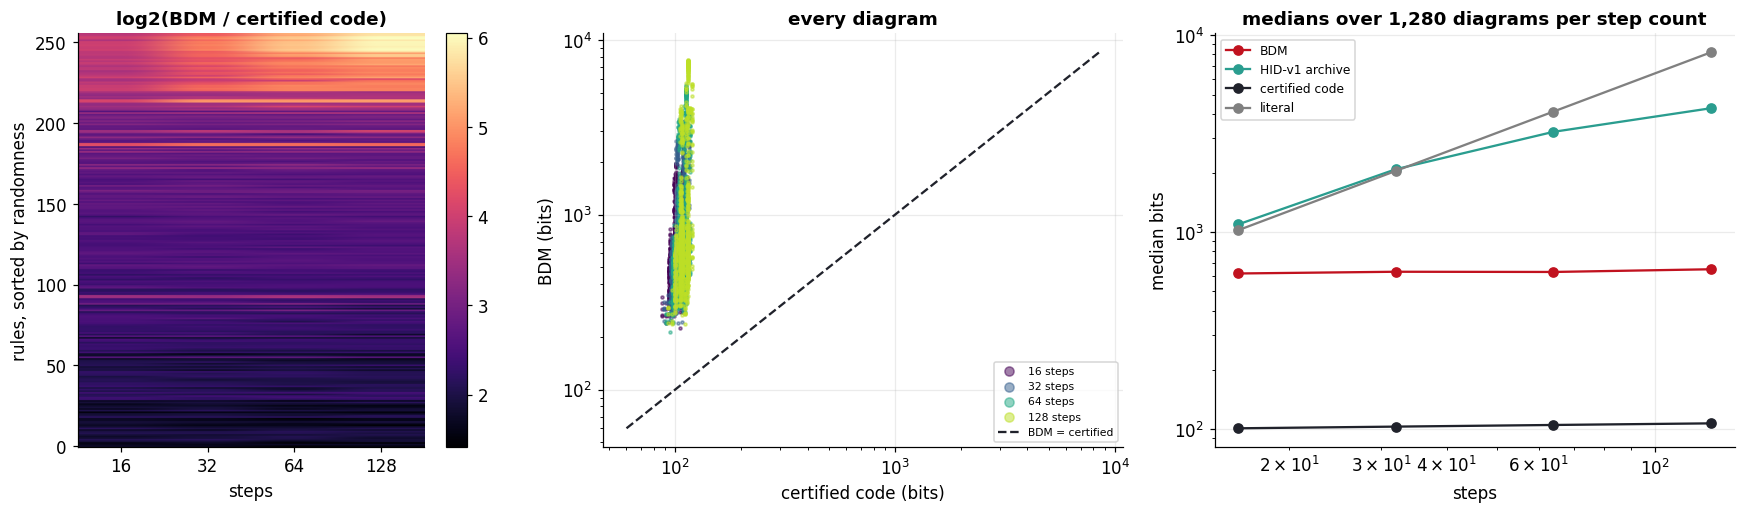

  16 steps: BDM > certified in 100% of 1280; median BDM/certified 6.03; HID below literal in 39%
  32 steps: BDM > certified in 100% of 1280; median BDM/certified 6.03; HID below literal in 48%
  64 steps: BDM > certified in 100% of 1280; median BDM/certified 5.94; HID below literal in 72%
 128 steps: BDM > certified in 100% of 1280; median BDM/certified 6.02; HID below literal in 89%
rules whose BDM excess grows with steps: 73% of 256


In [41]:
rows6 = H6["rows"]
live = P._h6_job((110, 64, 0, 64)); saved = next(x for x in rows6 if x["rule"] == 110 and x["steps"] == 64 and x["seed"] == 0)
assert all(abs(live[k] - saved[k]) < 1e-9 for k in saved), "H6 live re-computation differs"
steps = sorted({x["steps"] for x in rows6})
proxy = {x["rule"]: x["lzma_per_bit"] for x in H34["per_rule"]}
order = sorted(range(256), key=lambda r: proxy[r])
Mr = np.array([[np.mean([np.log2(x["bdm"] / x["certified"]) for x in rows6 if x["rule"] == r and x["steps"] == s]) for s in steps] for r in order])
fig, ax = plt.subplots(1, 3, figsize=(16, 4.8), gridspec_kw={"width_ratios": [1, 1.2, 1.2]})
im = ax[0].imshow(Mr, aspect="auto", cmap="magma", origin="lower")
ax[0].set(xticks=range(4), xticklabels=steps, xlabel="steps", ylabel="rules, sorted by randomness",
          title="log2(BDM / certified code)"); ax[0].grid(False); plt.colorbar(im, ax=ax[0])
for s, col in zip(steps, plt.cm.viridis(np.linspace(0, .9, 4))):
    xs = [x["certified"] for x in rows6 if x["steps"] == s]; ys = [x["bdm"] for x in rows6 if x["steps"] == s]
    ax[1].scatter(xs, ys, s=4, color=col, alpha=.5, label=f"{s} steps")
lim = [60, max(x["bdm"] for x in rows6) * 1.1]
ax[1].plot(lim, lim, color=INK, ls="--", label="BDM = certified"); ax[1].set(xscale="log", yscale="log", xlabel="certified code (bits)", ylabel="BDM (bits)",
                                                                             title="every diagram"); ax[1].legend(fontsize=7, markerscale=3)
for key, col, lab in (("bdm", HL, "BDM"), ("hid", OK, "HID-v1 archive"), ("certified", INK, "certified code"), ("literal", "0.5", "literal")):
    ax[2].plot(steps, [np.median([x[key] for x in rows6 if x["steps"] == s]) for s in steps], "o-", color=col, label=lab)
ax[2].set(xscale="log", yscale="log", xlabel="steps", ylabel="median bits", title="medians over 1,280 diagrams per step count"); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()
for s in steps:
    b = H6["by_steps"][str(s)]
    print(f"{s:>4} steps: BDM > certified in {b['share_bdm_gt_certified']:.0%} of {b['diagrams']}; median BDM/certified {b['median_ratio_bdm_over_certified']:.2f}; "
          f"HID below literal in {b['share_hid_lt_literal']:.0%}")
print(f"rules whose BDM excess grows with steps: {H6['share_rules_positive_slope']:.0%} of 256")
assert all(H6["by_steps"][str(s)]["share_bdm_gt_certified"] == 1.0 for s in steps)

### Anatomy of H6: one diagram, its certified code bit by bit, and its BDM

**The claim (descriptive).** On a diagram whose rule is known, compare BDM with a code that
rebuilds the diagram exactly. **The instance:** rule 110, 64 steps, seed 0, width 64.

Part 1, the rule: rule 110 as a truth table over (left, centre, right): 000->0 001->1 010->1 011->1 100->0 101->1 110->1 111->0
   minimal set of schemata (prime implicants) covering the 1s: 3 clauses
   gamma(number of clauses + 1) = gamma(4) = 5 bits
   clause 'centre=1 AND right=0': k = 2 fixed inputs -> log2(4) [how many fixed: 0..3] + log2 C(3,2) [which ones] + 2 [their values] = 5.585
   clause 'right=1 AND centre=0': k = 2 fixed inputs -> log2(4) [how many fixed: 0..3] + log2 C(3,2) [which ones] + 2 [their values] = 5.585
   clause 'centre=1 AND left=0': k = 2 fixed inputs -> log2(4) [how many fixed: 0..3] + log2 C(3,2) [which ones] + 2 [their values] = 5.585
   D_schema = 21.755 -> rounded up to whole bits: 22
Part 2, the width: gamma(64) = 13 bits     Part 3, the seed row: 64 bits, written literally
Part 4, the number of steps: gamma(64) = 13 bits
certified code = 22 + 13 + 64 + 13 = 112 bits

BDM of the 64 x 64 diagram: 256 blocks of 4x4, 84 different; dictionary 2519.6 + cou

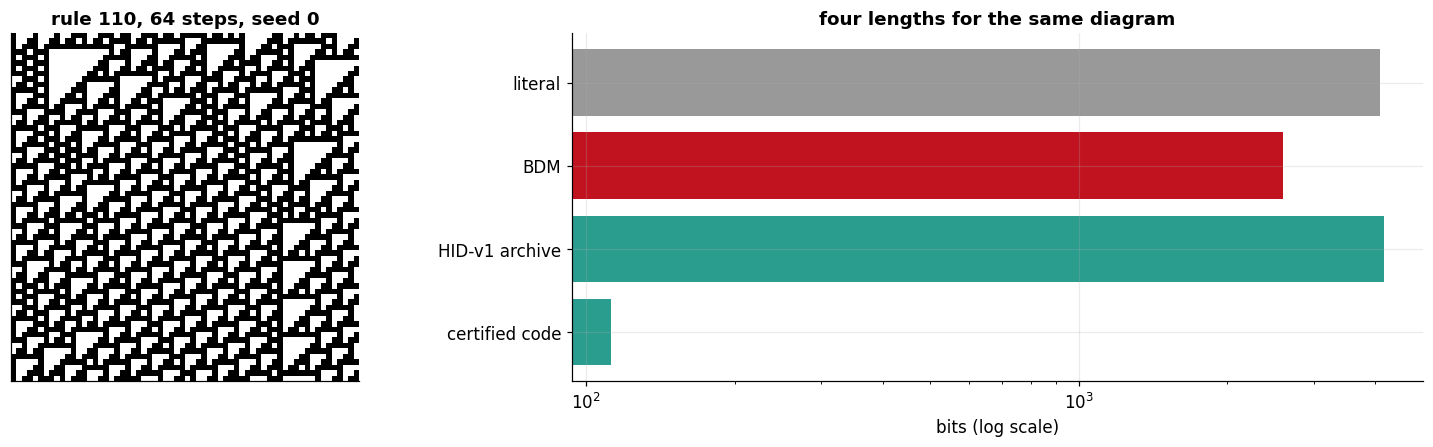

the reported shares are counts over the 1,280 diagrams at each step count (256 rules x 5 seeds): {16: '1280/1280', 32: '1280/1280', 64: '1280/1280', 128: '1280/1280'}


In [42]:
from deconvolution import minimal_dnf
h6_r = P.rng("H6", 110, 64, 0); h6_init = [h6_r.randrange(2) for _ in range(64)]
h6_A = np.array(evolve_eca(110, h6_init, 64))
h6_saved = next(x for x in H6["rows"] if x["rule"] == 110 and x["steps"] == 64 and x["seed"] == 0)
tab_ = [(110 >> y) & 1 for y in range(8)]
cl_ = minimal_dnf(tab_)
print("Part 1, the rule: rule 110 as a truth table over (left, centre, right):",
      " ".join(f"{y:03b}->{v}" for y, v in enumerate(tab_)))
print(f"   minimal set of schemata (prime implicants) covering the 1s: {len(cl_)} clauses")
tot_ = 2 * ((len(cl_) + 1).bit_length() - 1) + 1
print(f"   gamma(number of clauses + 1) = gamma({len(cl_) + 1}) = {tot_} bits")
for c in cl_:
    k = len(c["activators"]) + len(c["inhibitors"])
    term = math.log2(3 + 1) + math.log2(math.comb(3, k)) + k
    tot_ += term
    nm = {0: "right", 1: "centre", 2: "left"}          # table index y = 4*left + 2*centre + right
    lits = [nm[i] + "=1" for i in c["activators"]] + [nm[i] + "=0" for i in c["inhibitors"]]
    print(f"   clause '{' AND '.join(lits)}': k = {k} fixed inputs -> log2(4) [how many fixed: 0..3] + "
          f"log2 C(3,{k}) [which ones] + {k} [their values] = {term:.3f}")
print(f"   D_schema = {tot_:.3f} -> rounded up to whole bits: {math.ceil(tot_)}")
cert_ = certified_eca_code(110, h6_init, 64)
assert math.ceil(tot_) == cert_["rule_bits"]
print(f"Part 2, the width: gamma(64) = {cert_['width_bits']} bits     Part 3, the seed row: {cert_['seed_bits']} bits, written literally")
print(f"Part 4, the number of steps: gamma(64) = {cert_['steps_bits']} bits")
print(f"certified code = {cert_['rule_bits']} + {cert_['width_bits']} + {cert_['seed_bits']} + {cert_['steps_bits']} = {cert_['certified_bits']} bits")
blk_ = collections.Counter("".join(map(str, h6_A[i:i + 4, j:j + 4].flat)) for i in range(0, 64, 4) for j in range(0, 64, 4))
dic_ = sum(T2D[(4, 4)][normalize_key(w)] for w in blk_); cnt_ = sum(math.log2(n) for n in blk_.values())
print(f"\nBDM of the 64 x 64 diagram: 256 blocks of 4x4, {len(blk_)} different;"
      f" dictionary {dic_:.1f} + counts {cnt_:.1f} = {dic_ + cnt_:.1f} bits")
print(f"literal: {h6_A.size} bits; HID-v1 archive of the flattened diagram: {h6_saved['hid']} bits"
      " (above the literal here: HID-v1 found no rule and fell back to a literal archive plus its envelope)")
print(f"BDM / certified = {dic_ + cnt_:.1f} / {cert_['certified_bits']} = {(dic_ + cnt_) / cert_['certified_bits']:.1f}")
assert abs(dic_ + cnt_ - h6_saved["bdm"]) < 1e-6 and cert_["certified_bits"] == h6_saved["certified"]
fig, ax = plt.subplots(1, 2, figsize=(14, 4.2), gridspec_kw={"width_ratios": [1, 1.6]})
ax[0].imshow(1 - h6_A, cmap="gray", interpolation="nearest"); ax[0].set(title="rule 110, 64 steps, seed 0", xticks=[], yticks=[])
ax[0].grid(False)
ax[1].barh(["certified code", "HID-v1 archive", "BDM", "literal"],
           [cert_["certified_bits"], h6_saved["hid"], dic_ + cnt_, h6_A.size], color=[OK, OK, HL, "0.6"])
ax[1].set(xscale="log", xlabel="bits (log scale)", title="four lengths for the same diagram")
plt.tight_layout(); plt.show()
print("the reported shares are counts over the 1,280 diagrams at each step count (256 rules x 5 seeds):",
      {s: f"{sum(x['bdm'] > x['certified'] for x in H6['rows'] if x['steps'] == s)}/1280" for s in (16, 32, 64, 128)})

**Reading.** In every one of the 5,120 diagrams, BDM is larger than a complete code for the
same diagram. The median ratio is about 6 at every run length; the excess grows with steps for
73 % of the rules, and the heat map shows where: the more random the diagram looks, the
larger the excess. BDM measures the **output**, and a short rule can produce a long,
random-looking output. The certified code measures the **program**. The HID-v1 archive,
which does not know the rule, gets below the literal length for 39 % of diagrams at 16 steps
and 89 % at 128 steps.

What may be said: on deterministic diagrams with a known rule, **BDM exceeds a code we can
exhibit and decode**, typically by a factor of about six. Since K is at most that code plus a
fixed constant, BDM here overestimates K. This is the reverse of DM1, where BDM
underestimates it, so BDM is neither an upper nor a lower bound (§10). The comparison is only
possible where a generator in our class exists: the certified code is defined for cellular
automata, not for every string.

## 9 · When do the two methods agree? (H7)

Two rules side by side on one ring: cells left of the boundary run rule A, the rest rule B.
**Ours** reconstructs each column's rule from the diagram (`deconvolve_ca`, strict) and splits
where the labels change. **BDM** flips cells in each column, averages the size of the change,
and finds the change point. Five arms, 30 diagrams each; each arm breaks one condition.

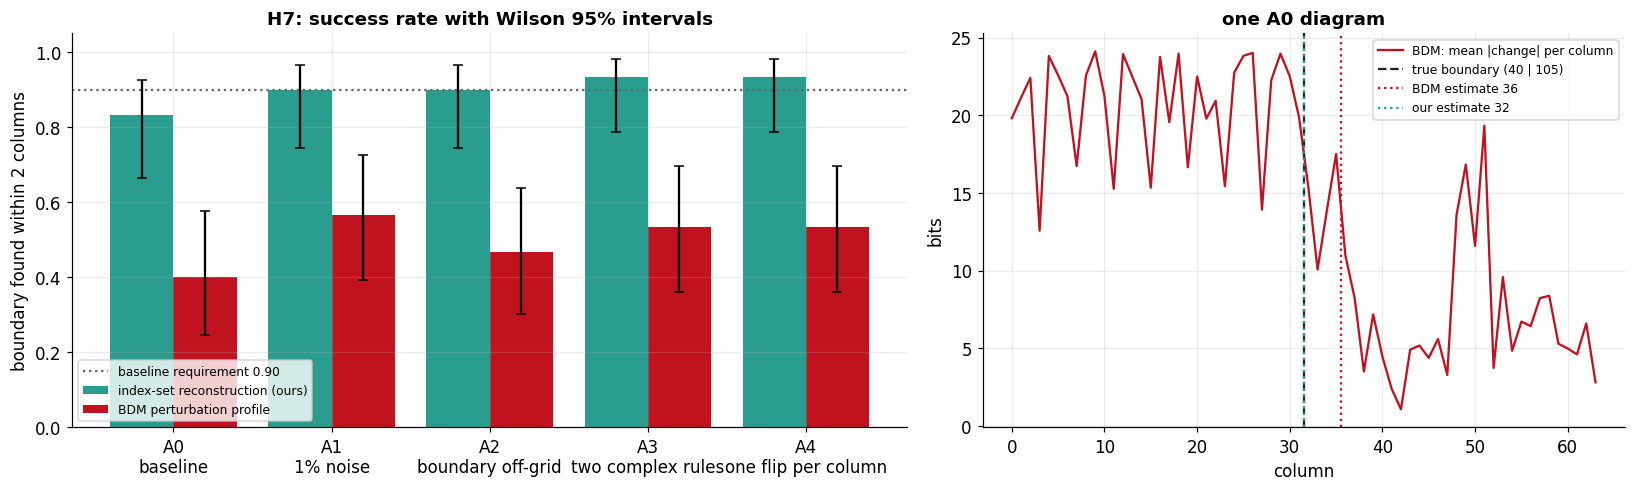

A0 baseline               ours 0.83   BDM 0.40   same outcome 0.57   (n = 30)
A1 1% noise               ours 0.90   BDM 0.57   same outcome 0.53   (n = 30)
A2 boundary off-grid      ours 0.90   BDM 0.47   same outcome 0.50   (n = 30)
A3 two complex rules      ours 0.93   BDM 0.53   same outcome 0.60   (n = 30)
A4 one flip per column    ours 0.93   BDM 0.53   same outcome 0.47   (n = 30)
baseline valid: False


In [43]:
S = H7["summary"]; arms = list(S)
desc = {"A0": "baseline", "A1": "1% noise", "A2": "boundary off-grid", "A3": "two complex rules", "A4": "one flip per column"}
fig, ax = plt.subplots(1, 2, figsize=(15, 4.6), gridspec_kw={"width_ratios": [1.3, 1]})
xx = np.arange(len(arms))
for off, key, col, lab in ((-.2, "ours", OK, "index-set reconstruction (ours)"), (.2, "bdm", HL, "BDM perturbation profile")):
    v = np.array([S[a][key] for a in arms]); lo = v - np.array([S[a][key + "_ci95"][0] for a in arms]); hi = np.array([S[a][key + "_ci95"][1] for a in arms]) - v
    ax[0].bar(xx + off, v, .4, color=col, label=lab, yerr=[lo, hi], capsize=3)
ax[0].axhline(.9, color="0.4", ls=":", label="baseline requirement 0.90")
ax[0].set(xticks=xx, xticklabels=[f"{a}\n{desc[a]}" for a in arms], ylim=(0, 1.05), ylabel="boundary found within 2 columns",
          title="H7: success rate with Wilson 95% intervals"); ax[0].legend(fontsize=8)
ex = next(x for x in H7["rows"] if x["arm"] == "A0" and x["ours_ok"] and not x["bdm_ok"])
ax[1].plot(range(64), ex["profile"], color=HL, label="BDM: mean |change| per column")
ax[1].axvline(ex["boundary"] - .5, color=INK, ls="--", label=f"true boundary ({ex['A']} | {ex['B']})")
ax[1].axvline(ex["k_bdm"] - .5, color=HL, ls=":", label=f"BDM estimate {ex['k_bdm']}")
ax[1].axvline(ex["k_ours"] - .5, color=OK, ls=":", label=f"our estimate {ex['k_ours']}")
ax[1].set(xlabel="column", ylabel="bits", title="one A0 diagram"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
for a in arms:
    print(f"{a} {desc[a]:<22} ours {S[a]['ours']:.2f}   BDM {S[a]['bdm']:.2f}   same outcome {S[a]['methods_agree']:.2f}   (n = {S[a]['n']})")
print("baseline valid:", H7["baseline_valid"])
row = H7["rows"][0]; live = P._h7_job((row["arm"], row["i"], 64, 64))
assert live == json.loads(json.dumps(row)), "H7 live re-computation differs"

### Anatomy of H7: how each method places the boundary on one diagram

**The instance:** arm A0, diagram 0, rebuilt and checked against the saved record. The left
cells run rule A and the right cells rule B.

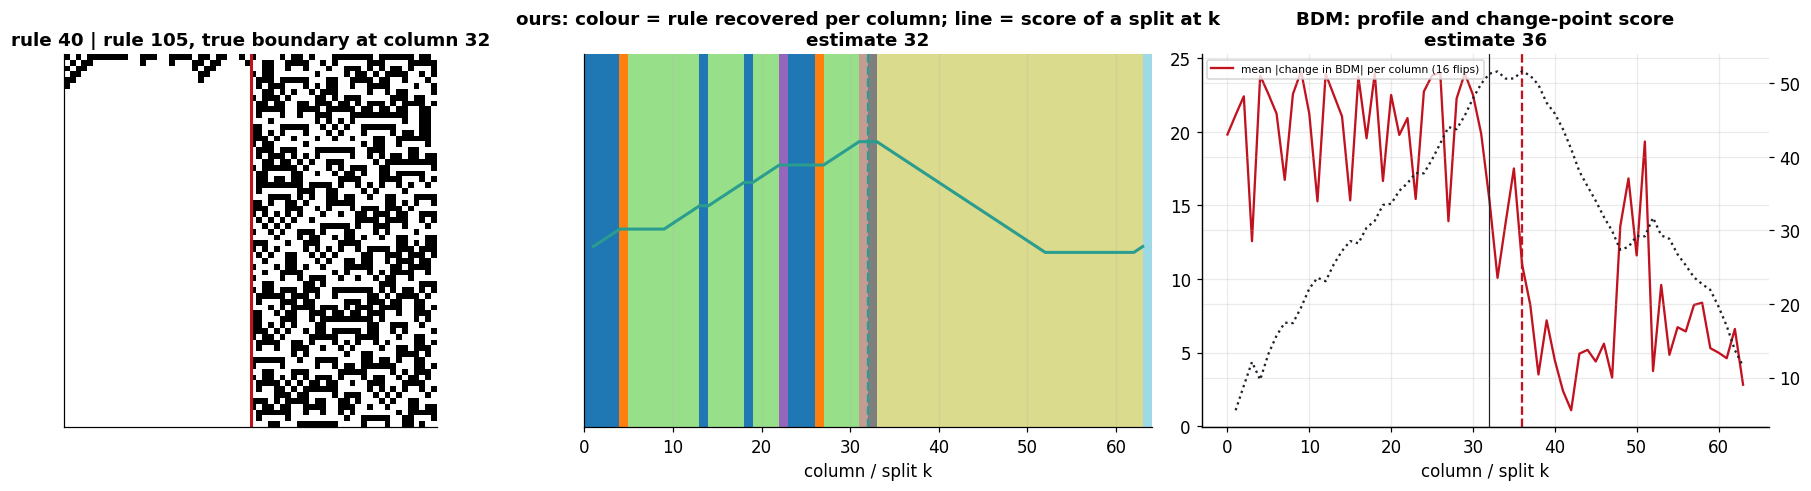

ours: 8 different column labels; best split k = 32 -> |32 - 32| = 0 -> success
BDM: best split k = 36 -> |36 - 32| = 4 -> miss

arm A0, ours: 25 successes of 30 = 0.83; Wilson 95% interval = 0.66 to 0.93


In [44]:
h7_saved = next(x for x in H7["rows"] if x["arm"] == "A0" and x["i"] == 0)
r_ = P.rng("H7", "A0", 0)
A_, B_ = r_.choice(P.SIMPLE), r_.choice(P.COMPLEX)
if r_.random() < 0.5:
    A_, B_ = B_, A_
h7_rules = [A_] * 32 + [B_] * 32
h7_D = P.evolve_network(P.heterogeneous_eca_network(h7_rules), [r_.randrange(2) for _ in range(64)], 64)
_, h7_rep = P.deconvolve_ca([h7_D], max_radius=1)
h7_labels = [(tuple(((s - c + 32) % 64) - 32 for s in rep.support), tuple(rep.reduced_truth_table)) for c, rep in enumerate(h7_rep)]
lab_ids = {l: i for i, l in enumerate(dict.fromkeys(h7_labels))}
score_ours = [collections.Counter(h7_labels[:k]).most_common(1)[0][1] + collections.Counter(h7_labels[k:]).most_common(1)[0][1]
              for k in range(1, 64)]
M_ = np.array(h7_D); base_ = bdm_2d(M_); prof_ = []
for c in range(64):
    vals = []
    for t in r_.sample(range(64), 16):
        T_ = M_.copy(); T_[t, c] ^= 1; vals.append(abs(base_ - bdm_2d(T_)))
    prof_.append(float(np.mean(vals)))
score_bdm = [math.sqrt(k * (64 - k) / 64) * abs(np.mean(prof_[:k]) - np.mean(prof_[k:])) for k in range(1, 64)]
k_o, k_b = P.split_by_labels(h7_labels), P.split_cusum(prof_)
assert (A_, B_, k_o, k_b) == (h7_saved["A"], h7_saved["B"], h7_saved["k_ours"], h7_saved["k_bdm"])
assert np.allclose(prof_, h7_saved["profile"])
fig, ax = plt.subplots(1, 3, figsize=(17, 4.6))
ax[0].imshow(1 - M_, cmap="gray", interpolation="nearest"); ax[0].axvline(31.5, color=HL, lw=2)
ax[0].set(title=f"rule {A_} | rule {B_}, true boundary at column 32", xticks=[], yticks=[]); ax[0].grid(False)
ax[1].imshow([[lab_ids[l] for l in h7_labels]], cmap="tab20", aspect="auto", extent=(0, 64, 0, 6))
ax[1].plot(range(1, 64), np.array(score_ours) / 64 * 6, color=OK, lw=2)
ax[1].axvline(k_o, color=OK, ls="--"); ax[1].set(yticks=[], xlabel="column / split k",
       title=f"ours: colour = rule recovered per column; line = score of a split at k\nestimate {k_o}")
ax[2].plot(range(64), prof_, color=HL, label="mean |change in BDM| per column (16 flips)")
ax2 = ax[2].twinx(); ax2.plot(range(1, 64), score_bdm, color=INK, ls=":", label="change-point score")
ax[2].axvline(k_b, color=HL, ls="--"); ax[2].axvline(32, color=INK, lw=.8)
ax[2].set(xlabel="column / split k", title=f"BDM: profile and change-point score\nestimate {k_b}"); ax[2].legend(fontsize=7, loc="upper left")
plt.tight_layout(); plt.show()
print(f"ours: {len(lab_ids)} different column labels; best split k = {k_o} -> |{k_o} - 32| = {abs(k_o - 32)} -> "
      f"{'success' if abs(k_o - 32) <= 2 else 'miss'}")
print(f"BDM: best split k = {k_b} -> |{k_b} - 32| = {abs(k_b - 32)} -> {'success' if abs(k_b - 32) <= 2 else 'miss'}")
s0 = H7["summary"]["A0"]; z = 1.959964; n_ = s0["n"]; k_ = round(s0["ours"] * n_); p_ = k_ / n_
c_ = (p_ + z * z / (2 * n_)) / (1 + z * z / n_); h_ = z * math.sqrt(p_ * (1 - p_) / n_ + z * z / (4 * n_ * n_)) / (1 + z * z / n_)
print(f"\narm A0, ours: {k_} successes of {n_} = {p_:.2f}; Wilson 95% interval = {c_ - h_:.2f} to {c_ + h_:.2f}")
assert abs(c_ - h_ - s0["ours_ci95"][0]) < 1e-9

**Reading.** **H7 has no valid baseline.** The protocol required both methods to find the
boundary in at least 90 % of baseline diagrams. Ours did so in 83 %, BDM in 40 %. The other
arms are therefore descriptive only. In them, ours succeeds in 90–93 % of diagrams and BDM in
47–57 %.

Two cautions keep this honest. First, the BDM boundary estimator, a change point on the
per-column perturbation profile, is the one we pre-registered, not the procedure of the 2019
paper, so these numbers say nothing about that paper's results. Second, our strict
reconstruction survived 1 % noise here only because the boundary is read from where labels
change, not from the labels being right. This experiment needs a better-specified BDM
estimator before it can carry a claim; it is listed as open in §11.

## 10 · Formal statements

**P1 (BDM is a function of the block multiset).** For aligned partitions,
BDM(x) = Σ_{w ∈ W(x)} [CTM(w) + log2 n_w], where W(x) is the set of distinct blocks and n_w
their counts. Any rearrangement of whole blocks leaves W and every n_w unchanged, so it leaves
BDM unchanged. Checked: T1, 0 failures in 42,000 permutations.

**P2 (logarithmic growth).** With m complete blocks of length b, at most 2^b distinct words
occur, and each count is at most m, so BDM_b(x) ≤ C_b + 2^b log2 m, where C_b is the sum of
CTM over all b-bit words. Checked: T2.

**P3 (BDM is not a lower bound).** Fix a multiset of blocks with M = m!/∏ n_w! arrangements;
every arrangement has the same BDM (P1). At most 2^k − 1 strings have K < k, so at least
M − 2^k + 1 of the arrangements have K ≥ k. For DM1 at m = 1,000, log2 M ≈ 994.7. Taking
k = 900, all but a fraction 2^−94.7 of the arrangements have K ≥ 900, while their BDM is
69.15. So for almost every such string, BDM < K − 830.

**P4 (complete codes are upper bounds).** If a prefix code with lengths L(x) exists, and a
fixed decoder reconstructs x from its codeword, then K(x) ≤ L(x) + c. The block code
(⌈CTM⌉ words, Elias-γ counts, arrangement rank) and the certified ECA code (⌈D_schema⌉
rule, γ width, literal seed, γ steps) are prefix codes. Their word and rule lengths satisfy
Kraft's inequality, computed below, and the owner's tests decode both bit for bit. So both are
upper bounds on K up to their decoder constants.

**P5 (BDM is not an upper bound).** By §8, BDM exceeds the certified code on every one of
5,120 diagrams. For the rules whose excess grows with steps, BDM eventually exceeds K by more
than any fixed constant. With P3, BDM can lie on either side of K.

In [45]:
words = [format(i, f"0{L}b") for L in range(1, 13) for i in range(2 ** L)]
kw = sum(2.0 ** -math.ceil(ctm_1d(w)) for w in words)
kr = sum(2.0 ** -certified_eca_code(r, [0], 1)["rule_bits"] for r in range(256))
print(f"Kraft sum, ceil(CTM) over all {len(words):,} words of length 1-12: {kw:.4f}  (must be <= 1)")
print(f"Kraft sum, ceil(D_schema) over the 256 ECA rules: {kr:.4f}  (must be <= 1)")
assert kw <= 1 and kr <= 1
M = R["DM"]["DM1"][1]
assert M["m"] == 1000 and round(M["arrangement_random"], 1) == 994.7 and round(M["bdm_random"], 2) == 69.15
print(f"P3 numbers: log2 M = {M['arrangement_random']:.1f}, BDM = {M['bdm_random']:.2f}")

Kraft sum, ceil(CTM) over all 8,190 words of length 1-12: 0.6707  (must be <= 1)
Kraft sum, ceil(D_schema) over the 256 ECA rules: 0.6173  (must be <= 1)
P3 numbers: log2 M = 994.7, BDM = 69.15


## 11 · What is supported, what is not, and what to write in the papers

**Supported by this run:**

1. BDM depends only on the multiset of blocks (P1, T1). Order between blocks is invisible to
   aligned BDM; overlap is the only channel through which order enters.
2. BDM is dictionary plus counts, with no arrangement. It is not a code length: on pure noise
   its value per bit changes twenty-fold with length, while a complete code stays near one bit
   per bit (H1).
3. BDM is neither an upper nor a lower bound on K. It falls far below a counting bound on
   rearranged strings (P3, DM1), and lies above a decodable code on every one of 5,120 CA
   diagrams (P5, H6).
4. A periodic string looks random to BDM only when the length is short compared with
   lcm(period, block), because then no block repeats (DM3; notebook 15's period-9 case).
5. Single-cell perturbation readings on complex diagrams depend on where the block grid
   falls; group readings do not (H3 secondary, H4).
6. Where BDM is informative, simpler methods reproduce its rankings in part but not its
   perturbation decisions. They emulate it only where it is saturated (H5).
7. Our complete codes, the certified code and the HID-v1 archive, separate strings that BDM
   cannot (DM1). Wherever a generator in our class is found, the certified code is a genuine
   upper bound on K.

**Not supported, and therefore not to be claimed:**

* That a fill ratio predicts when BDM can see a disruption point (H2: withdrawn).
* That a typical rule's single-cell signs flip with the grid (H3: the average is about 11 %;
  the large effect is confined to complex rules).
* That counting distinct blocks "emulates" BDM in general (H5: only in the saturated regime).
* Anything about the agreement of the two methods on two-rule diagrams (H7: no valid baseline).
* That ours is a better estimator of K than BDM *in general*. It is a different, complete
  code. The one held-out test of HID-v1 against generic compressors (`confirm-v1`) did not
  support a general saving.

**Corrections to bitacora 43:**

| bitacora 43 said | this run shows |
|---|---|
| "BDM can do things we cannot: any object, noisy data" | Our codes, with a literal fallback, are defined on every object, and the exceptions-list form is graded under noise. This was wrong. |
| "a plain dictionary count comes close" to BDM | Only on rankings, and only in the saturated regime; not on perturbation decisions (H5). |
| the fill ratio governs seam visibility | Not supported (H2). |
| a period not fitting the block makes BDM see randomness | Only when the string is short relative to lcm(period, block) (DM3). |
| rule 30: sign flips for 50 % of cells | Rule 30 is 0.59 over 5 seeds, but the average over all rules is 0.107 (H3). |
| the subproject's two-part code is a "certificate" | It priced the seed with BDM, so it is not a code length. The certified code is `certified_eca_code` (erratum in `imp-causalNet-paper/.../measure.py`). |

**Open:** a properly specified BDM boundary estimator for H7, the cause of the hidden cells in
H2, and the same anatomy on four-letter (DNA) strings with known generators.